## Exploratory Data Analysis

#### Configuration

In [2]:
# _____________________________________________________
from dotenv import load_dotenv
import os
import glob

load_dotenv()  # reads .env file
# _____________________________________________________

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, spearmanr, chi2_contingency, boxcox
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

from IPython.display import display, HTML, Image as IPyImage
from datetime import datetime
from urllib.parse import urlsplit

#### Functions

In [2]:
# Chi-square estimation

def chi_square_with_target(df, target_col):
    """
    Perform chi-square test of independence between a target categorical column
    and all other columns in the DataFrame.
    """
    results = []

    # Ensure target column is categorical or object type
    if df[target_col].dtype not in ["object", "category", "int"]:
        raise ValueError("Target column must be categorical or integer.")

    for col in df.columns:
        if col == target_col:
            continue

        # Skip non-categorical columns (continuous numeric data is not suitable for chi-square)
        if df[col].dtype not in ["object", "category", "int"]:
            continue

        # Drop rows with NaN in either column
        valid_mask = df[[target_col, col]].notna().all(axis=1)
        sub_df = df.loc[valid_mask, [target_col, col]]

        # Create contingency table
        contingency_table = pd.crosstab(sub_df[target_col], sub_df[col])

        # Perform chi-square test
        chi2, p, dof, expected = chi2_contingency(contingency_table)

        results.append(
            {
                "target_column": target_col,
                "compared_column": col,
                "chi2_statistic": round(chi2, 2),
                "p_value": p,
                "degrees_of_freedom": dof,
            }
        )

    return pd.DataFrame(results)

In [11]:
#Statistical reporting Block
sns.set_theme(style="whitegrid")

# --------------------------------------------------
# Paths
# Notebook expected in ~/Scripts/
# Results required in ~/Results/
# --------------------------------------------------
SCRIPTS_DIR = Path("~/Scripts").expanduser()
RESULTS_DIR = Path("~/Results").expanduser()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helpers
# --------------------------------------------------
def get_notebook_dir():
    """
    Devuelve el directorio que contiene el cuaderno de Jupyter o el script de Python actual.

    En las sesiones de Jupyter de VS Code, utiliza la ruta del cuaderno; en caso contrario, 
    recurre al directorio del script o al directorio de trabajo actual.

    Devuelve
    -------
    Path
        Ruta del directorio como un objeto ``pathlib.Path``.
    """
    try:
        # Specific variable available in VS Code Jupyter environment
        return Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback for standard .py scripts or other environments
        return Path(__file__).parent if "__file__" in globals() else Path.cwd()

def classify_series_type(s: pd.Series, ordinal_threshold: int = 10) -> str:
    """
    Clasifica el tipo de una serie pandas (numeric, ordinal, categorical, datetime)
    para seleccionar la prueba de correlación adecuada.

    Tipos devueltos:
        - 'numeric': numérico continuo.
        - 'ordinal': entero-like o numérico de baja cardinalidad (≤ 'threshold').
        - 'categorical': objeto, categoría o booleano.
        - 'datetime': tipo fecha/hora.

    Parámetros
    ----------
    s : pd.Series
        Serie a clasificar.
    ordinal_threshold : int, default=10
        Umbral de cardinalidad máxima para considerar una serie numérica como ordinal.

    Retorna
    -------
    str
        Tipo clasificado: 'numeric', 'ordinal', 'categorical' o 'datetime'.
    """
    if pd.api.types.is_datetime64_any_dtype(s):
        return "datetime"

    if pd.api.types.is_bool_dtype(s):
        return "categorical"

    if pd.api.types.is_numeric_dtype(s):
        non_null = s.dropna()
        nunique = non_null.nunique()
        if pd.api.types.is_integer_dtype(s) and nunique <= ordinal_threshold:
            return "ordinal"
        return "numeric"

    return "categorical"


def skew_interpretation(skew_value: float) -> str:
    """
    Interpreta el grado de asimetría de una distribución según su valor de skewness.

    Parámetros
    ----------
    skew_value : float
        Valor de coeficiente de asimetría (skewness).

    Retorna
    -------
    str
        Descripción del grado de asimetría:
        - "Approximately symmetric." si |skew| < 0.5
        - "Moderately skewed." si 0.5 ≤ |skew| < 1.0
        - "Highly skewed." si |skew| ≥ 1.0
    """
    a = abs(skew_value)
    if a < 0.5:
        return "Approximately symmetric."
    elif a < 1.0:
        return "Moderately skewed."
    else:
        return "Highly skewed."


def normality_improvement_text(original_skew: float, transformed_skew: float) -> str:
    """
    Devuelve una descripción breve del cambio en la asimetría tras una transformación.

    Parámetros
    ----------
    original_skew : float
        Coeficiente de asimetría original.
    transformed_skew : float
        Coeficiente de asimetría tras la transformación.

    Retorna
    -------
    str
        Mensaje que indica si:
        - la normalidad mejoró ("Improved strongly; distribution is closer to symmetric." 
        o "Improved strongly; distribution is closer to symmetric."),
        - cambió poco ("Little change in skewness.") o 
        - empeoró ("Did not improve normality; skewness increased.").
    """
    orig_abs = abs(original_skew)
    trans_abs = abs(transformed_skew)

    if np.isnan(trans_abs):
        return "Transformation not available."

    if trans_abs < orig_abs - 0.1:
        if trans_abs < 0.5:
            return "Improved strongly; distribution is closer to symmetric."
        return "Improved; skewness decreased."
    elif abs(trans_abs - orig_abs) <= 0.1:
        return "Little change in skewness."
    else:
        return "Did not improve normality; skewness increased."


def prepare_numeric_series(df: pd.DataFrame, target_col: str) -> pd.Series:
    """
    Convierte una columna del DataFrame en una Serie numérica limpia.

    Convierte la columna especificada a numérico, elimina valores no válidos (NaN)
    y asegura el tipo float. Lanza ValueError si no quedan valores numéricos usable.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con los datos.
    target_col : str
        Nombre de la columna a convertir.

    Retorna
    -------
    pd.Series
        Serie numérica (float) sin valores nulos.

    Lanza
    -----
    ValueError
        Si la columna no contiene valores numéricos utilizables tras la conversión.
    """
    s = pd.to_numeric(df[target_col], errors="coerce")
    s = s.dropna().astype(float)
    if s.empty:
        raise ValueError(f"Column '{target_col}' has no usable numeric values after coercion.")
    return s


def summarize_distribution(s: pd.Series) -> dict:
    """
    Calcula un resumen estadístico de la distribución de una serie numérica.

    Parámetros
    ----------
    s : pd.Series
        Serie de Pandas con valores numéricos.

    Retorna
    -------
    dict
        Diccionario con las siguientes métricas:
        - n: número de observaciones.
        - mean: media aritmética.
        - median: mediana.
        - std: desviación estándar (muestra, ddof=1).
        - se: error estándar de la media.
        - ci95_low, ci95_high: límites del intervalo de confianza al 95% de la media.
        - q1, q3: cuartiles 1 y 3.
        - iqr: rango intercuartílico (Q3 - Q1).
        - lower_fence, upper_fence: cercas inferiores y superiores para detectar valores atípicos (método 1.5×IQR).
        - outlier_count: número de valores atípicos detectados.
        - skewness: coeficiente de asimetría.
        - skewness_interpretación: interpretación cualitativa de la asimetría (negativa, simétrica o positiva).
        - outliers: serie con los valores atípicos detectados.
    """
    n = len(s)
    mean_val = s.mean()
    median_val = s.median()
    std_val = s.std(ddof=1)
    se = std_val / np.sqrt(n) if n > 1 else np.nan
    ci95 = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew_val = s.skew()

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outliers = s[(s < lower_fence) | (s > upper_fence)]

    return {
        "n": int(n),
        "mean": float(mean_val),
        "median": float(median_val),
        "std": float(std_val),
        "se": float(se) if pd.notna(se) else np.nan,
        "ci95_low": float(mean_val - ci95) if pd.notna(ci95) else np.nan,
        "ci95_high": float(mean_val + ci95) if pd.notna(ci95) else np.nan,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(iqr),
        "lower_fence": float(lower_fence),
        "upper_fence": float(upper_fence),
        "outlier_count": int(len(outliers)),
        "skewness": float(skew_val),
        "skewness_interpretation": skew_interpretation(skew_val),
        "outliers": outliers.copy()
    }


def create_value_counts_table(series: pd.Series, column_name: str) -> pd.DataFrame:
    """
    Crea una tabla con recuentos y frecuencias de valores de una serie.

    Parámetros
    ----------
    series : pd.Series
    Serie de pandas a analizar.
    column_name : str
    Nombre del columna para incluir en la tabla.

    Retorna
    -------
    pd.DataFrame
    Tabla con columnas: 'column', 'value', 'count', 'frequency_non_null'.
    Los atributos del DataFrame incluyen 'number_non_null' y 'number_unique'.
    """
    non_null = series.dropna()
    counts = non_null.value_counts(dropna=False, sort=False)

    try:
        counts = counts.sort_index()
    except Exception:
        counts = counts.sort_index(key=lambda idx: idx.astype(str))

    freq = counts / non_null.shape[0] if non_null.shape[0] > 0 else np.nan

    tbl = pd.DataFrame({
        "column": column_name,
        "value": counts.index.astype(str),
        "count": counts.values,
        "frequency_non_null": np.round(freq.values, 6)
    })

    tbl.attrs["number_non_null"] = int(non_null.shape[0])
    tbl.attrs["number_unique"] = int(non_null.nunique(dropna=True))
    return tbl


def create_transformation_skewness_table(s: pd.Series) -> pd.DataFrame:
    """
    Crea una tabla de comparación de transformaciones para reducir la asimetría (skewness) de una serie numérica.

    Evalúa la asimetría original y tras aplicar transformaciones logarítmica, raíz cuadrada y Box-Cox,
    registrando el nuevo coeficiente de asimetría, su interpretación y la mejora respecto a la normalidad.

    Parámetros

    s : pd.Series
    Serie de datos numéricos a analizar.

    Devuelve

    pd.DataFrame
    Tabla con columnas:
    - method: nombre del método (Original, Log, Raíz Cuadrada, Box-Cox).
    - skewness: coeficiente de asimetría resultante.
    - interpretation: interpretación cualitativa de la asimetría.
    - normality_improvement: descripción del cambio en la normalidad.
    """
    rows = []
    original_skew = s.skew()

    rows.append({
        "method": "Original",
        "skewness": original_skew,
        "interpretation": skew_interpretation(original_skew),
        "normality_improvement": "Baseline."
    })

    # Log transformation
    if (s > 0).all():
        log_s = np.log(s)
        log_skew = pd.Series(log_s).skew()
    else:
        shift = 1 - s.min() if s.min() <= 0 else 0
        log_s = np.log(s + shift)
        log_skew = pd.Series(log_s).skew()

    rows.append({
        "method": "Log Transformation",
        "skewness": log_skew,
        "interpretation": skew_interpretation(log_skew),
        "normality_improvement": normality_improvement_text(original_skew, log_skew)
    })

    # Square root transformation
    if (s >= 0).all():
        sqrt_s = np.sqrt(s)
        sqrt_skew = pd.Series(sqrt_s).skew()
    else:
        shift = -s.min()
        sqrt_s = np.sqrt(s + shift)
        sqrt_skew = pd.Series(sqrt_s).skew()

    rows.append({
        "method": "Square Root Transformation",
        "skewness": sqrt_skew,
        "interpretation": skew_interpretation(sqrt_skew),
        "normality_improvement": normality_improvement_text(original_skew, sqrt_skew)
    })

    # Box-Cox transformation
    try:
        if (s > 0).all():
            bc_input = s.copy()
        else:
            shift = 1 - s.min()
            bc_input = s + shift

        bc_values, bc_lambda = boxcox(bc_input)
        bc_skew = pd.Series(bc_values).skew()
        bc_note = f"Improved using lambda={bc_lambda:.4f}." if abs(bc_skew) < abs(original_skew) else f"Lambda={bc_lambda:.4f} did not improve enough."
    except Exception:
        bc_skew = np.nan
        bc_note = "Box-Cox could not be computed."

    rows.append({
        "method": "Box-Cox Transformation",
        "skewness": bc_skew,
        "interpretation": skew_interpretation(bc_skew) if pd.notna(bc_skew) else "Not available.",
        "normality_improvement": normality_improvement_text(original_skew, bc_skew) + f" {bc_note}"
    })

    return pd.DataFrame(rows)


def correlation_table(
    df: pd.DataFrame,
    target_col: str,
    ordinal_threshold: int = 10,
    max_categories: int = 50,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Genera una tabla de asociación estadística entre una variable objetivo y el resto de columnas del DataFrame.

    Selecciona automáticamente la prueba según los tipos de variable (numérica, ordinal o categórica):
    Pearson para numérico-numérico, Spearman para ordinal-numérico/ordinal-ordinal, y Chi-cuadrado para
    comparaciones con variables categóricas (binando por cuantiles si es necesario).

    Parámetros
    ----------
    df : pd.DataFrame
    DataFrame con las variables a analizar.
    target_col : str
    Nombre de la columna objetivo (target).
    ordinal_threshold : int, default=10
    Umbral de categorías únicas para considerar una variable como ordinal en lugar de categórica.
    max_categories : int, default=50
    Límite máximo de categorías permitidas para calcular la tabla de contingencia (Chi-cuadrado).
    alpha : float, default=0.05
    Nivel de significancia estadística para interpretar el p-valor.

    Retorna
    -------
    pd.DataFrame
    Tabla con columns: target_column, target_type, other_column, other_type, test,
    statistic, p_value, significance, significance_interpretation, note.

    """
    target_raw = df[target_col]
    target_type = classify_series_type(target_raw, ordinal_threshold=ordinal_threshold)

    results = []

    for col in df.columns:
        if col == target_col:
            continue

        other = df[col]
        other_type = classify_series_type(other, ordinal_threshold=ordinal_threshold)

        test_name = None
        stat = np.nan
        pval = np.nan
        note = ""

        # Numeric target
        if target_type == "numeric":
            target_num = pd.to_numeric(target_raw, errors="coerce")

            if other_type == "numeric":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = pearsonr(tmp["x"], tmp["y"])
                    test_name = "Pearson"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "ordinal":
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_num, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_num, "group": other}).dropna()
                if tmp["group"].nunique() > 1:
                    try:
                        tmp["target_bin"] = pd.qcut(
                            tmp["target"],
                            q=min(5, tmp["target"].nunique()),
                            duplicates="drop"
                        )
                        if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                            ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                            chi2, pval, _, _ = chi2_contingency(ct)
                            stat = chi2
                            test_name = "Chi-square"
                        else:
                            note = "Too many categories or insufficient bins."
                    except Exception:
                        note = "Could not bin target for chi-square."
                else:
                    note = "Not enough category variation."

            else:
                note = "Unsupported comparison type."

        # Ordinal target
        elif target_type == "ordinal":
            target_ord = pd.to_numeric(target_raw, errors="coerce")

            if other_type in ["numeric", "ordinal"]:
                other_num = pd.to_numeric(other, errors="coerce")
                tmp = pd.DataFrame({"x": target_ord, "y": other_num}).dropna()
                if len(tmp) >= 3:
                    stat, pval = spearmanr(tmp["x"], tmp["y"])
                    test_name = "Spearman"
                else:
                    note = "Not enough paired non-null values."

            elif other_type == "categorical":
                tmp = pd.DataFrame({"target": target_ord, "group": other}).dropna()
                try:
                    tmp["target_bin"] = pd.qcut(
                        tmp["target"],
                        q=min(5, tmp["target"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["group"].nunique() <= max_categories and tmp["target_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target_bin"], tmp["group"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin ordinal target for chi-square."

            else:
                note = "Unsupported comparison type."

        # Categorical target
        elif target_type == "categorical":
            if other_type == "categorical":
                tmp = pd.DataFrame({"x": target_raw, "y": other}).dropna()
                if tmp["x"].nunique() <= max_categories and tmp["y"].nunique() <= max_categories:
                    ct = pd.crosstab(tmp["x"], tmp["y"])
                    if ct.shape[0] > 1 and ct.shape[1] > 1:
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Contingency table too small."
                else:
                    note = "Too many categories."

            elif other_type in ["numeric", "ordinal"]:
                tmp = pd.DataFrame({
                    "target": target_raw,
                    "x": pd.to_numeric(other, errors="coerce")
                }).dropna()
                try:
                    tmp["x_bin"] = pd.qcut(
                        tmp["x"],
                        q=min(5, tmp["x"].nunique()),
                        duplicates="drop"
                    )
                    if tmp["target"].nunique() <= max_categories and tmp["x_bin"].nunique() > 1:
                        ct = pd.crosstab(tmp["target"], tmp["x_bin"])
                        chi2, pval, _, _ = chi2_contingency(ct)
                        stat = chi2
                        test_name = "Chi-square"
                    else:
                        note = "Too many categories or insufficient bins."
                except Exception:
                    note = "Could not bin numeric comparison variable."

            else:
                note = "Unsupported comparison type."

        else:
            note = "Datetime target not handled for this table."

        # Significance interpretation
        if pd.notna(pval):
            if pval < alpha:
                significance = "Significant"
                significance_interpretation = f"Statistically significant at p < {alpha}."
            else:
                significance = "Not significant"
                significance_interpretation = f"Not statistically significant at p < {alpha}."
        else:
            significance = "Not available"
            significance_interpretation = "P-value not available."

        results.append({
            "target_column": target_col,
            "target_type": target_type,
            "other_column": col,
            "other_type": other_type,
            "test": test_name,
            "statistic": stat,
            "p_value": pval,
            "significance": significance,
            "significance_interpretation": significance_interpretation,
            "note": note
        })

    return pd.DataFrame(results)


def plot_violin_and_histogram(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Genera un diagrama de violín y un histograma para distribuir una variable numérica,
    con estadísticas resumidas y marcaje de mediana, cuartiles, desviación estándar e intervalos de confianza.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    target_col : str
        Nombre de la columna numérica a analizar.
    results_dir : Path, opcional
        Directorio donde se guardarán las imágenes (por defecto RESULTS_DIR).
    show_in_notebook : bool, opcional
        Si True, muestra las imágenes en el notebook (por defecto True).

    Retorna
    -------
    dict
        Diccionario con:
            - "violin_path": ruta al PNG del diagrama de violín.
            - "hist_path": ruta al PNG del histograma.
            - "summary_stats": diccionario con estadísticas (mediana, media, SD, Q1, Q3, IQR, outliers, CI 95%).
    """
    s = prepare_numeric_series(df, target_col)
    stats_dict = summarize_distribution(s)

    median_val = stats_dict["median"]
    mean_val = stats_dict["mean"]
    std_val = stats_dict["std"]
    q1 = stats_dict["q1"]
    q3 = stats_dict["q3"]
    iqr = stats_dict["iqr"]
    outliers = stats_dict["outliers"]
    ci95_low = stats_dict["ci95_low"]
    ci95_high = stats_dict["ci95_high"]

    df_plot = pd.DataFrame({
        "category": ["All"] * len(s),
        "value": s.values
    })

    ordered = ["All"]

    violin_path = results_dir / f"violin_{target_col}.png"
    hist_path = results_dir / f"histogram_{target_col}.png"

    # Violin plot
    fig, ax = plt.subplots(figsize=(6, 6))

    sns.violinplot(
        x="category",
        y="value",
        data=df_plot,
        cut=0,
        density_norm="width",
        inner=None,
        linewidth=1,
        color="#DDDDDD",
        saturation=1,
        order=ordered,
        bw_method=0.2,
        ax=ax
    )

    sns.stripplot(
        x="category",
        y="value",
        data=df_plot.sample(min(len(df_plot), 1500), random_state=42) if len(df_plot) > 1500 else df_plot,
        jitter=True,
        linewidth=0.5,
        order=ordered,
        color="gray",
        alpha=0.30,
        size=3,
        ax=ax
    )

    marker_df = pd.DataFrame({
        "category": ["All", "All", "All"],
        "value": [median_val, q1, q3],
        "label": ["Median", "Q1", "Q3"]
    })

    sns.scatterplot(
        data=marker_df[marker_df["label"] == "Median"],
        x="category", y="value",
        color="blue", edgecolor="black", s=120, ax=ax, legend=False
    )

    sns.scatterplot(
        data=marker_df[marker_df["label"].isin(["Q1", "Q3"])],
        x="category", y="value",
        color="green", edgecolor="black", s=100, ax=ax, legend=False
    )

    if len(outliers) > 0:
        out_df = pd.DataFrame({"category": ["All"] * len(outliers), "value": outliers.values})
        sns.scatterplot(
            data=out_df,
            x="category", y="value",
            color="red", edgecolor="black", linewidth=0.4, s=35, alpha=0.8, ax=ax, legend=False
        )

    ax.set_title(
        f"Violin plot of {target_col}\nBlue=Median | Green=Q1,Q3 | Red=Outliers | IQR={iqr:.2f}",
        fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("")
    ax.set_ylabel(target_col)
    sns.despine(left=True, ax=ax)
    plt.tight_layout()
    fig.savefig(violin_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # Histogram
    fig2, ax2 = plt.subplots(figsize=(6, 6))

    ax2.hist(s, bins=40, color="#DDDDDD", edgecolor="black", linewidth=1, alpha=0.9)
    ax2.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"Mean = {mean_val:.2f}")
    ax2.axvline(median_val, color="blue", linestyle="-", linewidth=2, label=f"Median = {median_val:.2f}")
    ax2.axvline(mean_val - std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean - SD = {mean_val - std_val:.2f}")
    ax2.axvline(mean_val + std_val, color="gray", linestyle="--", linewidth=1.5, label=f"Mean + SD = {mean_val + std_val:.2f}")
    ax2.axvline(ci95_low, color="green", linestyle="--", linewidth=1.5, label=f"95% CI low = {ci95_low:.2f}")
    ax2.axvline(ci95_high, color="green", linestyle="--", linewidth=1.5, label=f"95% CI high = {ci95_high:.2f}")

    ax2.set_title(
        f"Histogram of {target_col}\nBlack=Mean | Blue=Median | Gray=±1 SD | Green=95% CI",
        fontsize=13, fontweight="bold"
    )
    ax2.set_xlabel(target_col)
    ax2.set_ylabel("Frequency")
    ax2.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    fig2.savefig(hist_path, dpi=300, bbox_inches="tight")
    plt.close(fig2)

    if show_in_notebook:
        display(IPyImage(filename=str(violin_path)))
        display(IPyImage(filename=str(hist_path)))

    return {
        "violin_path": violin_path,
        "hist_path": hist_path,
        "summary_stats": stats_dict
    }


def analyze_single_field(df: pd.DataFrame, target_col: str, results_dir: Path = RESULTS_DIR, show_in_notebook: bool = True):
    """
    Flujo de trabajo completo para un campo:
    1) gráficos
    2) tabla de estadísticas resumidas
    3) tabla de valores únicos
    4) tabla de correlaciones con todos los demás campos
    5) tabla de asimetría de la transformación
    6) guarda los resultados en formato CSV
    """
    result = plot_violin_and_histogram(df, target_col, results_dir=results_dir, show_in_notebook=show_in_notebook)

    s_num = prepare_numeric_series(df, target_col)
    dist = summarize_distribution(s_num)

    summary_table = pd.DataFrame([{
        "column": target_col,
        "n_non_null_numeric": dist["n"],
        "mean": dist["mean"],
        "median": dist["median"],
        "std": dist["std"],
        "ci95_low": dist["ci95_low"],
        "ci95_high": dist["ci95_high"],
        "q1": dist["q1"],
        "q3": dist["q3"],
        "iqr": dist["iqr"],
        "lower_fence": dist["lower_fence"],
        "upper_fence": dist["upper_fence"],
        "outlier_count": dist["outlier_count"],
        "skewness": dist["skewness"],
        "skewness_interpretation": dist["skewness_interpretation"]
    }])

    unique_table = create_value_counts_table(df[target_col], target_col)
    corr_tbl = correlation_table(df, target_col)
    transform_tbl = create_transformation_skewness_table(s_num)

    summary_path = results_dir / f"summary_{target_col}.csv"
    unique_path = results_dir / f"unique_values_{target_col}.csv"
    corr_path = results_dir / f"correlations_{target_col}.csv"
    trans_path = results_dir / f"transformations_skewness_{target_col}.csv"

    summary_table.to_csv(summary_path, index=False)
    unique_table.to_csv(unique_path, index=False)
    corr_tbl.to_csv(corr_path, index=False)
    transform_tbl.to_csv(trans_path, index=False)

    print(f"All files saved locally")

    print("\nSummary statistics")
    display(summary_table)

    print("\nUnique values table")
    print(f"Number of non-nulls: {unique_table.attrs.get('number_non_null')}")
    print(f"Number of unique values: {unique_table.attrs.get('number_unique')}")
    display(unique_table)

    print("\nCorrelation table")
    display(corr_tbl)

    print("\nTransformation skewness table")
    display(transform_tbl)

    return {
        "plots": result,
        "summary_table": summary_table,
        "unique_table": unique_table,
        "correlation_table": corr_tbl,
        "transformation_table": transform_tbl,
        "saved_files": {
            "summary_csv": summary_path,
            "unique_csv": unique_path,
            "correlations_csv": corr_path,
            "transformations_csv": trans_path,
            "violin_png": result["violin_path"],
            "histogram_png": result["hist_path"]
        }
    }

##############
### EXTRACTION & LOAD
#############

#### Connection to the file with data

In [4]:
# 1. Get the directory where the notebook is located (Equip_29/Scripts)
notebook_dir = get_notebook_dir()

# 2. Navigate to the 'Data' folder
# Structure: ../Data/
raw_dir = notebook_dir.parent / "Data"

# 3. Find the _bruto.parquet file in that directory
csv_files = list(raw_dir.glob("*_bruto.csv"))

if not csv_files:
    raise FileNotFoundError(f"No _bruto.csv files found in: {raw_dir}")

# If you expect only one .parquet file, use the first (and only) one
csv_path = csv_files[0]

# 4. Load the data
alojamentos_df = pd.read_csv(csv_path)

print(f"Successfully loaded data")

Successfully loaded data


### **REPORT**

In [5]:
df = alojamentos_df[
    [
        "neighbourhood_name",
        "neighbourhood_district",
        "city",
        "room_type",
        "accommodates",
        "bathrooms",
        "bedrooms",
        "beds",
        "price",
        "minimum_nights",
        "maximum_nights",
        "insert_date",
        "availability_30",
        "availability_60",
        "availability_90",
        "availability_365",
        "number_of_reviews",
        "first_review_date",
        "last_review_date",
        "review_scores_rating",
        "review_scores_accuracy",
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_location",
        "review_scores_value",
        "reviews_per_month",
        "is_instant_bookable",
    ]
].copy()

#### **Numeric fields**

##### Accommodates

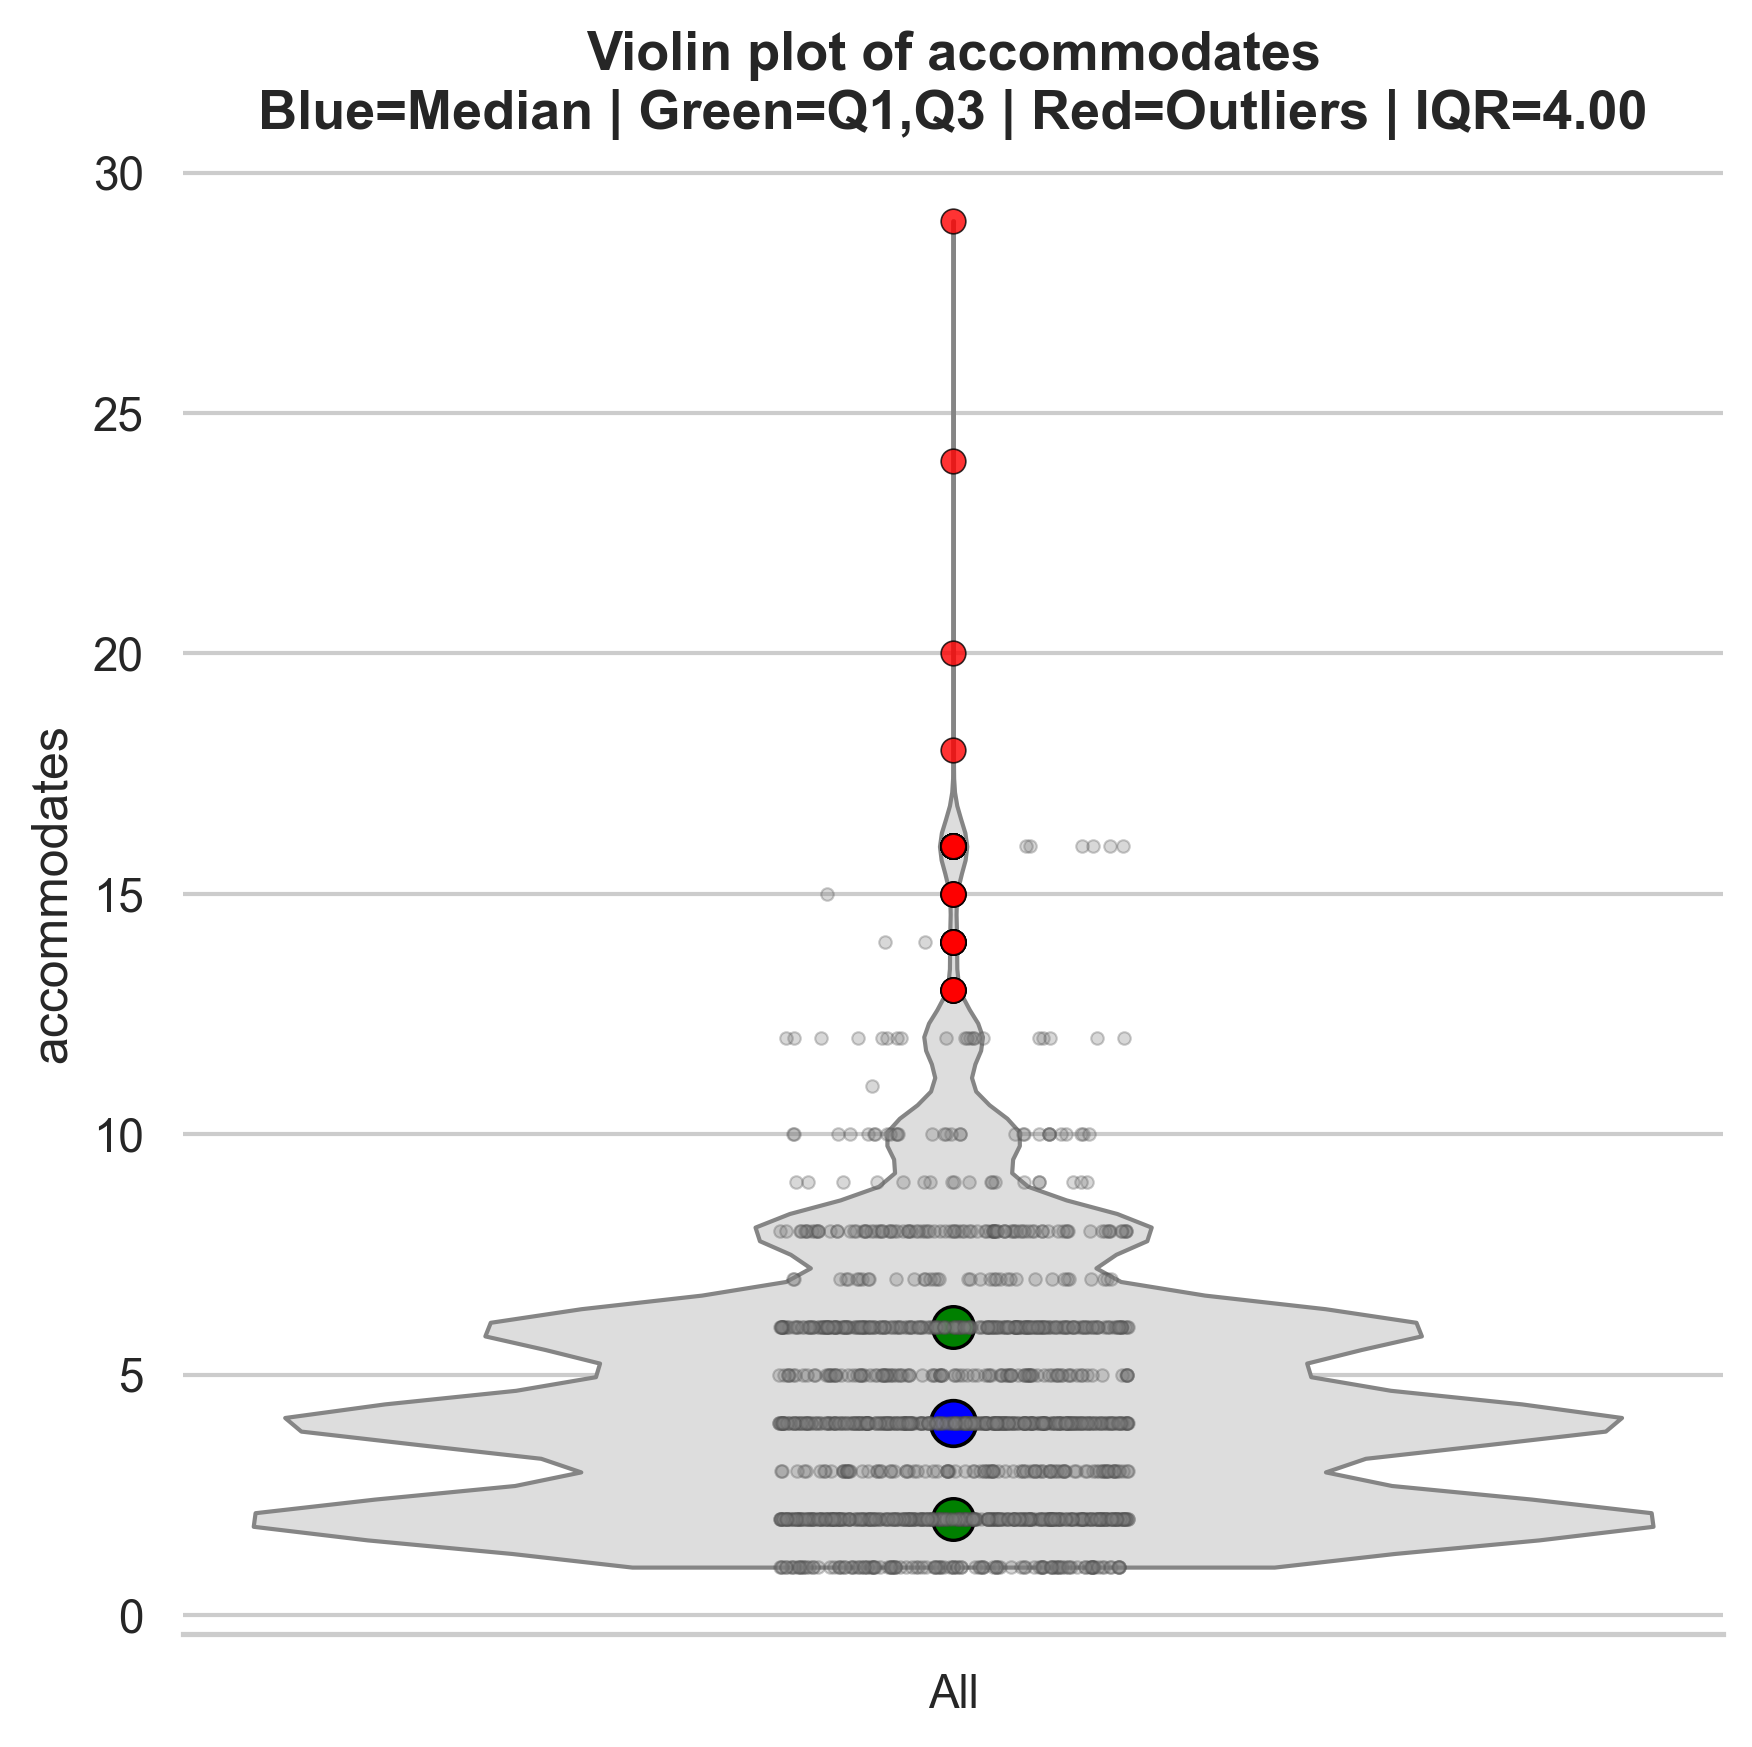

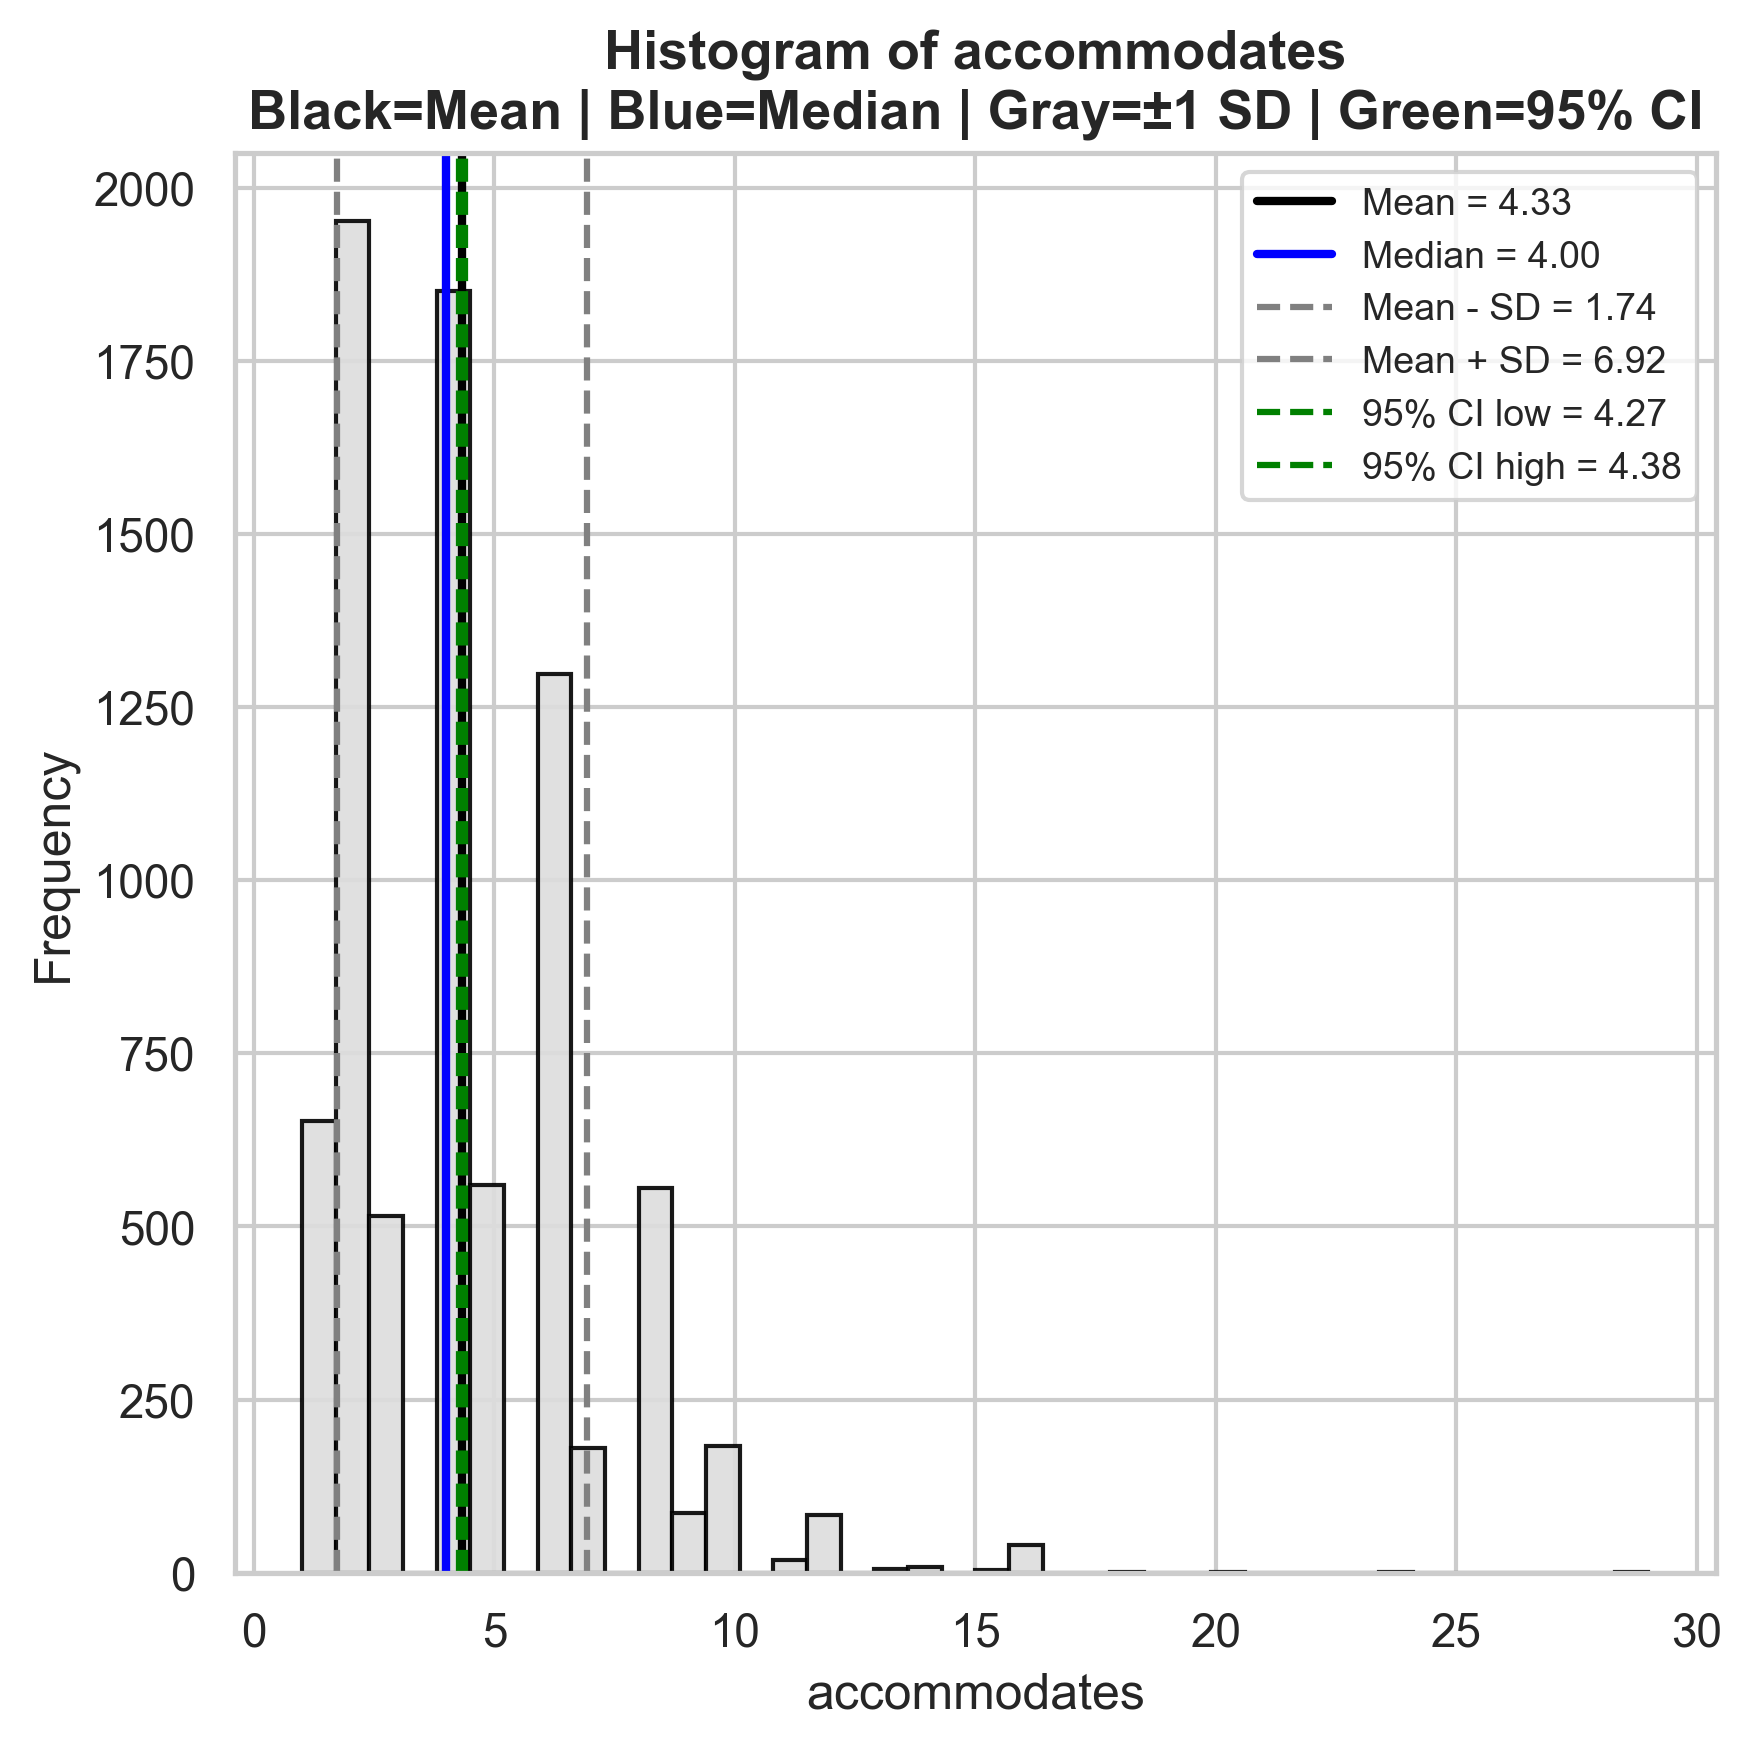

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,accommodates,8000,4.327,4.0,2.59199,4.270193,4.383807,2.0,6.0,4.0,-4.0,12.0,63,1.310459,Highly skewed.



Unique values table
Number of non-nulls: 8000
Number of unique values: 20


,column,value,count,frequency_non_null
0,accommodates,1,653,0.081625
1,accommodates,2,1952,0.244000
2,accommodates,3,515,0.064375
3,accommodates,4,1851,0.231375
4,accommodates,5,560,0.070000
5,accommodates,6,1298,0.162250
6,accommodates,7,180,0.022500
7,accommodates,8,556,0.069500
8,accommodates,9,87,0.010875
9,accommodates,10,183,0.022875



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,accommodates,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,accommodates,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,accommodates,numeric,city,categorical,Chi-square,1989.635951,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,accommodates,numeric,room_type,categorical,Chi-square,4403.540725,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,accommodates,numeric,bathrooms,numeric,Pearson,0.634746,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,accommodates,numeric,bedrooms,numeric,Pearson,0.860997,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,accommodates,numeric,beds,numeric,Pearson,0.873509,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,accommodates,numeric,price,numeric,Pearson,0.619782,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,accommodates,numeric,minimum_nights,numeric,Pearson,-0.038402,5.914548e-04,Significant,Statistically significant at p < 0.05.,
9,accommodates,numeric,maximum_nights,numeric,Pearson,0.082436,1.528132e-13,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.310459,Highly skewed.,Baseline.
1,Log Transformation,-0.308158,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.400427,Approximately symmetric.,Improved strongly; distribution is closer to s...
3,Box-Cox Transformation,-0.023783,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [12]:
analysis = analyze_single_field(
    df, target_col="accommodates", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Accommodates*:
- mediana: 4.0
- IQR=4.0 [2.0; 6.0]
- 63 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: bedrooms (r=0.86), beds (r=0.87)
    * medium and significantly correlated with: bathrooms (r=0.63), price (r=0.62)
    * weakly and significantly correlated with: availability_365 (r=0.12), number_of_reviews (r= -0.12), reviews_per_month (r= - 0.15)
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

##### Number of beds

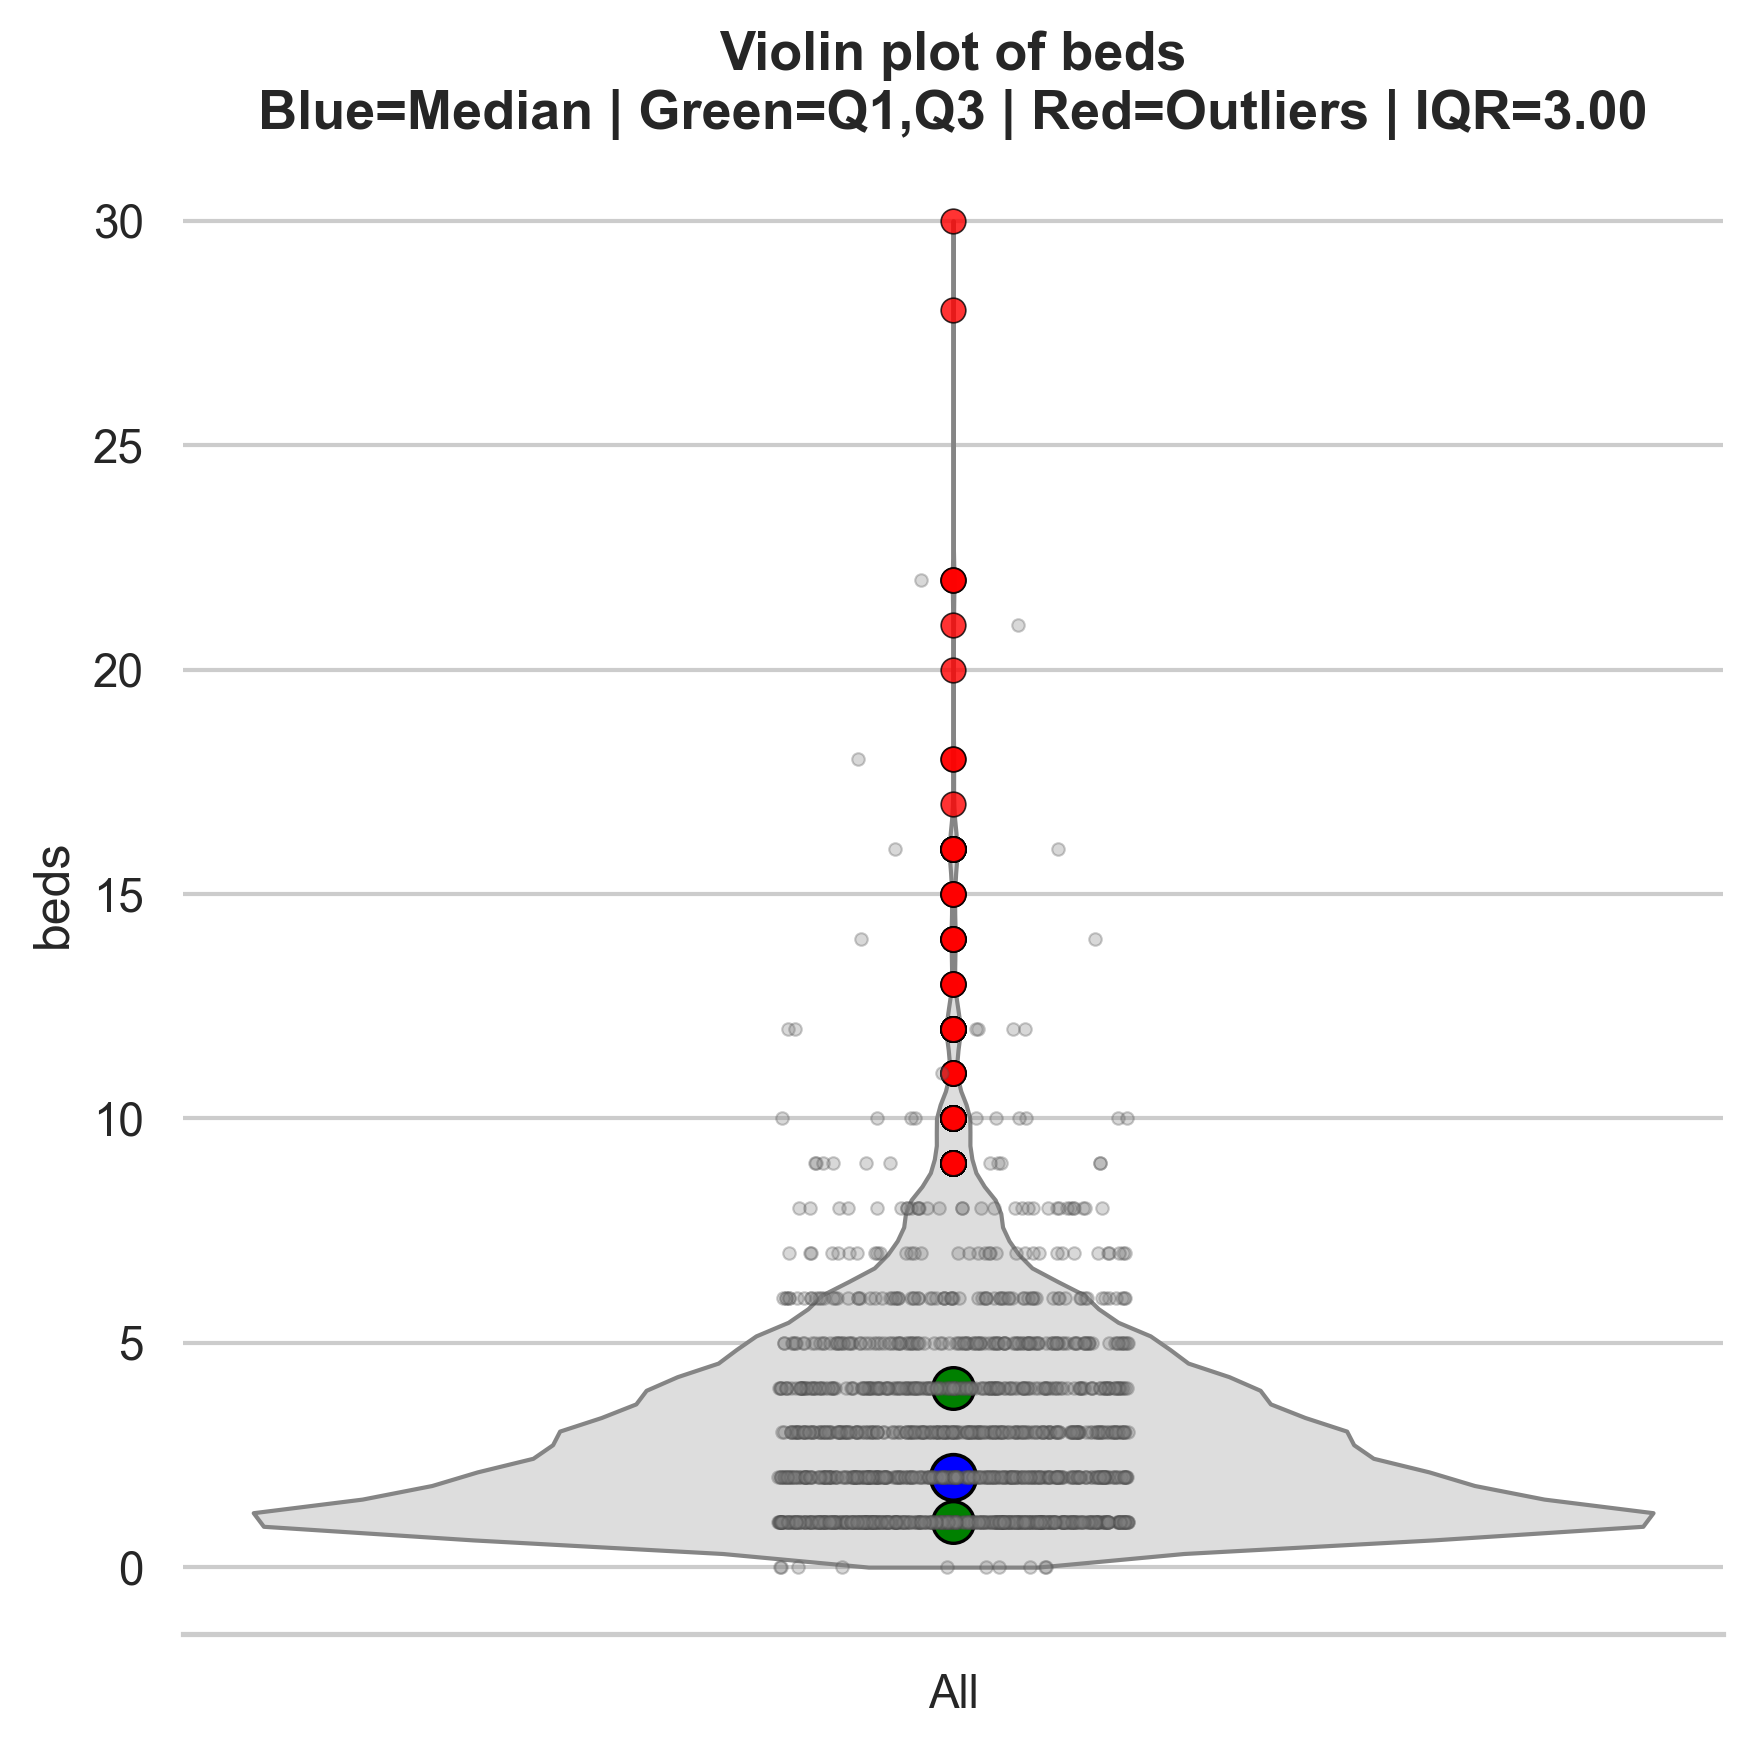

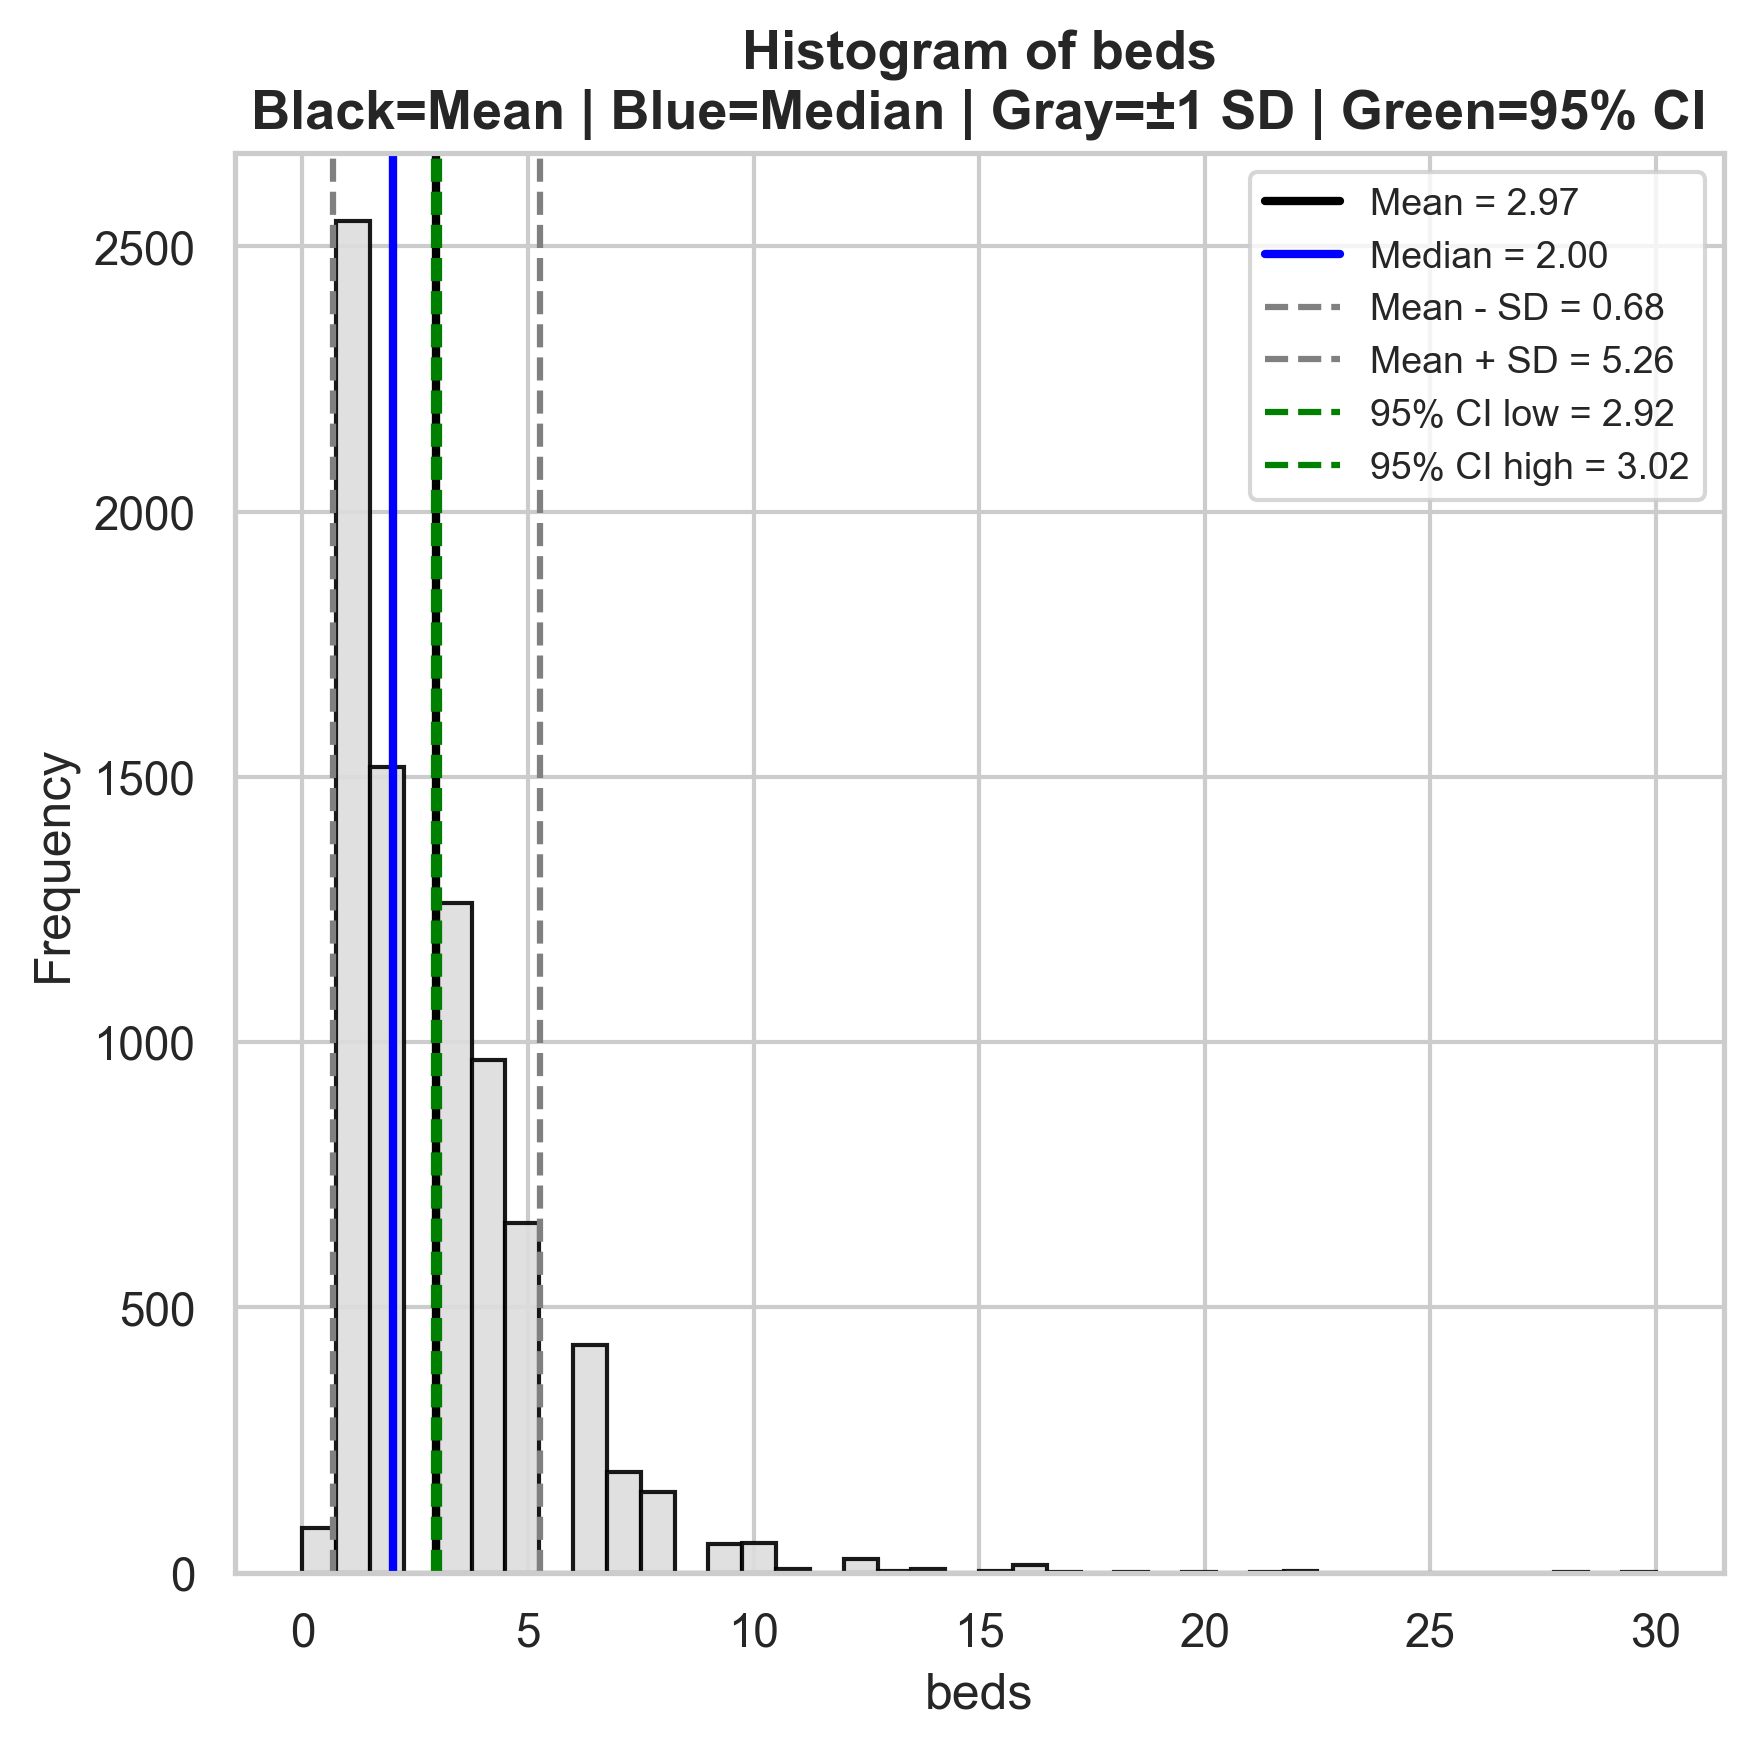

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,beds,7992,2.971346,2.0,2.289586,2.921142,3.021551,1.0,4.0,3.0,-3.5,8.5,183,2.176859,Highly skewed.



Unique values table
Number of non-nulls: 7992
Number of unique values: 24


,column,value,count,frequency_non_null
0,beds,0.0,84,0.010511
1,beds,1.0,2548,0.318819
2,beds,2.0,1518,0.189940
3,beds,3.0,1262,0.157908
4,beds,4.0,966,0.120871
5,beds,5.0,660,0.082583
6,beds,6.0,430,0.053804
7,beds,7.0,189,0.023649
8,beds,8.0,152,0.019019
9,beds,9.0,55,0.006882



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,beds,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,beds,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,beds,numeric,city,categorical,Chi-square,2171.204412,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,beds,numeric,room_type,categorical,Chi-square,3073.415635,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,beds,numeric,accommodates,numeric,Pearson,0.873509,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,beds,numeric,bathrooms,numeric,Pearson,0.640884,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,beds,numeric,bedrooms,numeric,Pearson,0.840095,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,beds,numeric,price,numeric,Pearson,0.574849,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,beds,numeric,minimum_nights,numeric,Pearson,-0.031343,5.074412e-03,Significant,Statistically significant at p < 0.05.,
9,beds,numeric,maximum_nights,numeric,Pearson,0.059646,9.493072e-08,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.176859,Highly skewed.,Baseline.
1,Log Transformation,0.336155,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.656600,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.028733,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [13]:
analysis = analyze_single_field(
    df, target_col="beds", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Beds*:
- mediana: 2.0
- IQR=3.0 [1.0; 4.0]
- 183 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: bedrooms (r=0.84), accomodates (r=0.87)
    * medium and significantly correlated with: bathrooms (r=0.64), price (r=0.58)
    * weakly and significantly correlated with: availability_365 (r=0.12), number_of_reviews (r= -0.14), reviews_per_month (r= - 0.19)
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

##### Price

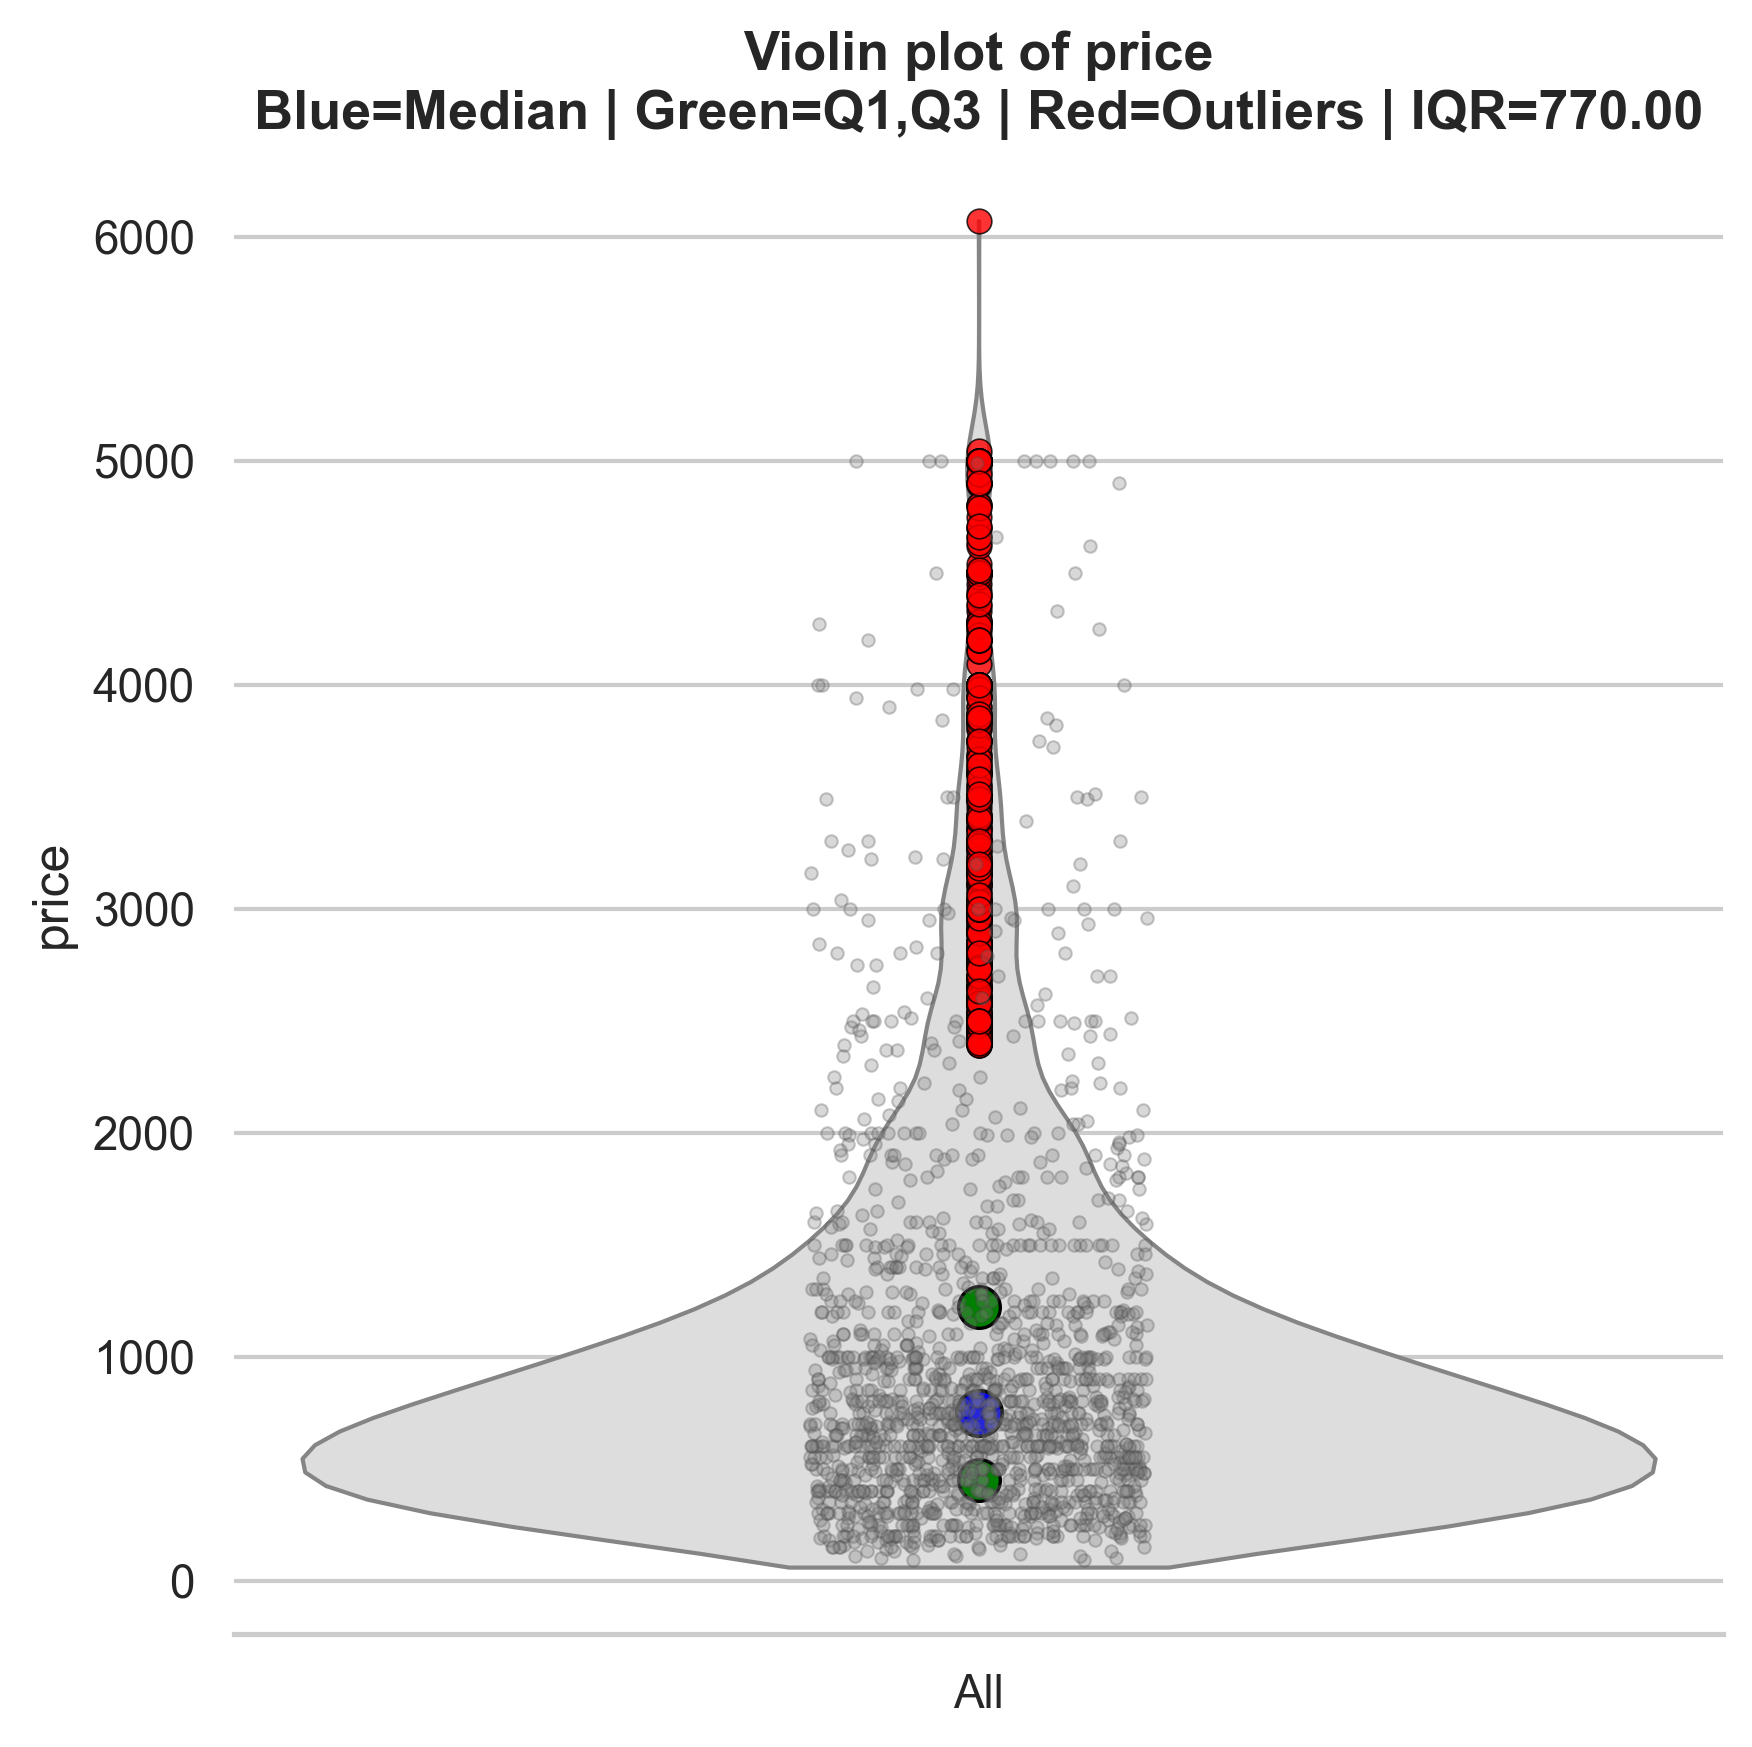

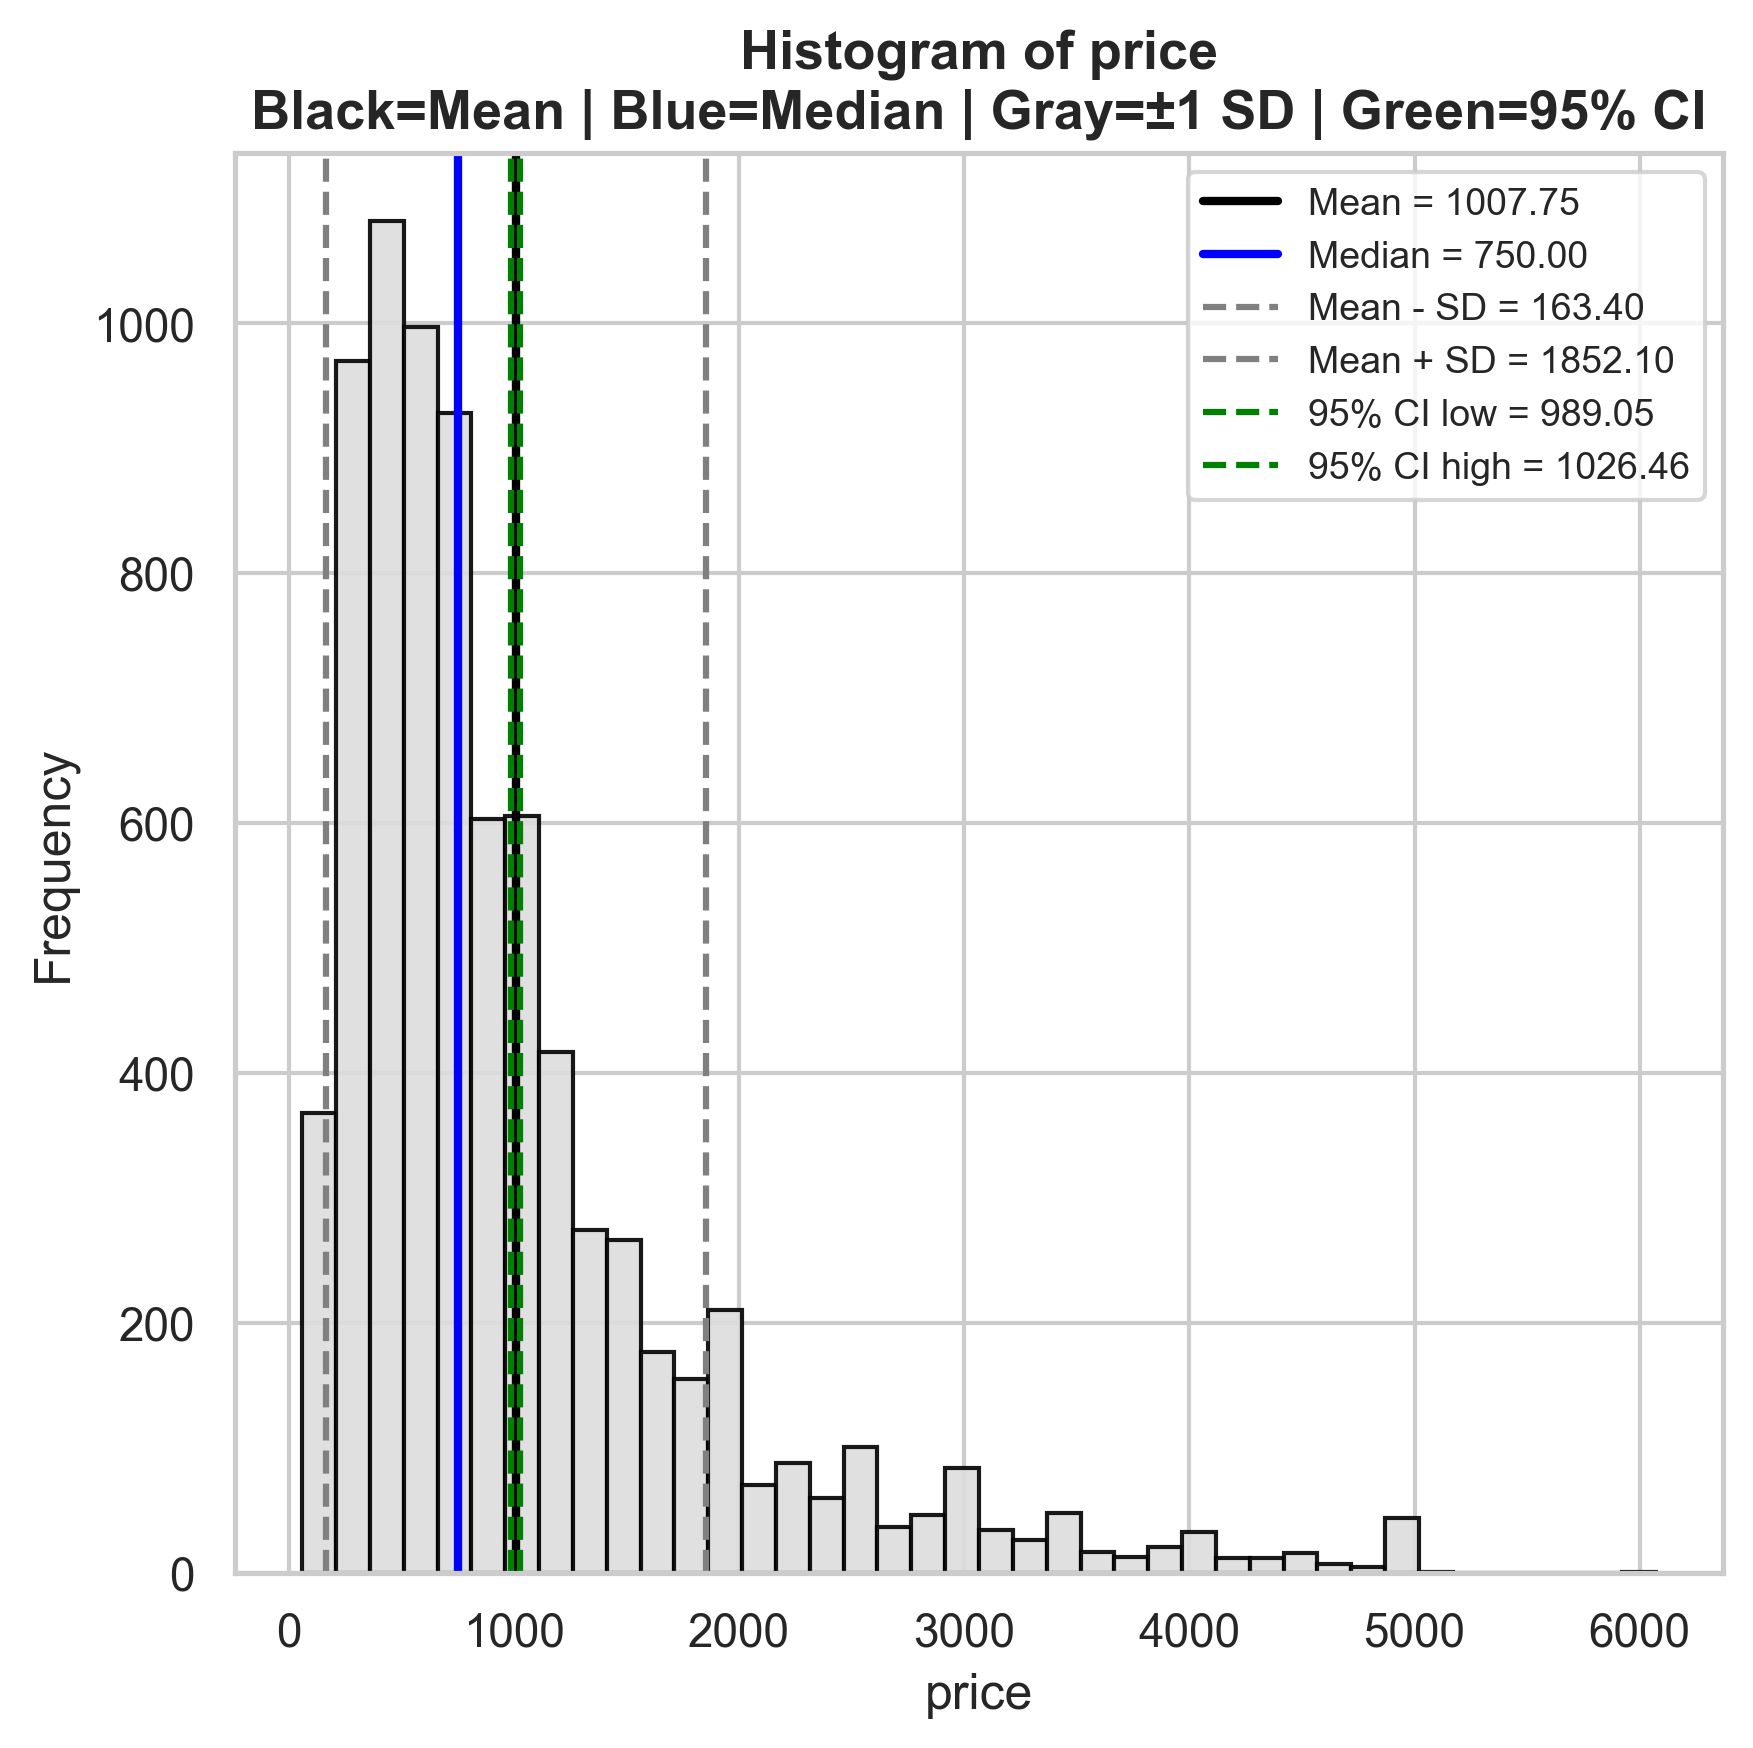

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,price,7829,1007.751182,750.0,844.347373,989.045081,1026.457282,450.0,1220.0,770.0,-705.0,2375.0,597,2.074509,Highly skewed.



Unique values table
Number of non-nulls: 7829
Number of unique values: 392


,column,value,count,frequency_non_null
0,price,60.0,1,0.000128
1,price,80.0,5,0.000639
2,price,90.0,4,0.000511
3,price,100.0,14,0.001788
4,price,110.0,6,0.000766
...,...,...,...,...
387,price,4940.0,1,0.000128
388,price,4990.0,3,0.000383
389,price,5000.0,35,0.004471
390,price,5043.0,1,0.000128



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,price,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,price,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,price,numeric,city,categorical,Chi-square,1625.001125,0.000000e+00,Significant,Statistically significant at p < 0.05.,
3,price,numeric,room_type,categorical,Chi-square,3699.849242,0.000000e+00,Significant,Statistically significant at p < 0.05.,
4,price,numeric,accommodates,numeric,Pearson,0.619782,0.000000e+00,Significant,Statistically significant at p < 0.05.,
5,price,numeric,bathrooms,numeric,Pearson,0.522015,0.000000e+00,Significant,Statistically significant at p < 0.05.,
6,price,numeric,bedrooms,numeric,Pearson,0.614192,0.000000e+00,Significant,Statistically significant at p < 0.05.,
7,price,numeric,beds,numeric,Pearson,0.574849,0.000000e+00,Significant,Statistically significant at p < 0.05.,
8,price,numeric,minimum_nights,numeric,Pearson,-0.025142,2.610563e-02,Significant,Statistically significant at p < 0.05.,
9,price,numeric,maximum_nights,numeric,Pearson,0.040012,3.983471e-04,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,2.074509,Highly skewed.,Baseline.
1,Log Transformation,0.072090,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.062605,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.002009,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [9]:
analysis = analyze_single_field(
    df, target_col="price", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Price*:
- mediana: 750.0
- IQR=770.0 [450.0; 1220.0]
- 597 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: accommodates (r=0.62), bathrooms (r=0.52), bedrooms (r=0.61), beds (r=0.57)
    * weakly and significantly correlated with: availability_365 (r=0.14), number_of_reviews (r= -0.15), reviews_per_month (r= - 0.19)
    * absence of correlation with: minimum_nights, maximum_nights, availability_30, availability_60, availability_90, review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value
- Spearman correlation with other numeric variables must be used

<Axes: xlabel='room_type', ylabel='city'>

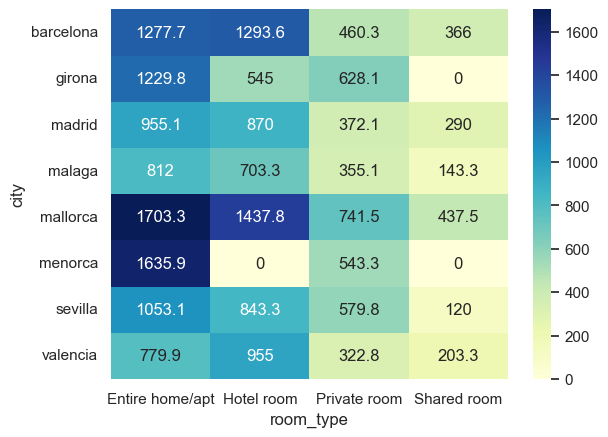

In [10]:
sns.heatmap(
    df.groupby(["city", "room_type"])["price"].mean().round(1).unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Minimal number of nights

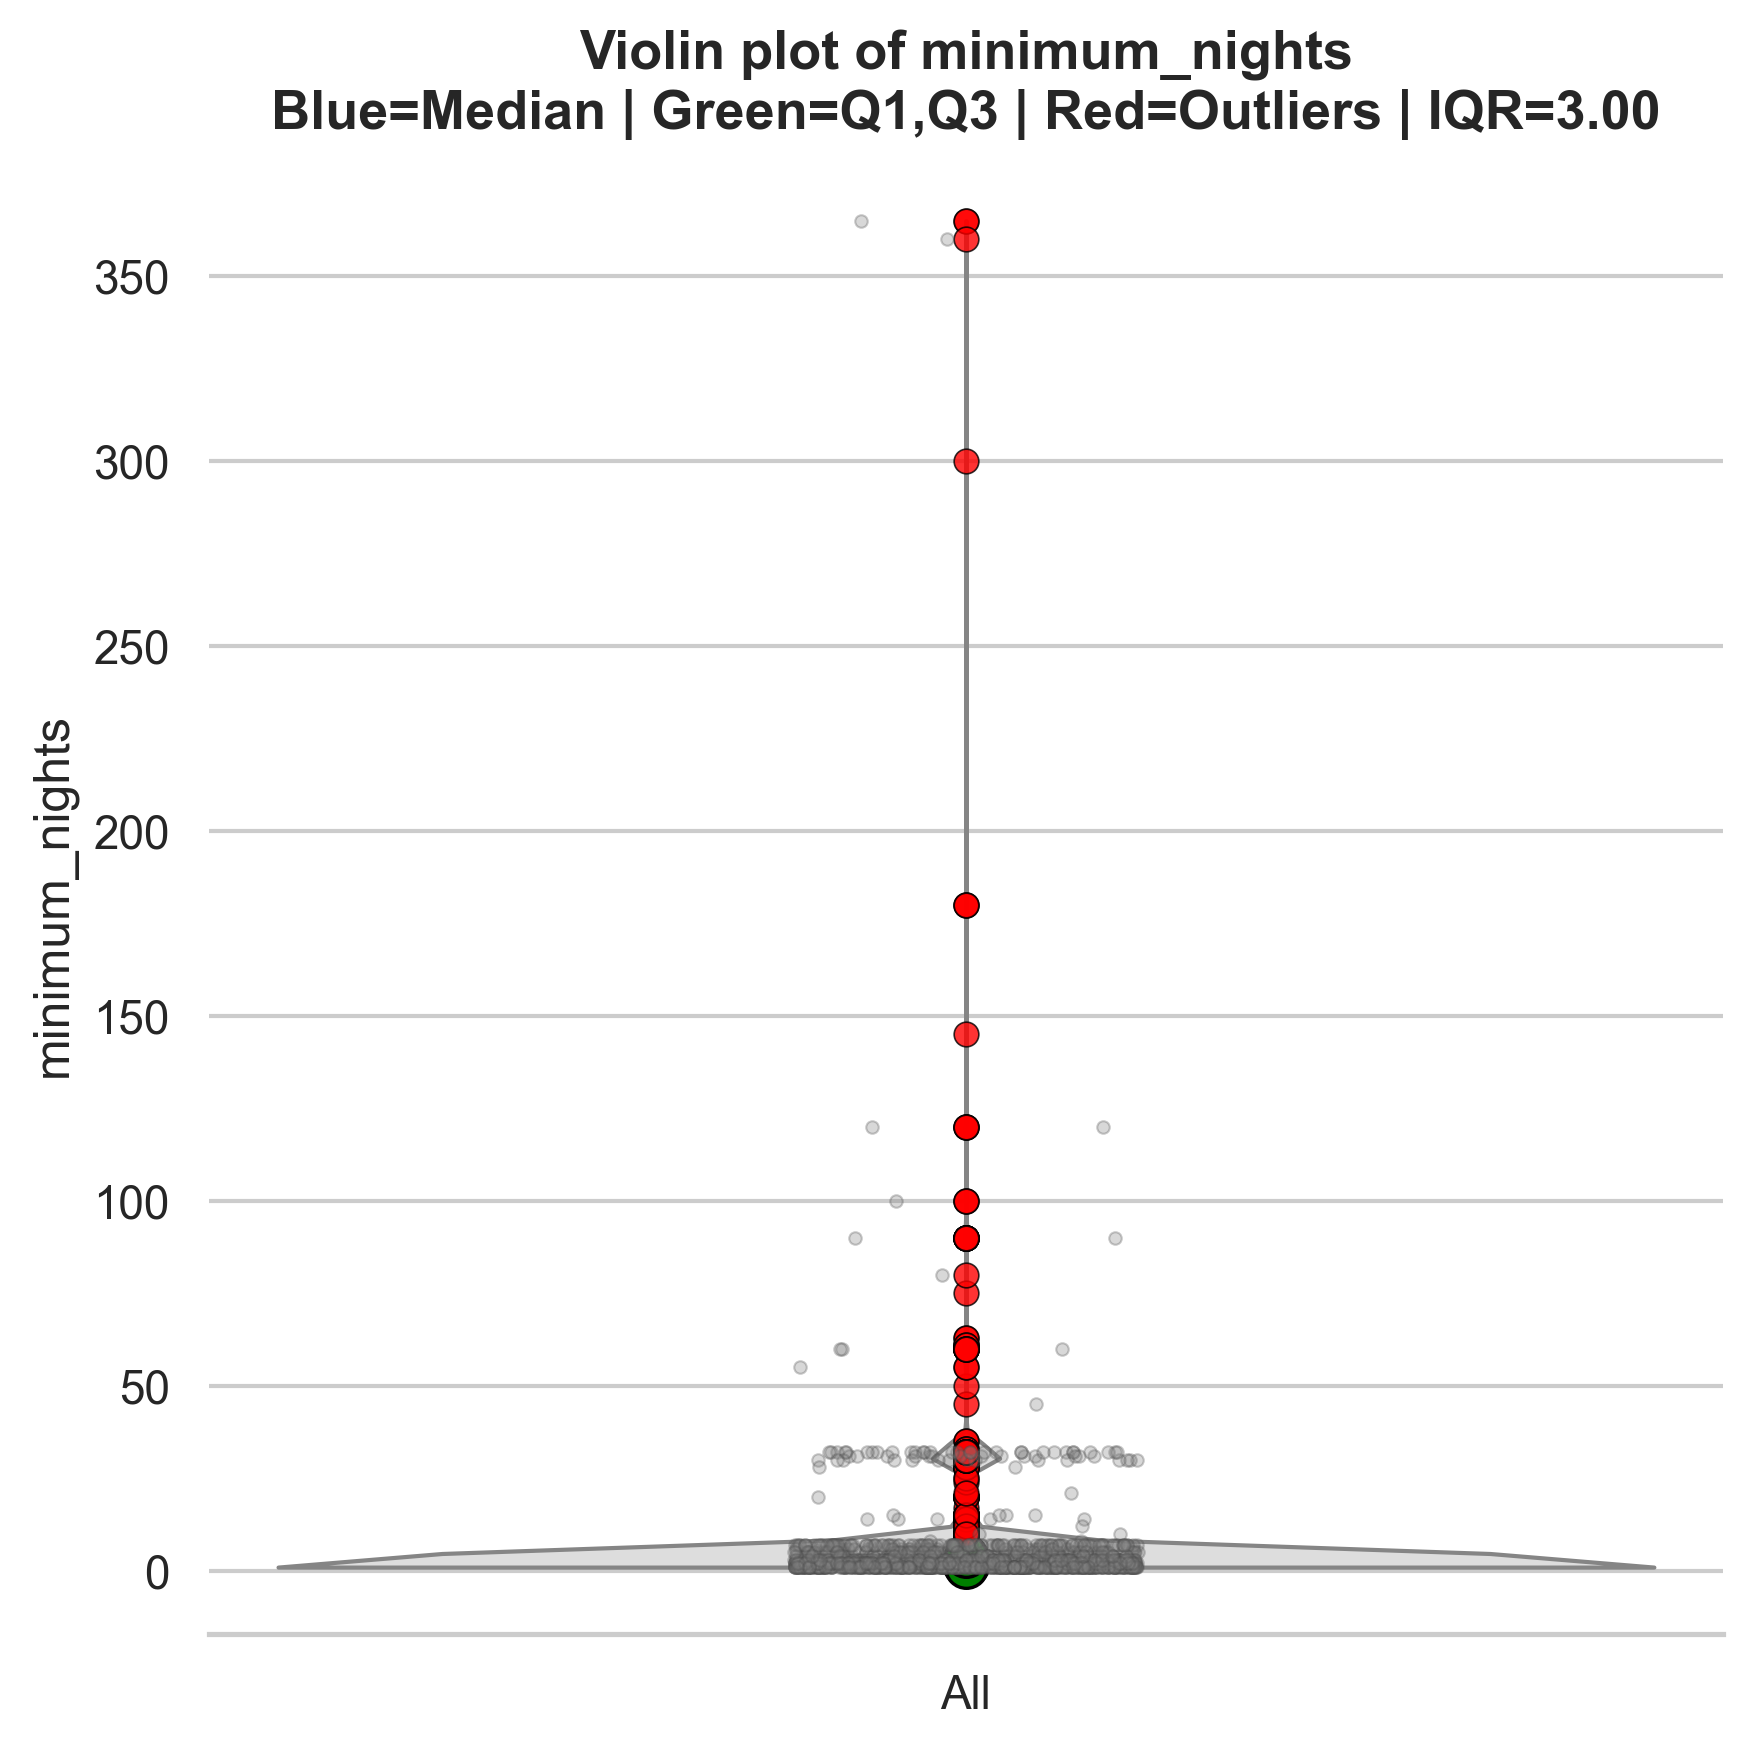

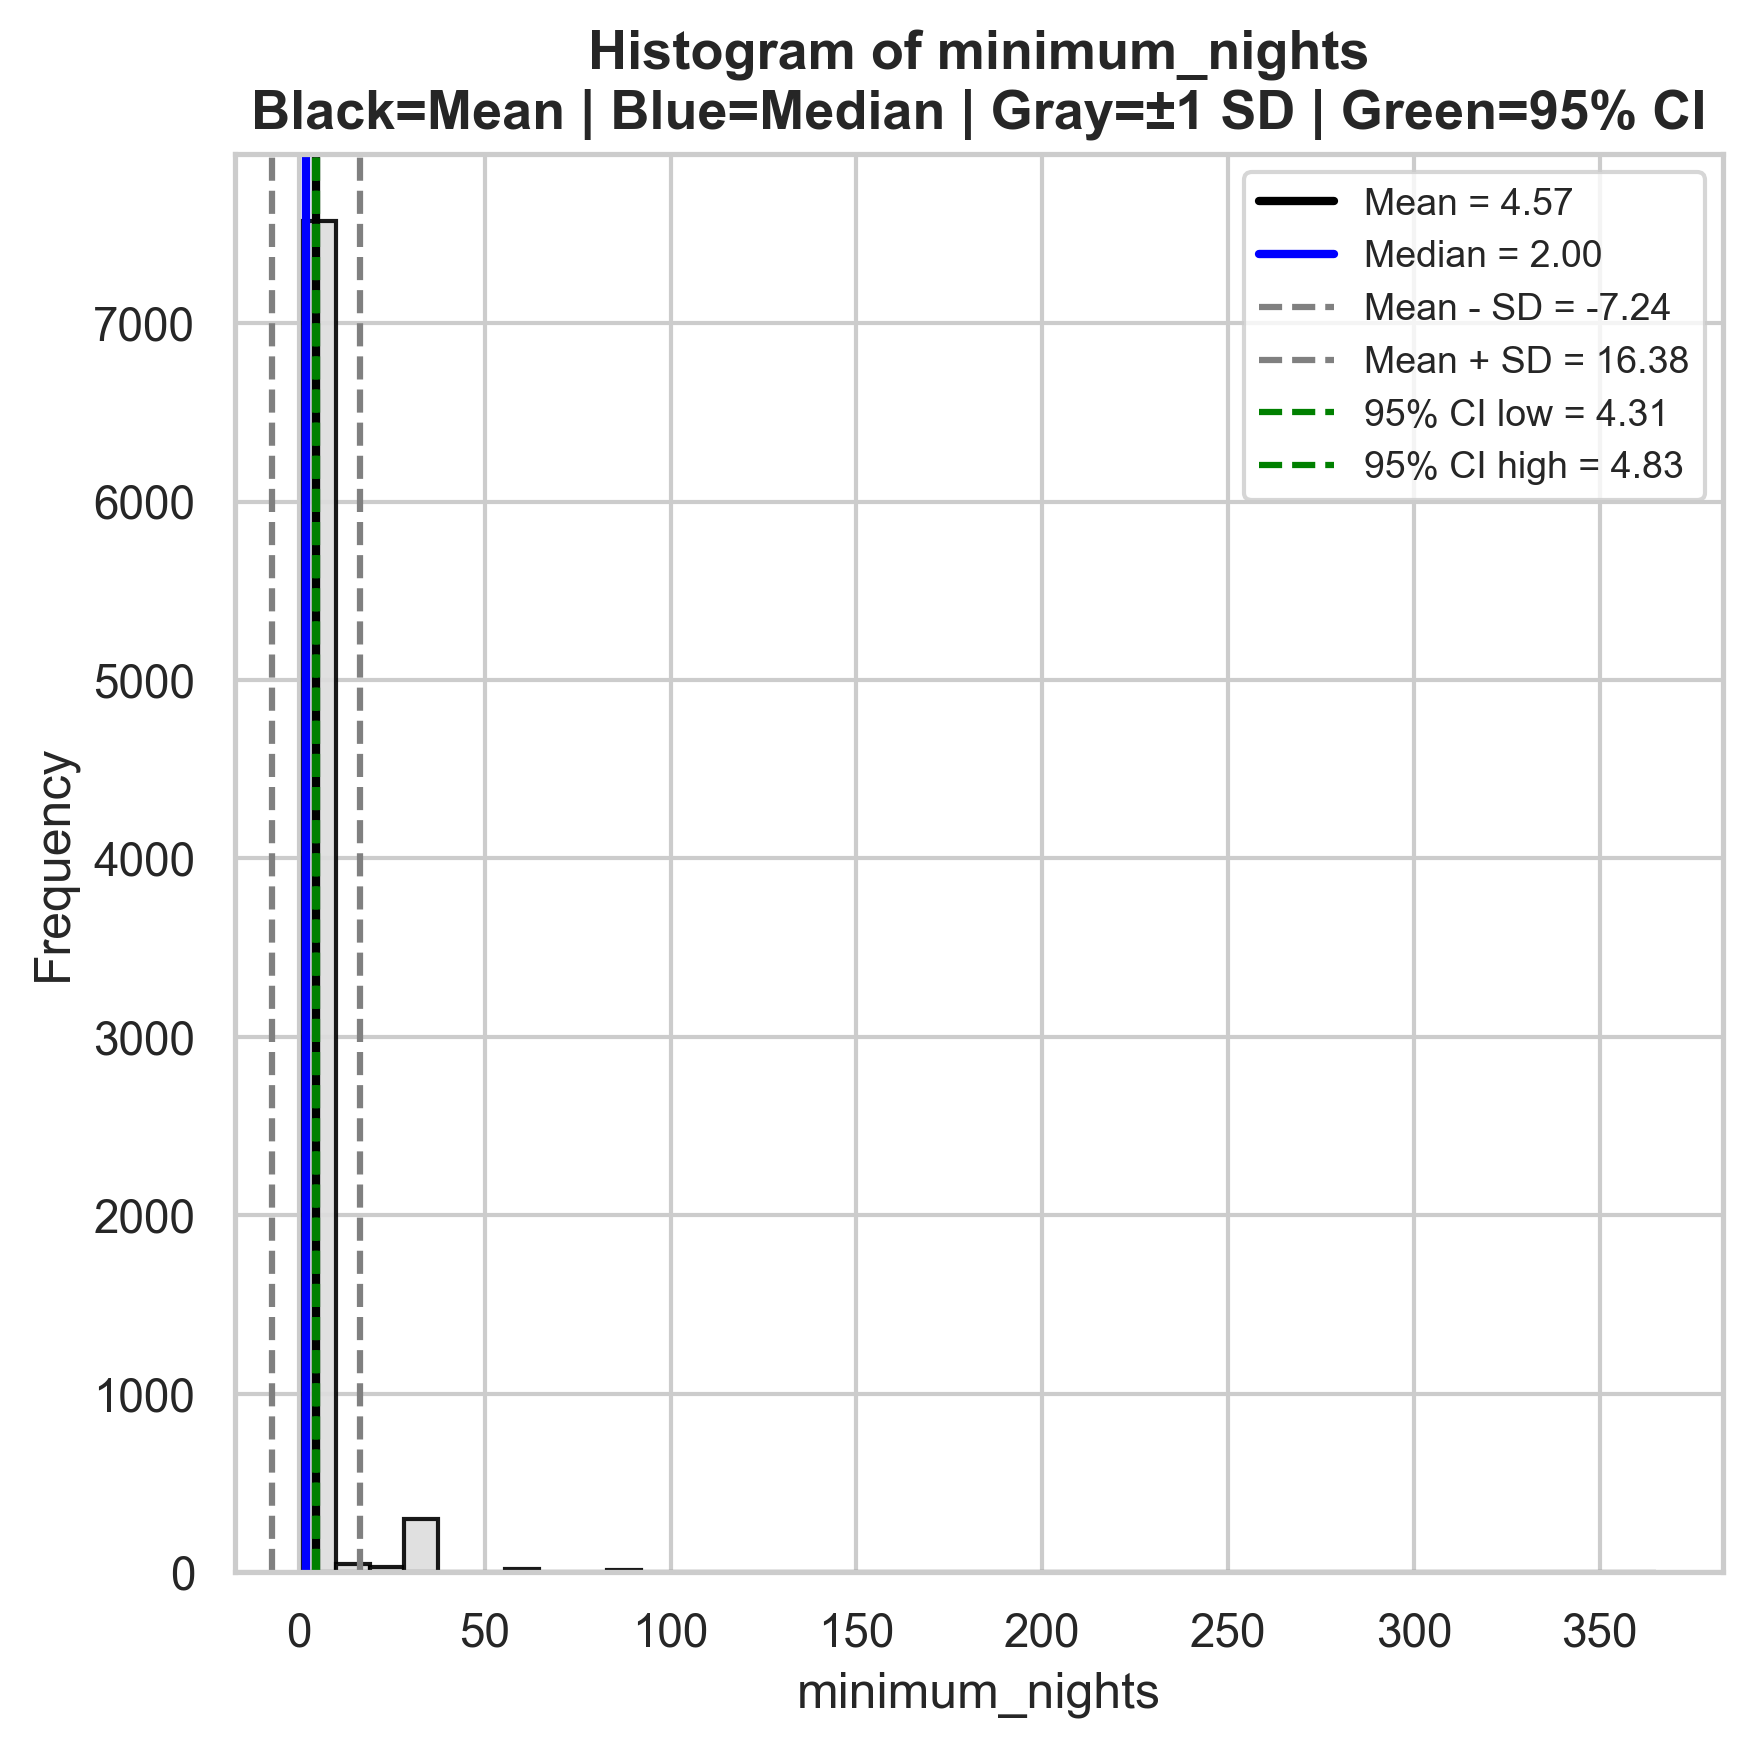

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,minimum_nights,8000,4.57125,2.0,11.80783,4.312465,4.830035,1.0,4.0,3.0,-3.5,8.5,447,15.945109,Highly skewed.



Unique values table
Number of non-nulls: 8000
Number of unique values: 41


,column,value,count,frequency_non_null
0,minimum_nights,1,2373,0.296625
1,minimum_nights,2,2179,0.272375
2,minimum_nights,3,1263,0.157875
3,minimum_nights,4,482,0.060250
4,minimum_nights,5,467,0.058375
5,minimum_nights,6,131,0.016375
6,minimum_nights,7,652,0.081500
7,minimum_nights,8,6,0.000750
8,minimum_nights,10,18,0.002250
9,minimum_nights,11,2,0.000250



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,minimum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,minimum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,minimum_nights,numeric,city,categorical,Chi-square,1207.221448,1.678516e-242,Significant,Statistically significant at p < 0.05.,
3,minimum_nights,numeric,room_type,categorical,Chi-square,335.909615,6.162737e-67,Significant,Statistically significant at p < 0.05.,
4,minimum_nights,numeric,accommodates,numeric,Pearson,-0.038402,5.914548e-04,Significant,Statistically significant at p < 0.05.,
5,minimum_nights,numeric,bathrooms,numeric,Pearson,-0.005838,6.025705e-01,Not significant,Not statistically significant at p < 0.05.,
6,minimum_nights,numeric,bedrooms,numeric,Pearson,-0.010771,3.365784e-01,Not significant,Not statistically significant at p < 0.05.,
7,minimum_nights,numeric,beds,numeric,Pearson,-0.031343,5.074412e-03,Significant,Statistically significant at p < 0.05.,
8,minimum_nights,numeric,price,numeric,Pearson,-0.025142,2.610563e-02,Significant,Statistically significant at p < 0.05.,
9,minimum_nights,numeric,maximum_nights,numeric,Pearson,-0.009598,3.906882e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,15.945109,Highly skewed.,Baseline.
1,Log Transformation,1.303589,Highly skewed.,Improved; skewness decreased.
2,Square Root Transformation,4.432252,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.121681,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [11]:
analysis = analyze_single_field(
    df, target_col="minimum_nights", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Minimum number of nights*:
- mediana: 2.0
- IQR=3.0 [1.0; 4.0]
- 447 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: none found
    * weakly and significantly correlated with: reviews_per_month (r= - 0.11)
    * absence of correlation with: all other variables

##### Maximal numbert of nights

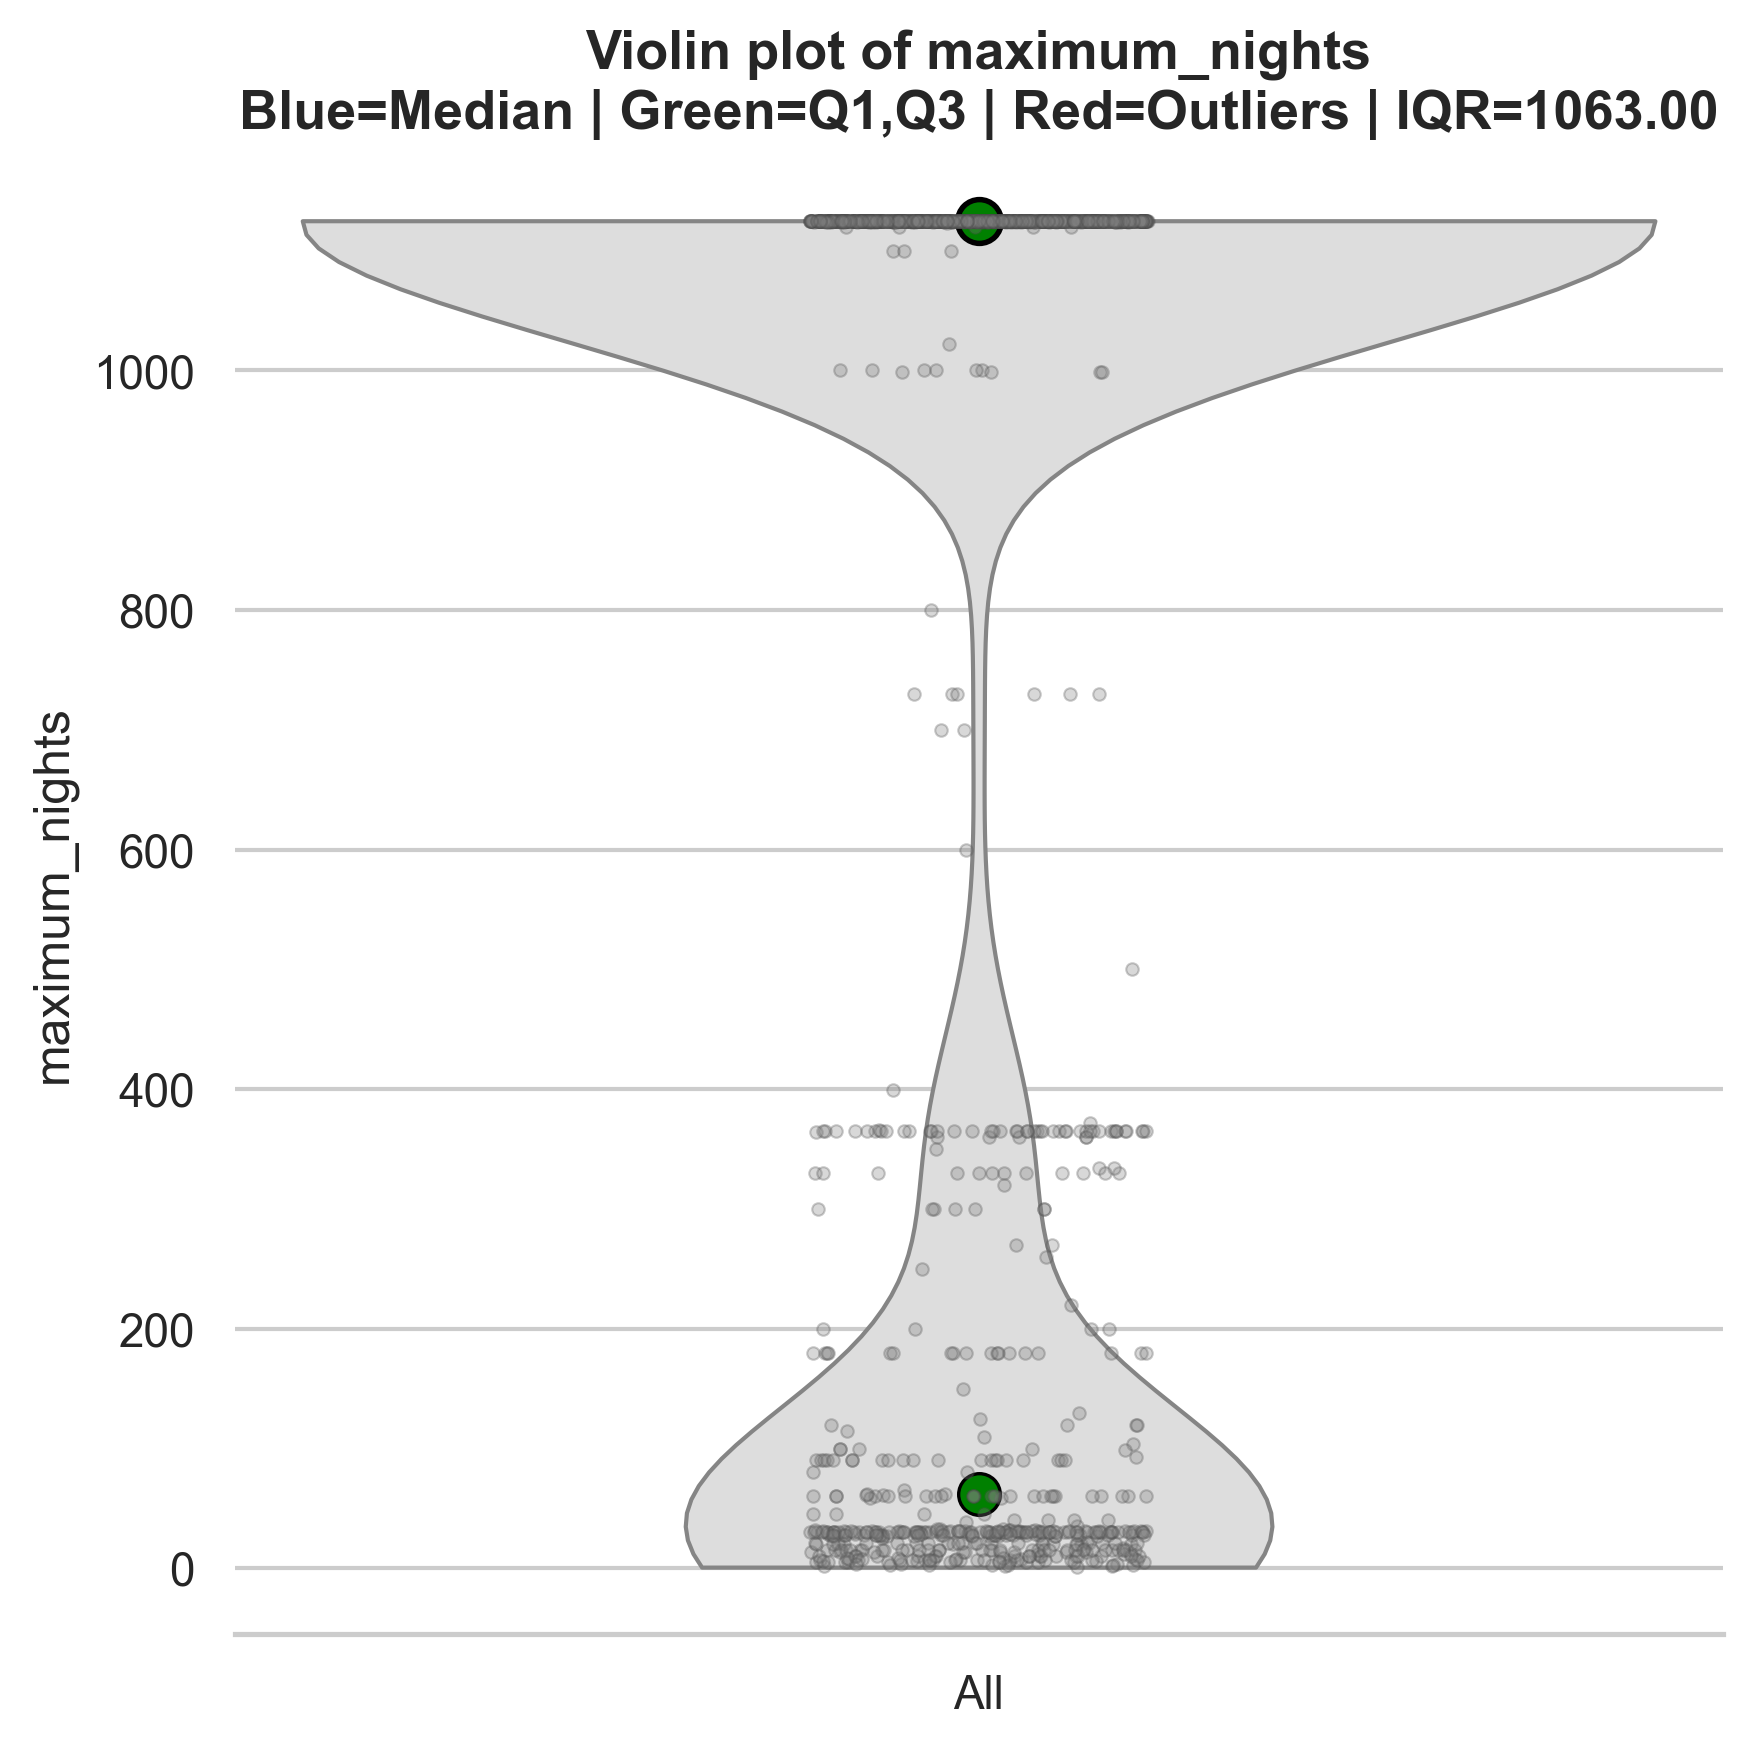

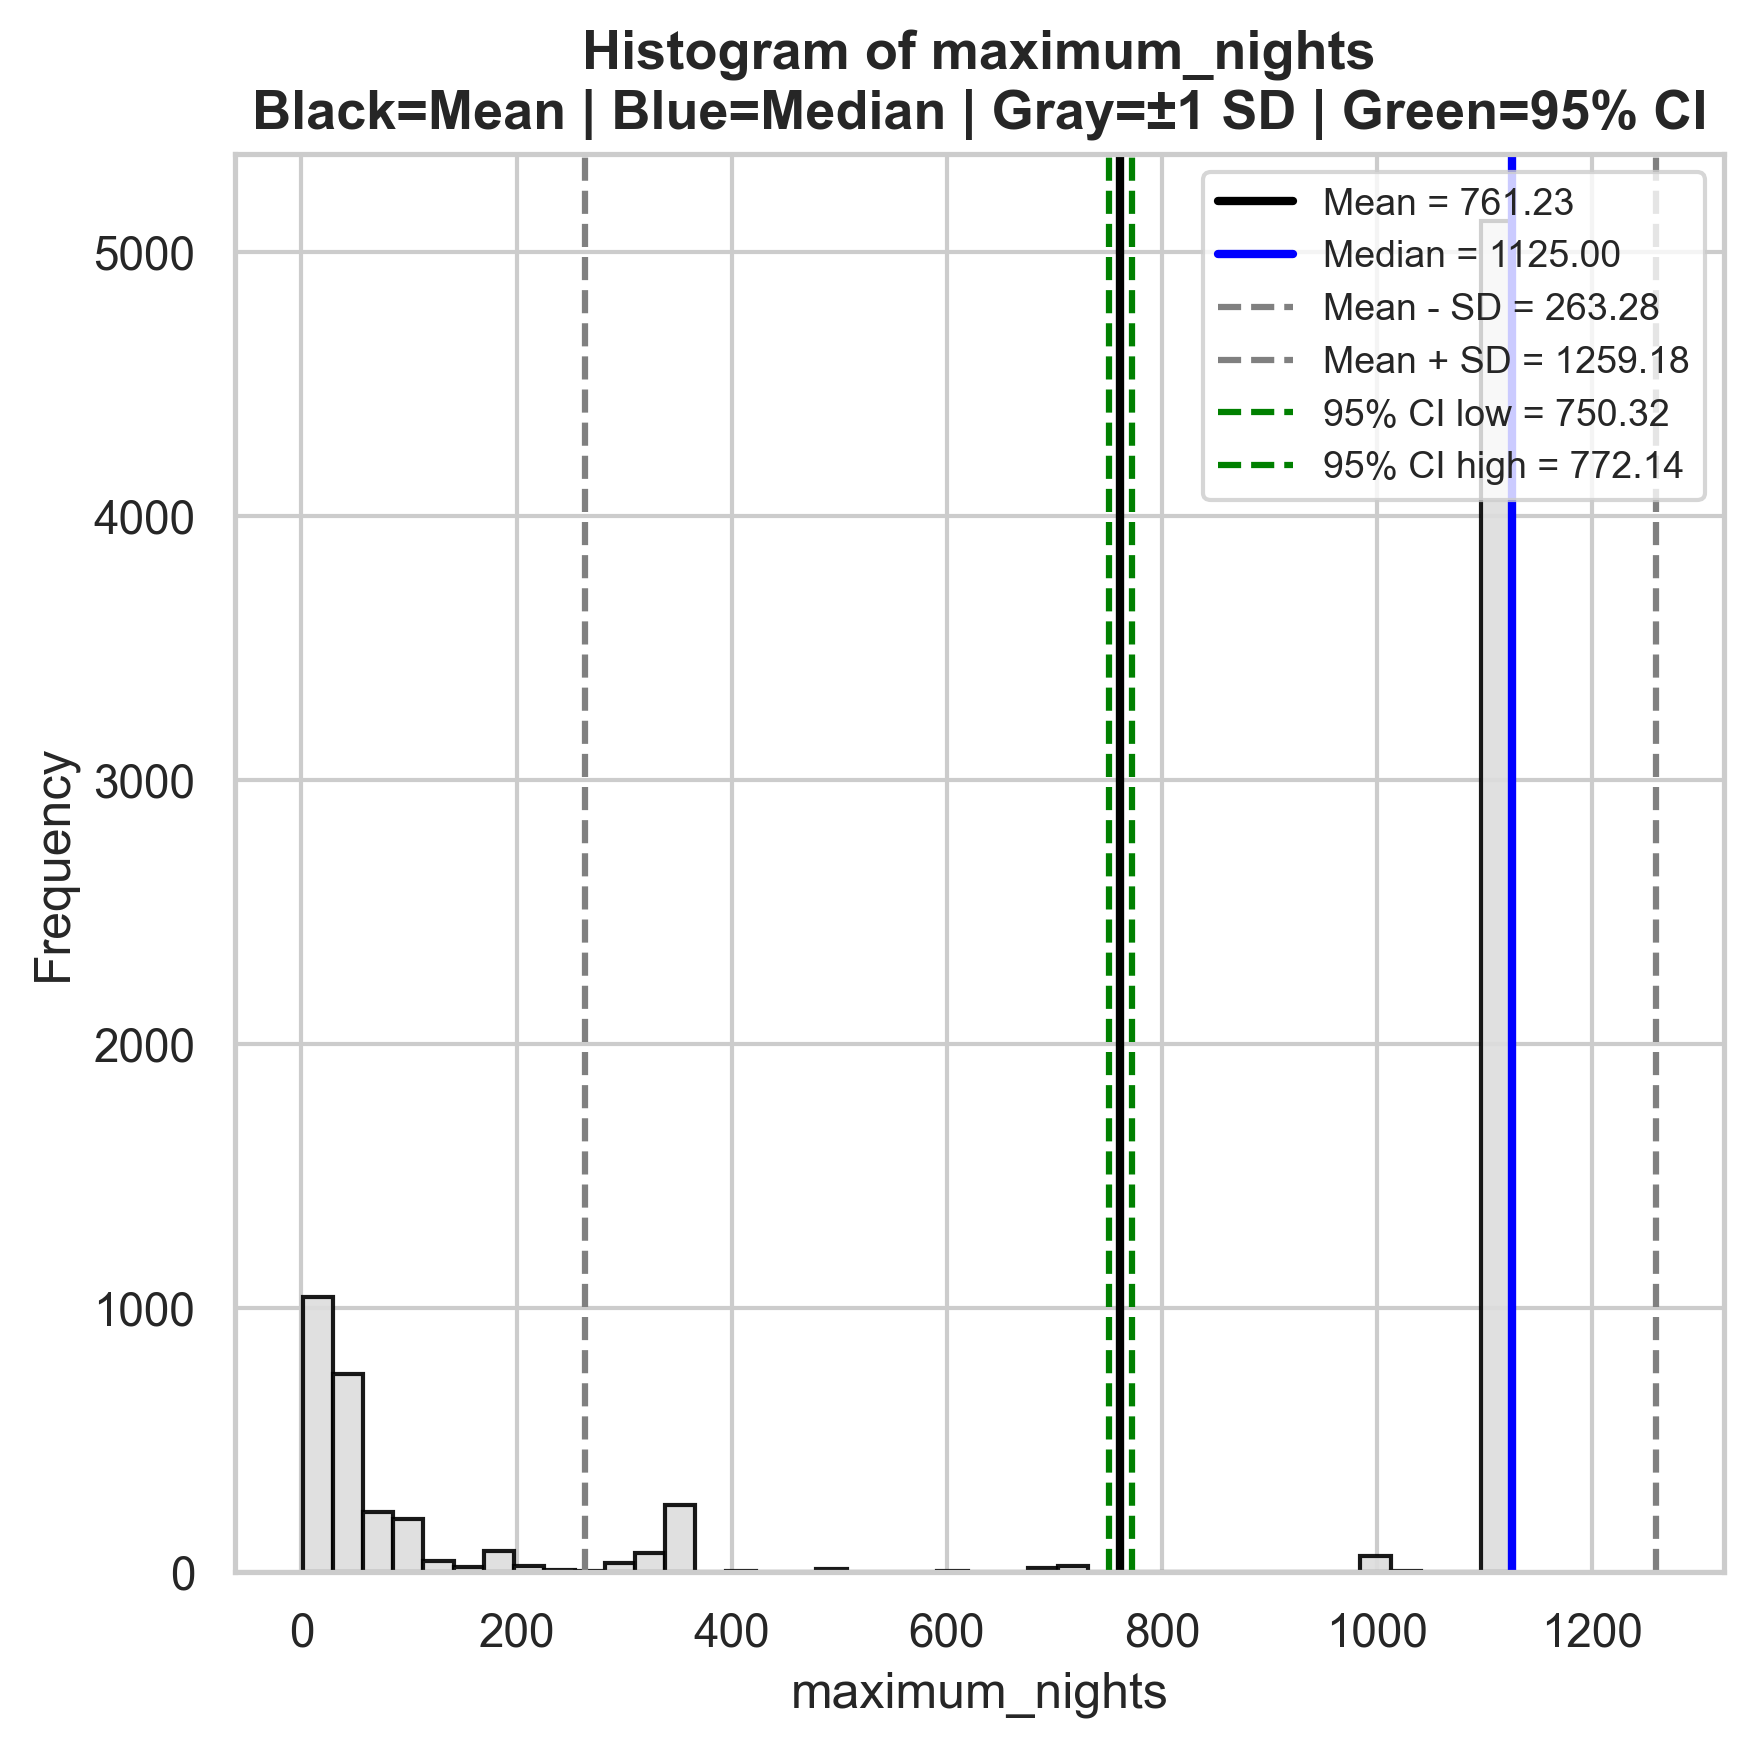

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,maximum_nights,8000,761.230125,1125.0,497.949602,750.316872,772.143378,62.0,1125.0,1063.0,-1532.5,2719.5,0,-0.684326,Moderately skewed.



Unique values table
Number of non-nulls: 8000
Number of unique values: 135


,column,value,count,frequency_non_null
0,maximum_nights,1,5,0.000625
1,maximum_nights,2,11,0.001375
2,maximum_nights,3,32,0.004000
3,maximum_nights,4,28,0.003500
4,maximum_nights,5,50,0.006250
...,...,...,...,...
130,maximum_nights,1121,1,0.000125
131,maximum_nights,1122,3,0.000375
132,maximum_nights,1123,12,0.001500
133,maximum_nights,1124,199,0.024875



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,maximum_nights,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,maximum_nights,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,maximum_nights,numeric,city,categorical,Chi-square,62.764263,4.225563e-11,Significant,Statistically significant at p < 0.05.,
3,maximum_nights,numeric,room_type,categorical,Chi-square,189.005138,1.001181e-40,Significant,Statistically significant at p < 0.05.,
4,maximum_nights,numeric,accommodates,numeric,Pearson,0.082436,1.528132e-13,Significant,Statistically significant at p < 0.05.,
5,maximum_nights,numeric,bathrooms,numeric,Pearson,0.053864,1.527885e-06,Significant,Statistically significant at p < 0.05.,
6,maximum_nights,numeric,bedrooms,numeric,Pearson,0.052576,2.684731e-06,Significant,Statistically significant at p < 0.05.,
7,maximum_nights,numeric,beds,numeric,Pearson,0.059646,9.493072e-08,Significant,Statistically significant at p < 0.05.,
8,maximum_nights,numeric,price,numeric,Pearson,0.040012,3.983471e-04,Significant,Statistically significant at p < 0.05.,
9,maximum_nights,numeric,minimum_nights,numeric,Pearson,-0.009598,3.906882e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.684326,Moderately skewed.,Baseline.
1,Log Transformation,-1.102906,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.785208,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.747147,Moderately skewed.,Little change in skewness. Lambda=0.6365 did n...


In [12]:
analysis = analyze_single_field(
    df, target_col="maximum_nights", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Maximum number of nights*:
- mediana: 1125.0
- IQR=1063.0 [62.0; 1125.0]
- no outliers determined
- about 61% of publications set the maximal value for this parameter: 1125
- no Transformation to obtain normal distribution of the data is needed, must be interpreted as categorical parameter
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * absence of correlation with: all other variables
- Non-parametric tests for association should be applied

##### Availability 30 days

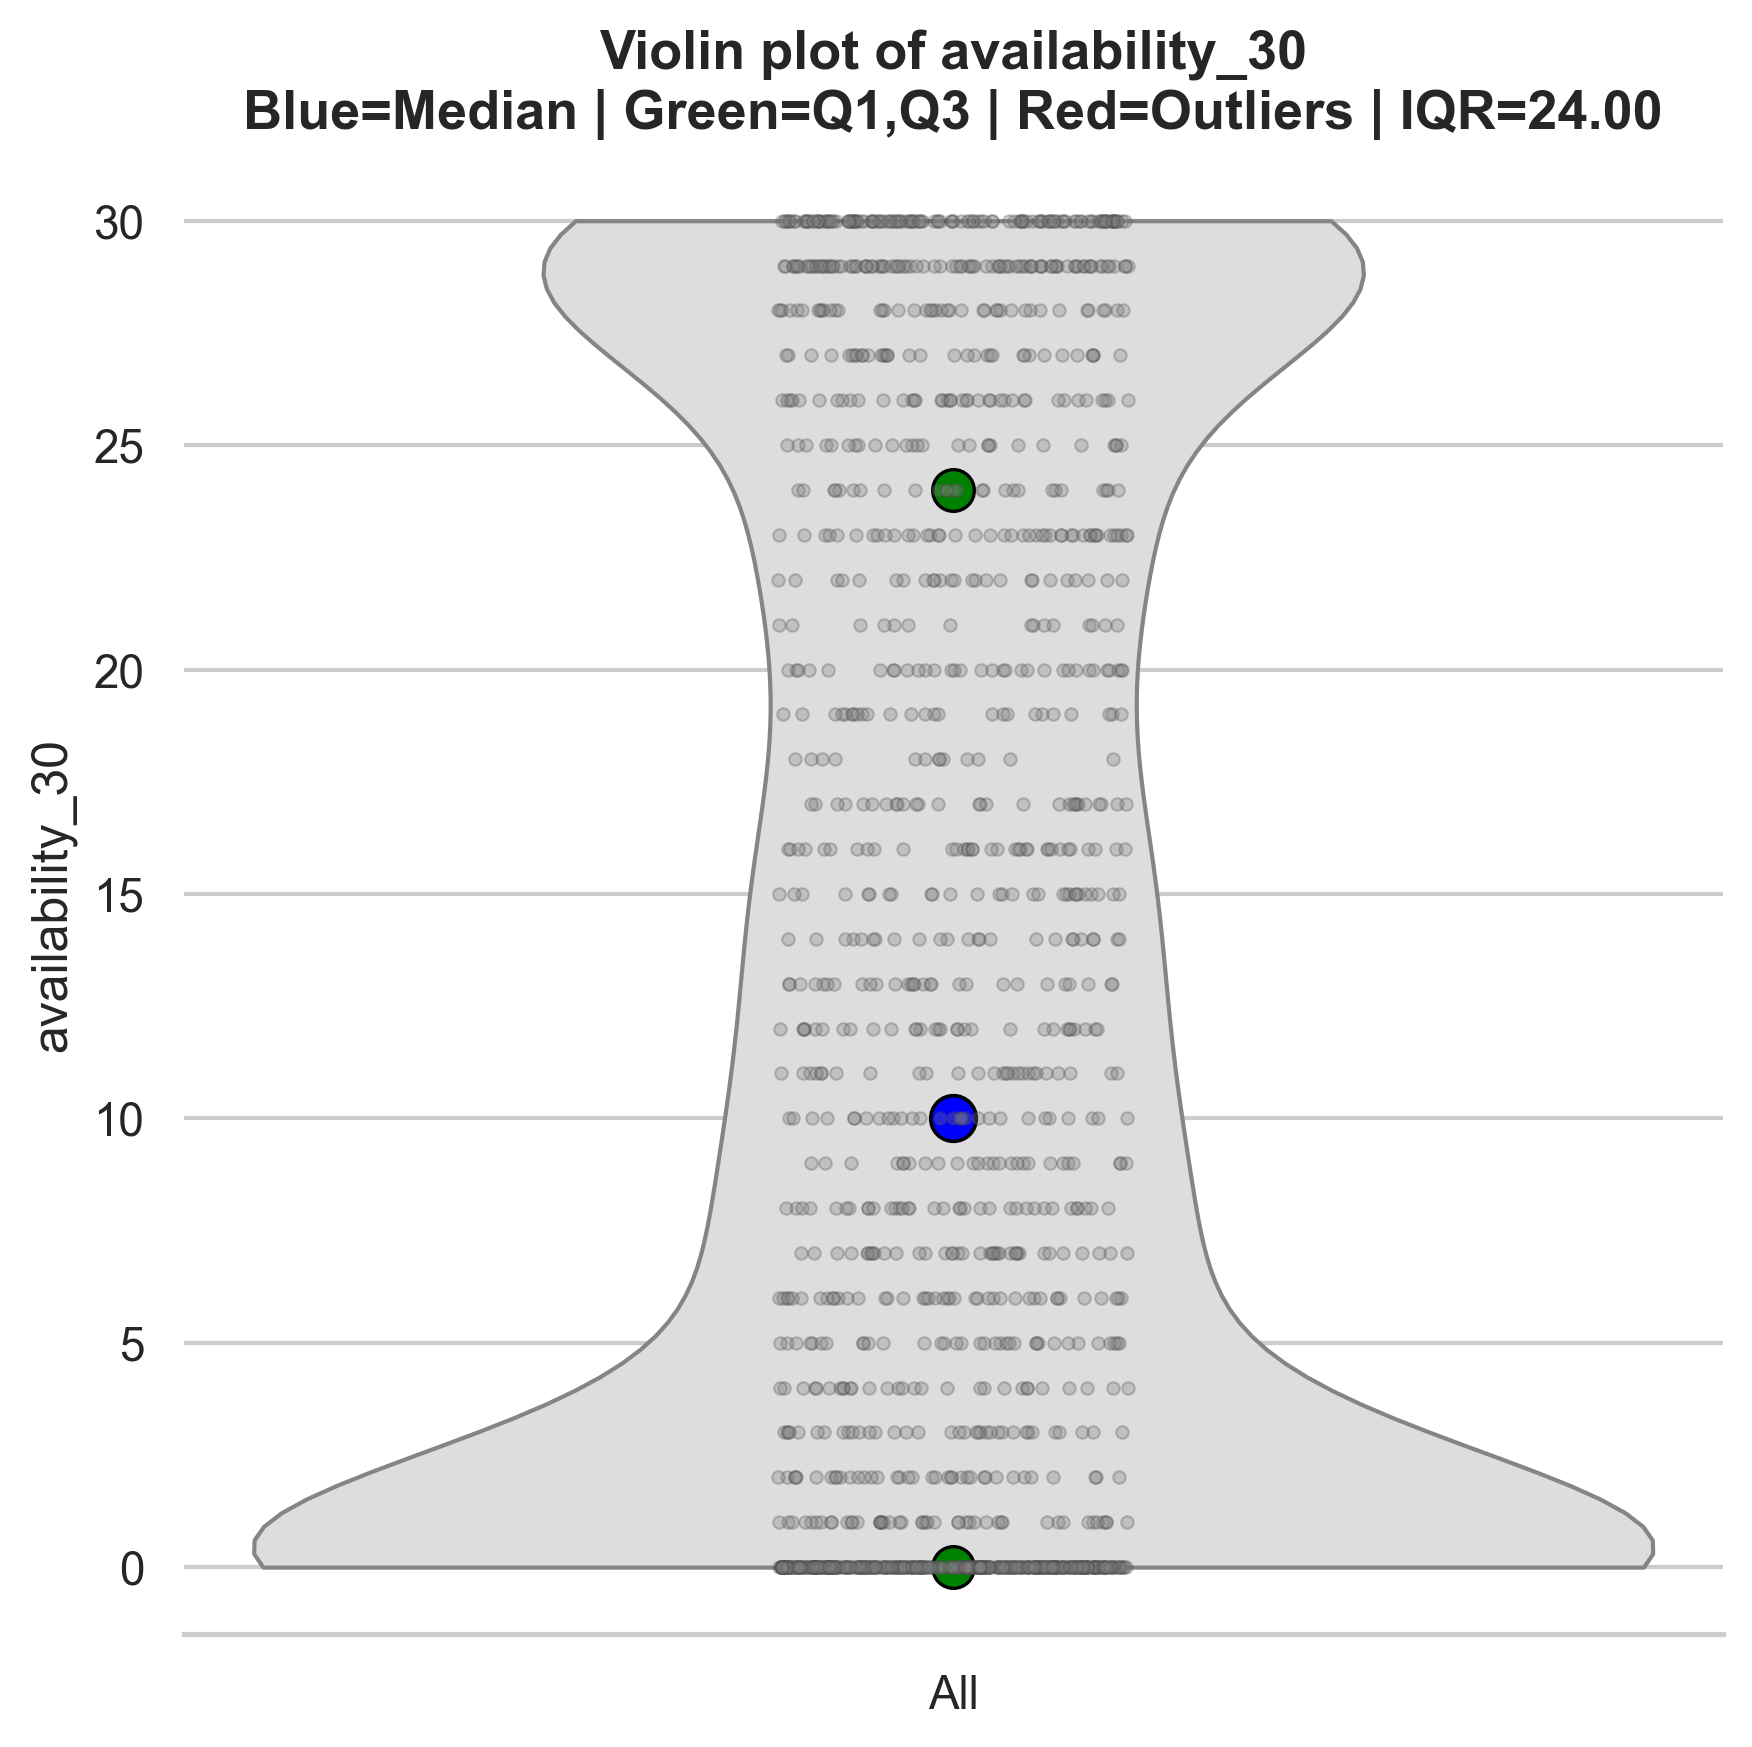

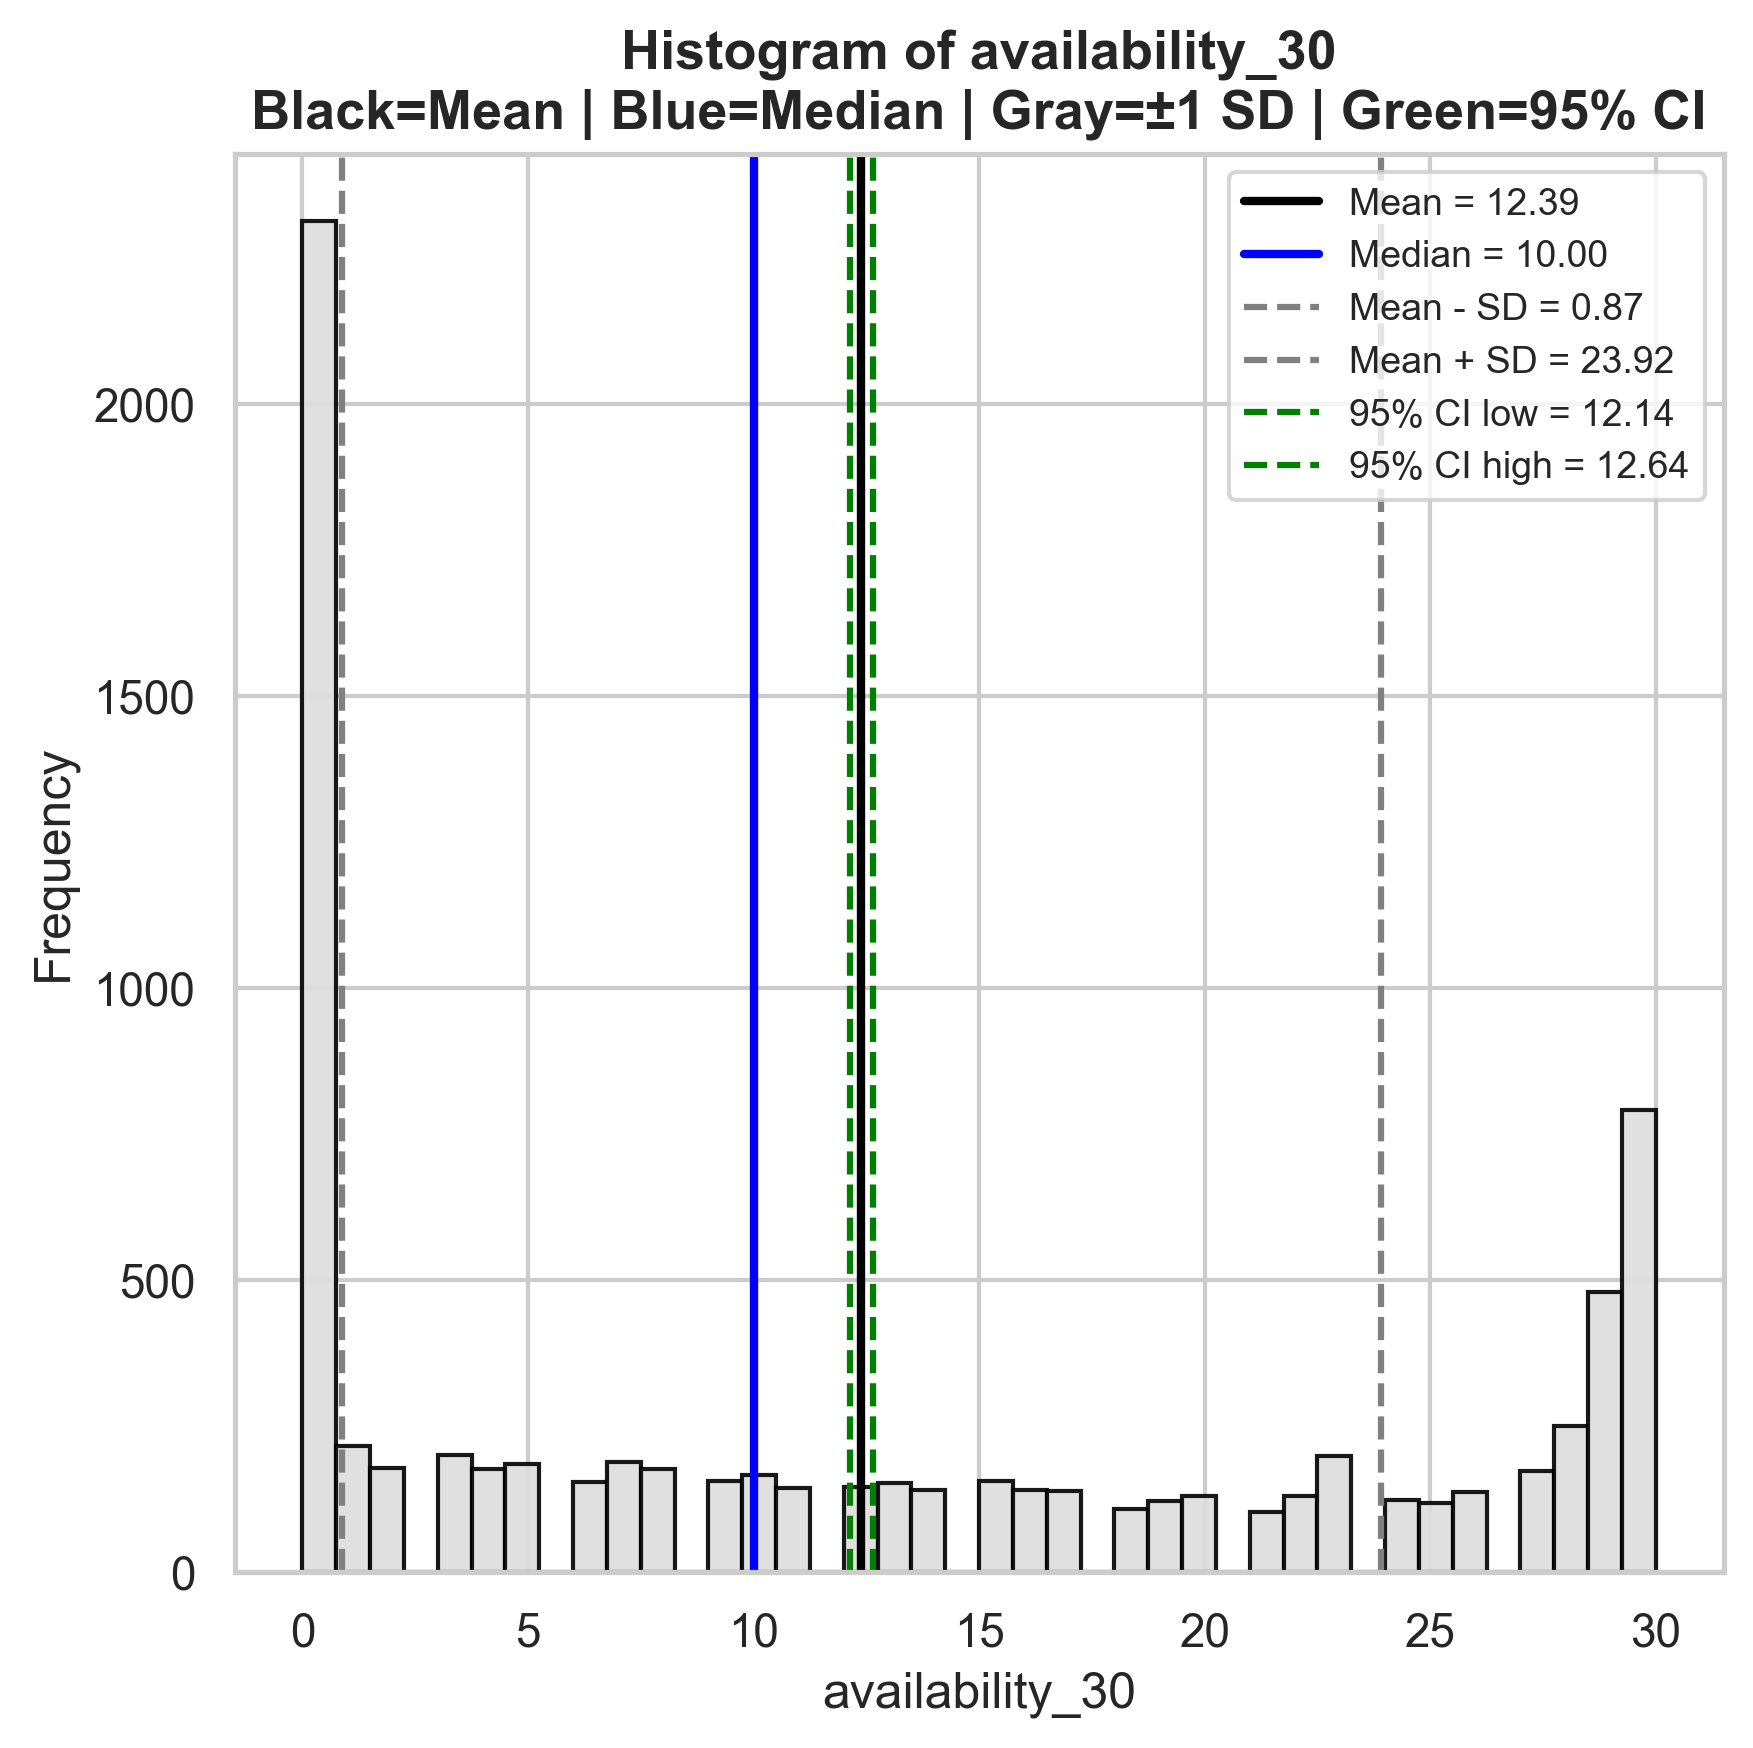

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_30,8000,12.39125,10.0,11.524301,12.138679,12.643821,0.0,24.0,24.0,-36.0,60.0,0,0.325647,Approximately symmetric.



Unique values table
Number of non-nulls: 8000
Number of unique values: 31


,column,value,count,frequency_non_null
0,availability_30,0,2313,0.289125
1,availability_30,1,216,0.027000
2,availability_30,2,179,0.022375
3,availability_30,3,200,0.025000
4,availability_30,4,176,0.022000
5,availability_30,5,186,0.023250
6,availability_30,6,154,0.019250
7,availability_30,7,189,0.023625
8,availability_30,8,177,0.022125
9,availability_30,9,156,0.019500



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_30,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_30,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_30,numeric,city,categorical,Chi-square,292.101275,1.283666e-49,Significant,Statistically significant at p < 0.05.,
3,availability_30,numeric,room_type,categorical,Chi-square,70.162146,1.415192e-11,Significant,Statistically significant at p < 0.05.,
4,availability_30,numeric,accommodates,numeric,Pearson,0.081639,2.611530e-13,Significant,Statistically significant at p < 0.05.,
5,availability_30,numeric,bathrooms,numeric,Pearson,0.052887,2.356333e-06,Significant,Statistically significant at p < 0.05.,
6,availability_30,numeric,bedrooms,numeric,Pearson,0.063806,1.212739e-08,Significant,Statistically significant at p < 0.05.,
7,availability_30,numeric,beds,numeric,Pearson,0.082767,1.255632e-13,Significant,Statistically significant at p < 0.05.,
8,availability_30,numeric,price,numeric,Pearson,0.096776,9.350912e-18,Significant,Statistically significant at p < 0.05.,
9,availability_30,numeric,minimum_nights,numeric,Pearson,-0.011885,2.878122e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.325647,Approximately symmetric.,Baseline.
1,Log Transformation,-0.388472,Approximately symmetric.,Little change in skewness.
2,Square Root Transformation,-0.178305,Approximately symmetric.,Improved strongly; distribution is closer to s...
3,Box-Cox Transformation,-0.198191,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [13]:
analysis = analyze_single_field(
    df, target_col="availability_30", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 30*:
- mediana: 10.0
- IQR=24.0 [0.0; 24.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 30), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 28,9% of values; 
    * Max=[27; 30] - 21,2% of values
- Must be interpreted as categorical parameter
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_60 (r=0.93) and availability_90 (r=0.85)
    * medium and significantly correlated with: availability_365 (r=0.51)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

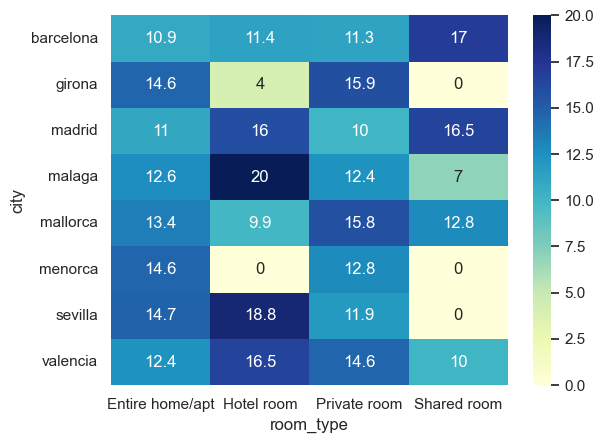

In [14]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_30"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 60 days

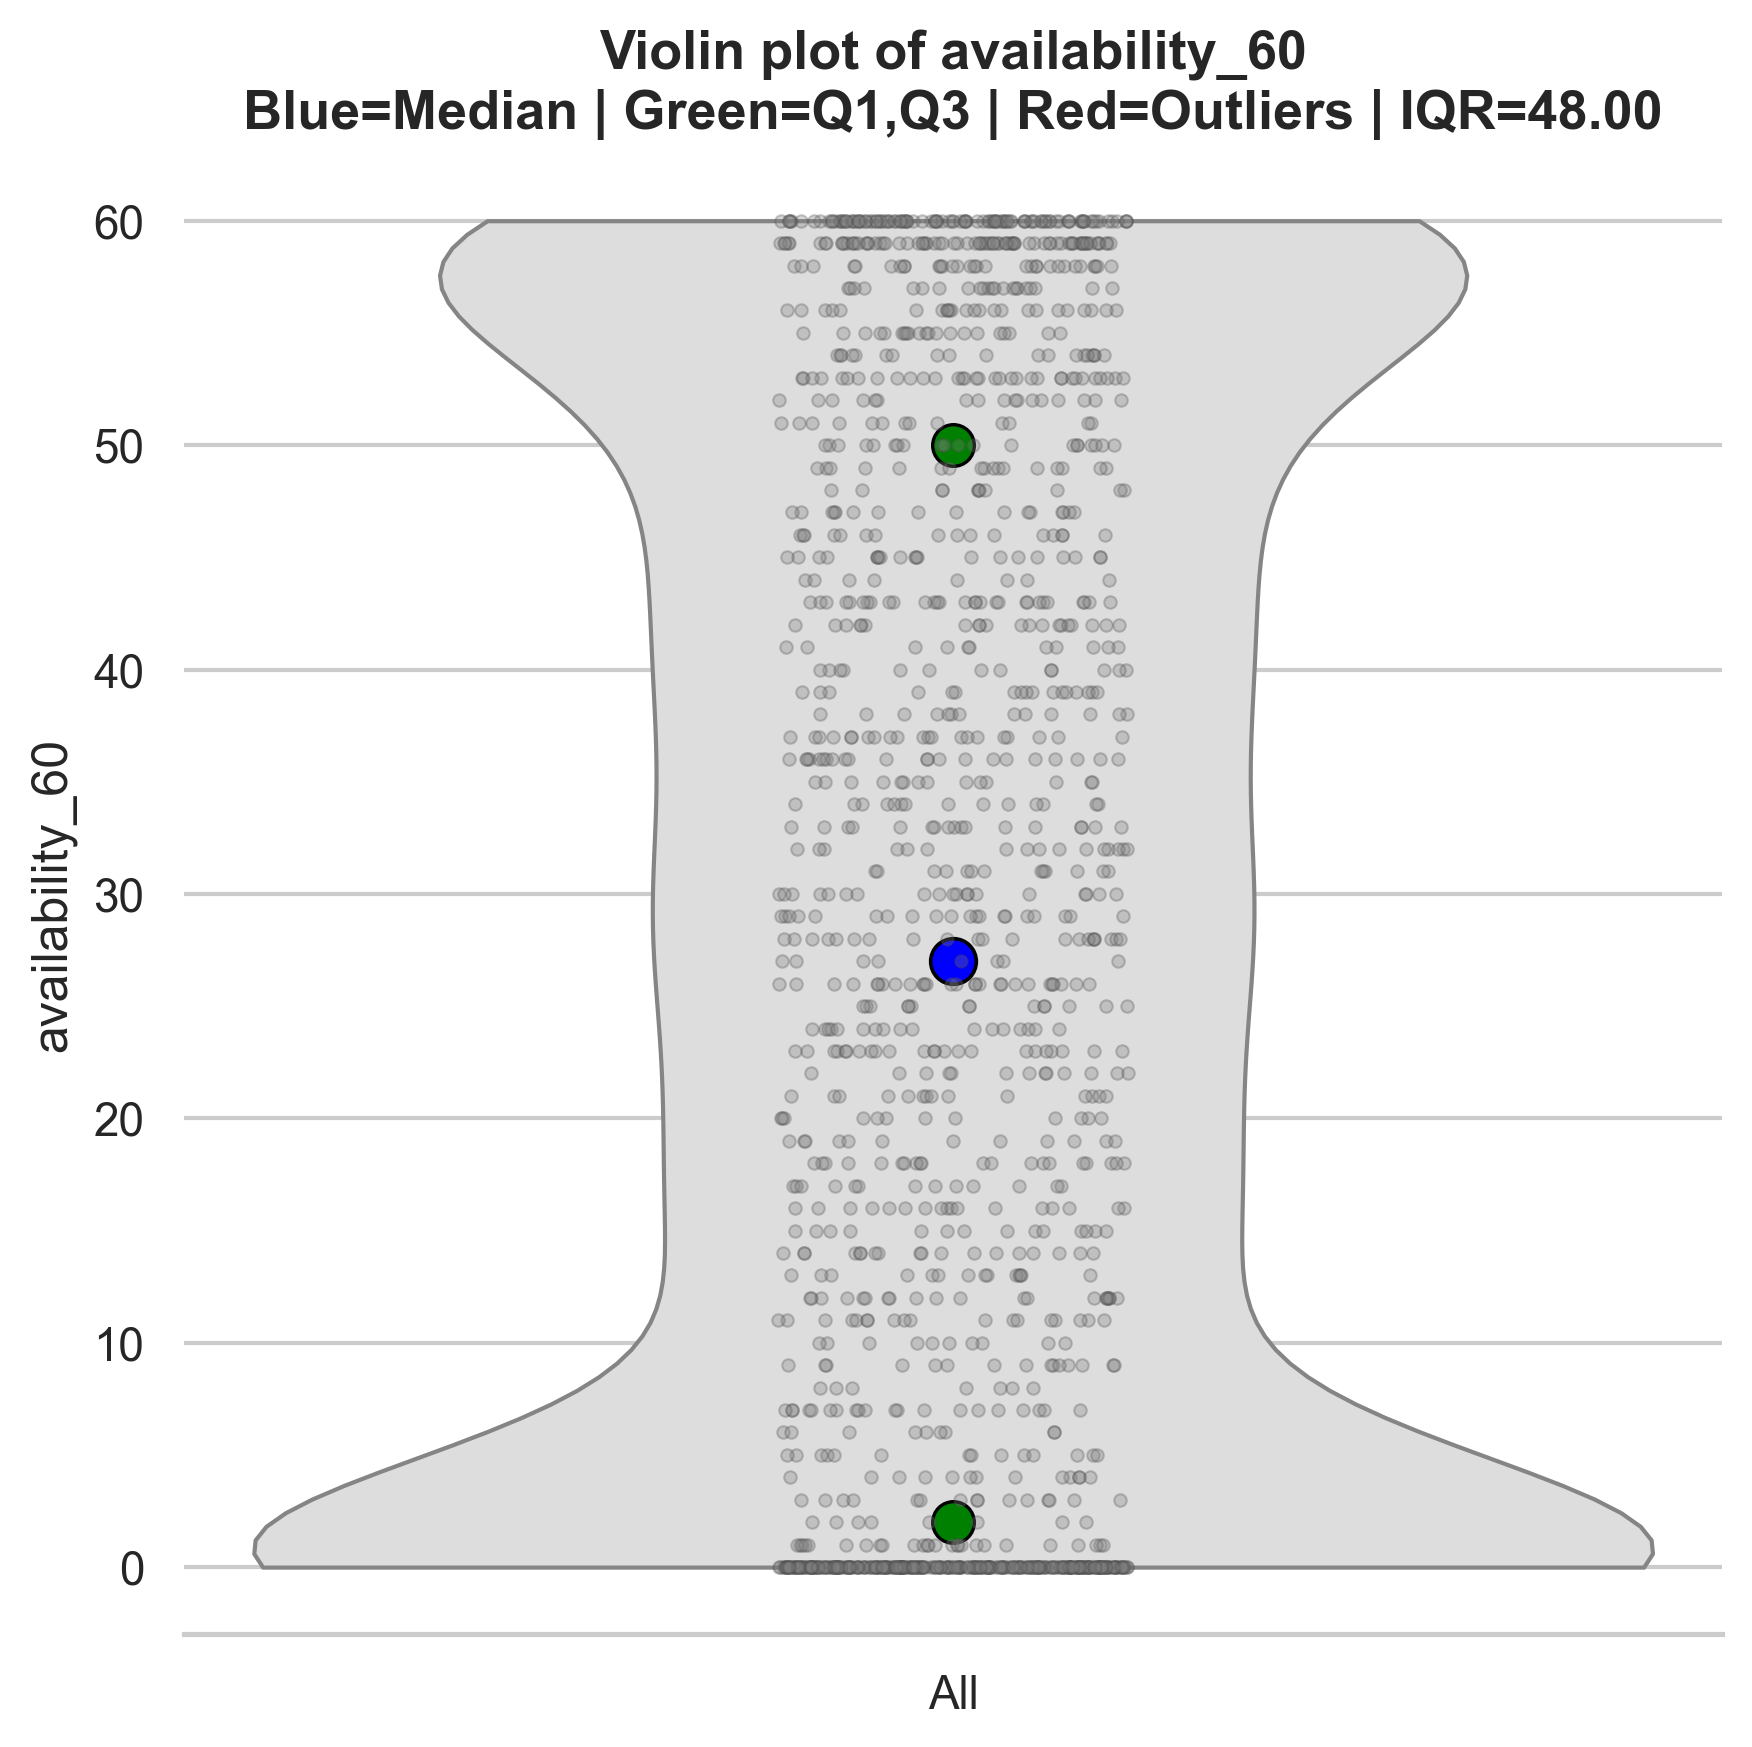

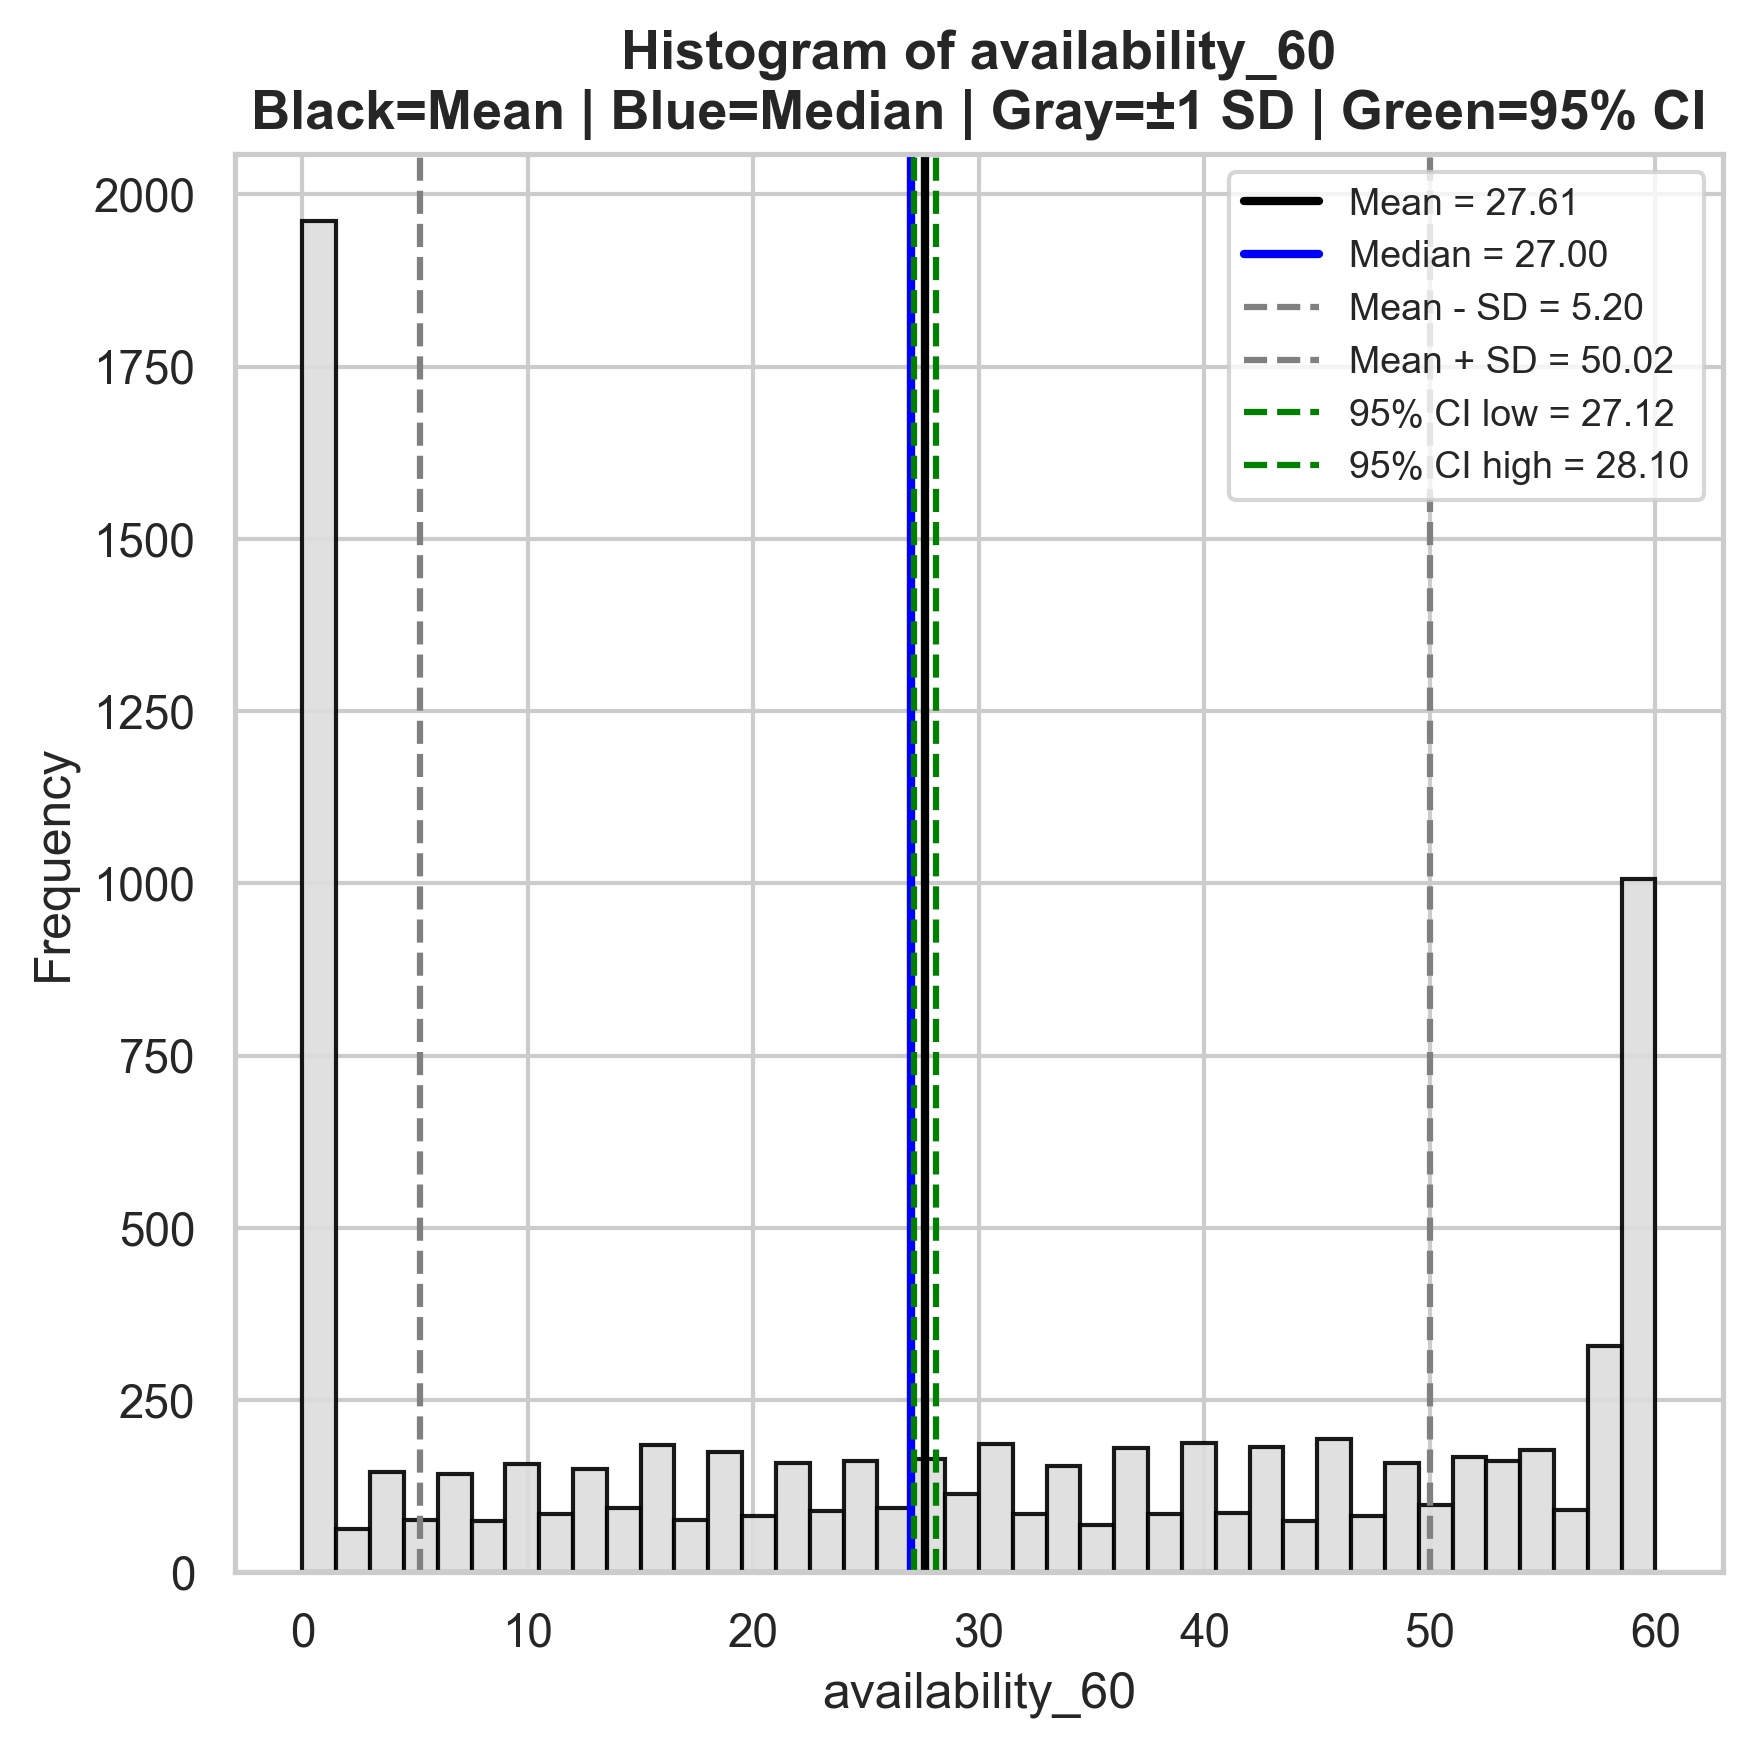

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_60,8000,27.60675,27.0,22.408266,27.115642,28.097858,2.0,50.0,48.0,-70.0,122.0,0,0.098703,Approximately symmetric.



Unique values table
Number of non-nulls: 8000
Number of unique values: 61


,column,value,count,frequency_non_null
0,availability_60,0,1840,0.230000
1,availability_60,1,121,0.015125
2,availability_60,2,63,0.007875
3,availability_60,3,71,0.008875
4,availability_60,4,75,0.009375
...,...,...,...,...
56,availability_60,56,91,0.011375
57,availability_60,57,129,0.016125
58,availability_60,58,200,0.025000
59,availability_60,59,376,0.047000



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_60,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_60,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_60,numeric,city,categorical,Chi-square,176.070095,1.720672e-26,Significant,Statistically significant at p < 0.05.,
3,availability_60,numeric,room_type,categorical,Chi-square,112.420070,4.724881e-20,Significant,Statistically significant at p < 0.05.,
4,availability_60,numeric,accommodates,numeric,Pearson,0.066741,2.297667e-09,Significant,Statistically significant at p < 0.05.,
5,availability_60,numeric,bathrooms,numeric,Pearson,0.034970,1.809144e-03,Significant,Statistically significant at p < 0.05.,
6,availability_60,numeric,bedrooms,numeric,Pearson,0.041271,2.301688e-04,Significant,Statistically significant at p < 0.05.,
7,availability_60,numeric,beds,numeric,Pearson,0.062551,2.186227e-08,Significant,Statistically significant at p < 0.05.,
8,availability_60,numeric,price,numeric,Pearson,0.085322,3.969524e-14,Significant,Statistically significant at p < 0.05.,
9,availability_60,numeric,minimum_nights,numeric,Pearson,-0.014953,1.811358e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,0.098703,Approximately symmetric.,Baseline.
1,Log Transformation,-0.782165,Moderately skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.448750,Approximately symmetric.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.383168,Approximately symmetric.,Did not improve normality; skewness increased....


In [25]:
analysis = analyze_single_field(
    df, target_col="availability_60", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 60*:
- mediana: 27.0
- IQR=48.0 [2.0; 50.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 60), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 23,0 % of values; 
    * Max=[59; 60] - 12,6% of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_30 (r=0.93) and availability_90 (r=0.96)
    * medium and significantly correlated with: availability_365 (r=0.59)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

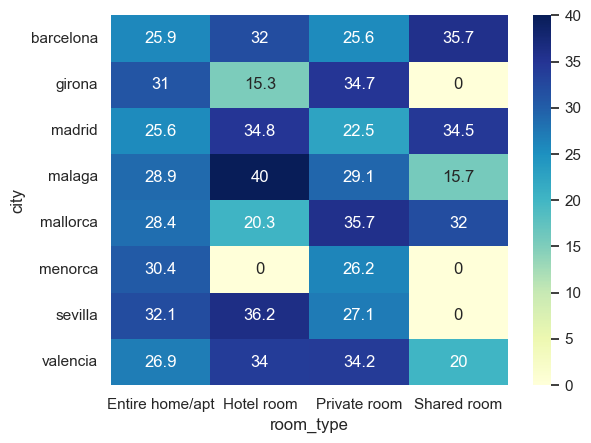

In [17]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_60"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 90 days

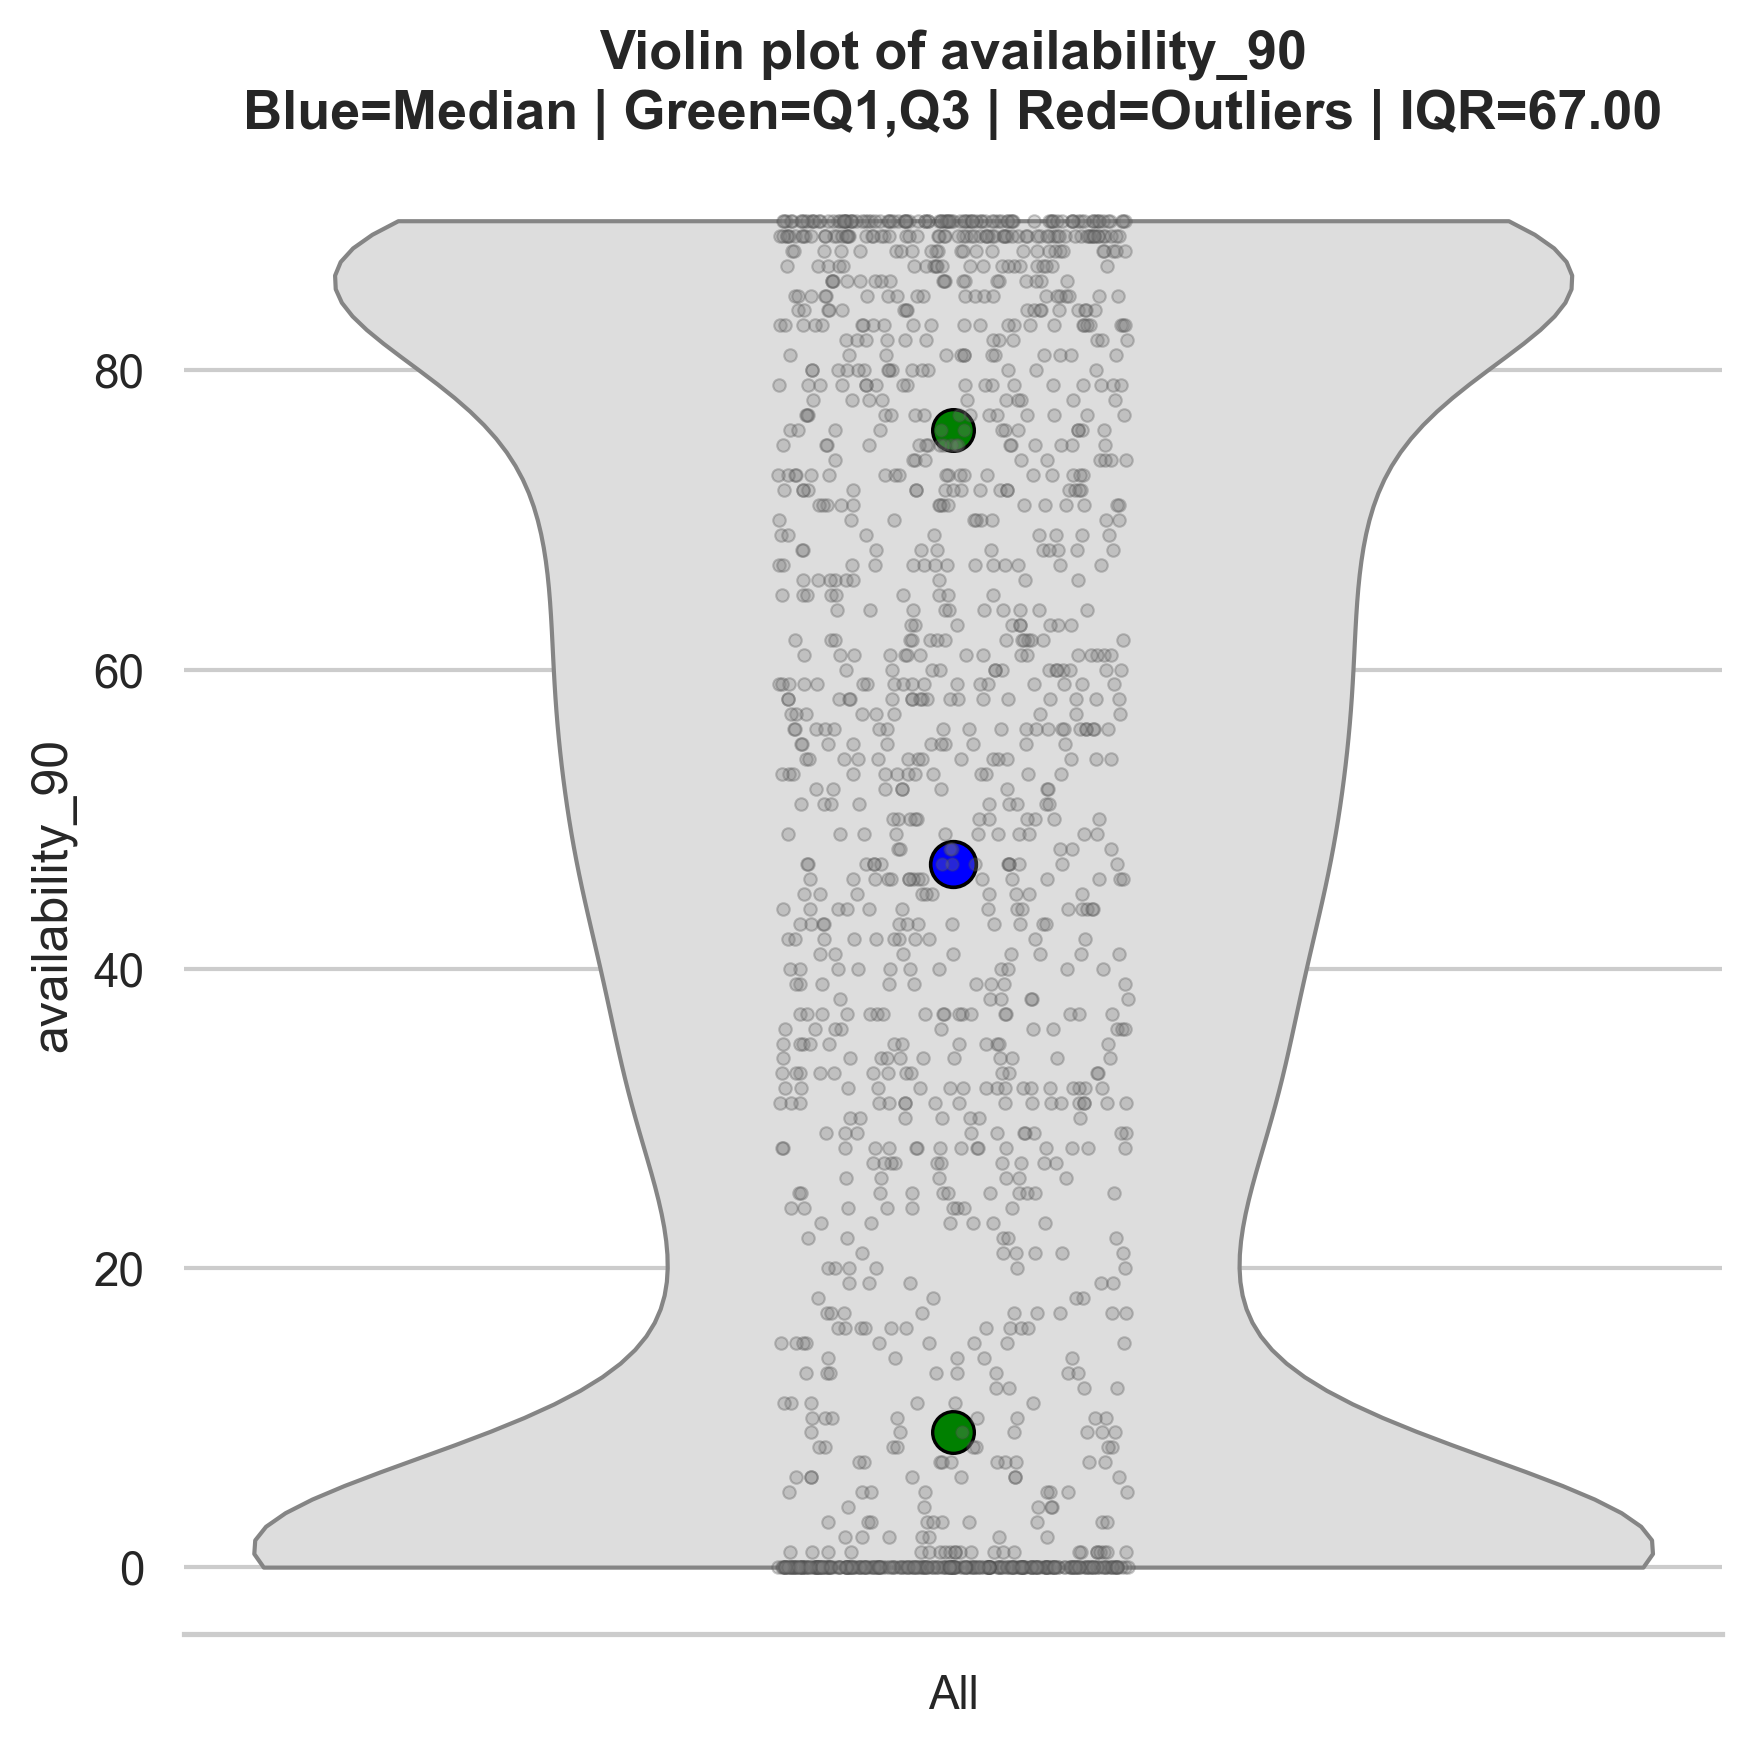

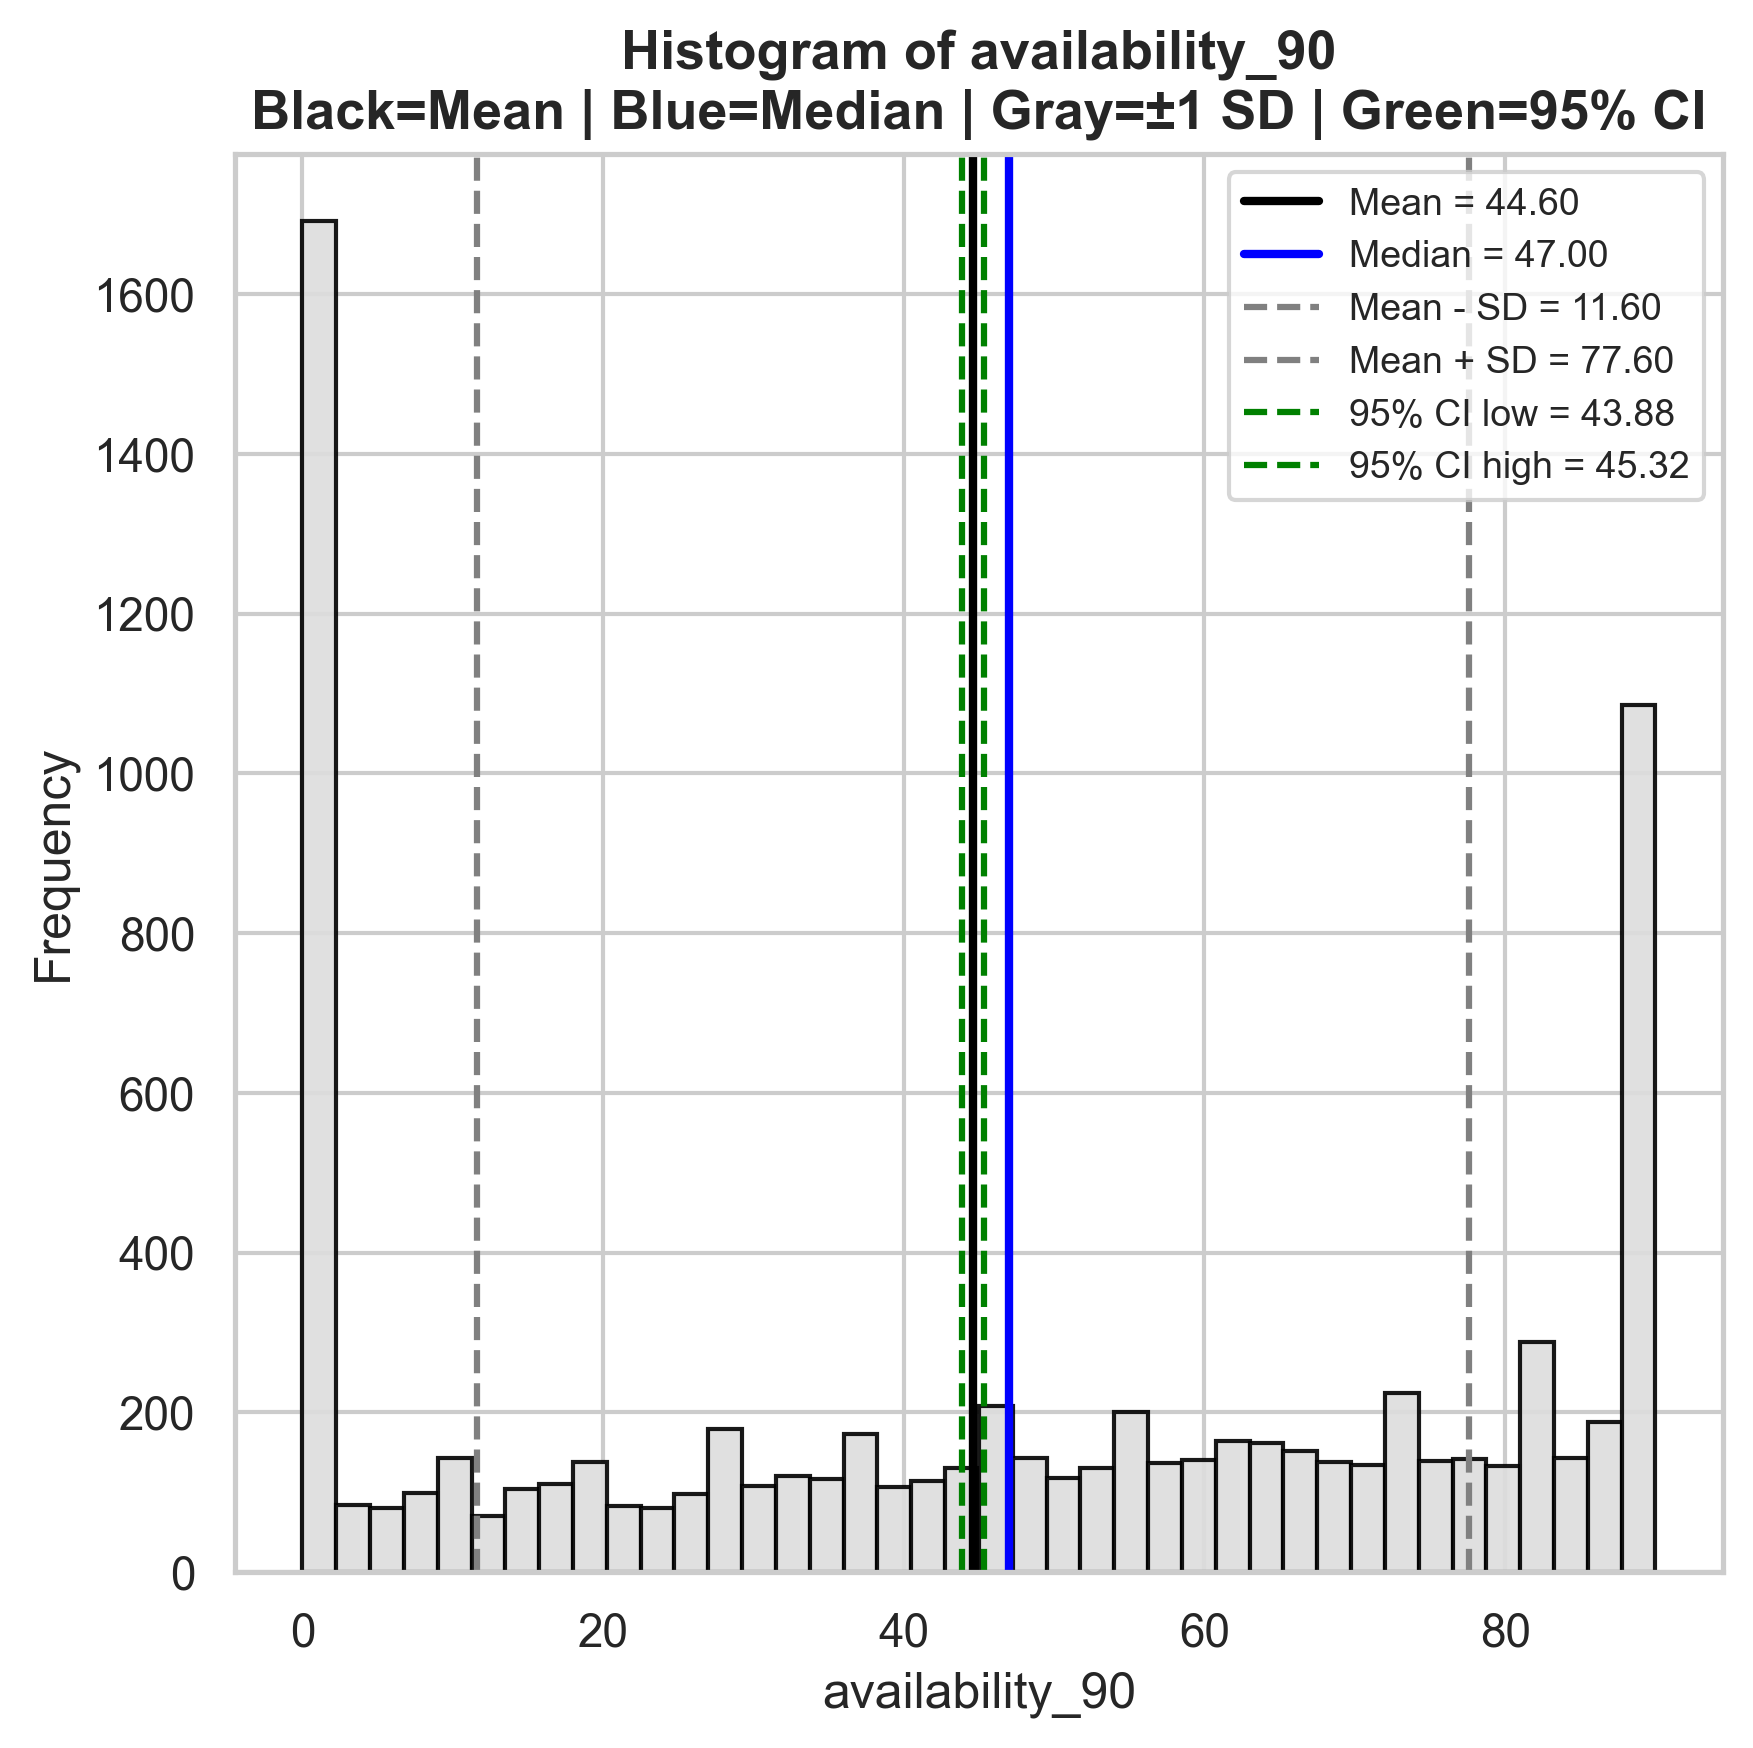

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_90,8000,44.5995,47.0,32.996787,43.87633,45.32267,9.0,76.0,67.0,-91.5,176.5,0,-0.070016,Approximately symmetric.



Unique values table
Number of non-nulls: 8000
Number of unique values: 91


,column,value,count,frequency_non_null
0,availability_90,0,1551,0.193875
1,availability_90,1,94,0.011750
2,availability_90,2,46,0.005750
3,availability_90,3,50,0.006250
4,availability_90,4,34,0.004250
...,...,...,...,...
86,availability_90,86,84,0.010500
87,availability_90,87,104,0.013000
88,availability_90,88,171,0.021375
89,availability_90,89,338,0.042250



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_90,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_90,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_90,numeric,city,categorical,Chi-square,207.469882,2.622497e-29,Significant,Statistically significant at p < 0.05.,
3,availability_90,numeric,room_type,categorical,Chi-square,209.703148,3.222851e-38,Significant,Statistically significant at p < 0.05.,
4,availability_90,numeric,accommodates,numeric,Pearson,0.052219,2.967415e-06,Significant,Statistically significant at p < 0.05.,
5,availability_90,numeric,bathrooms,numeric,Pearson,0.017245,1.240138e-01,Not significant,Not statistically significant at p < 0.05.,
6,availability_90,numeric,bedrooms,numeric,Pearson,0.021881,5.090644e-02,Not significant,Not statistically significant at p < 0.05.,
7,availability_90,numeric,beds,numeric,Pearson,0.043629,9.557283e-05,Significant,Statistically significant at p < 0.05.,
8,availability_90,numeric,price,numeric,Pearson,0.075949,1.711559e-11,Significant,Statistically significant at p < 0.05.,
9,availability_90,numeric,minimum_nights,numeric,Pearson,-0.012490,2.640065e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.070016,Approximately symmetric.,Baseline.
1,Log Transformation,-1.039796,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.635510,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.498615,Approximately symmetric.,Did not improve normality; skewness increased....


In [18]:
analysis = analyze_single_field(
    df, target_col="availability_90", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 90*:
- mediana: 47.0
- IQR=67.0 [9.0; 76.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 90), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 19,4 % of values; 
    * Max=[89; 90] - 11,4% of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: availability_30 (r=0.85) and availability_60 (r=0.96)
    * medium and significantly correlated with: availability_365 (r=0.64)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

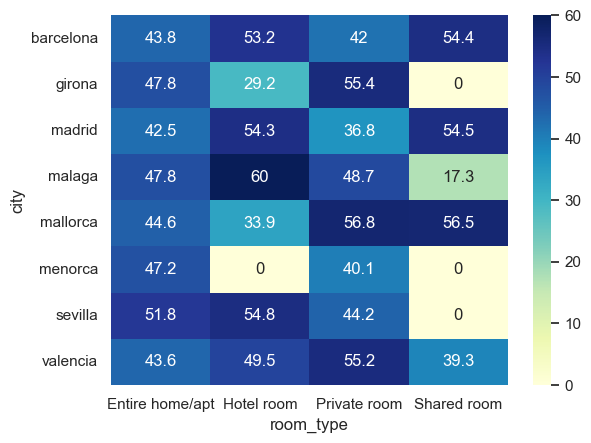

In [19]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_90"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Availability 365 days

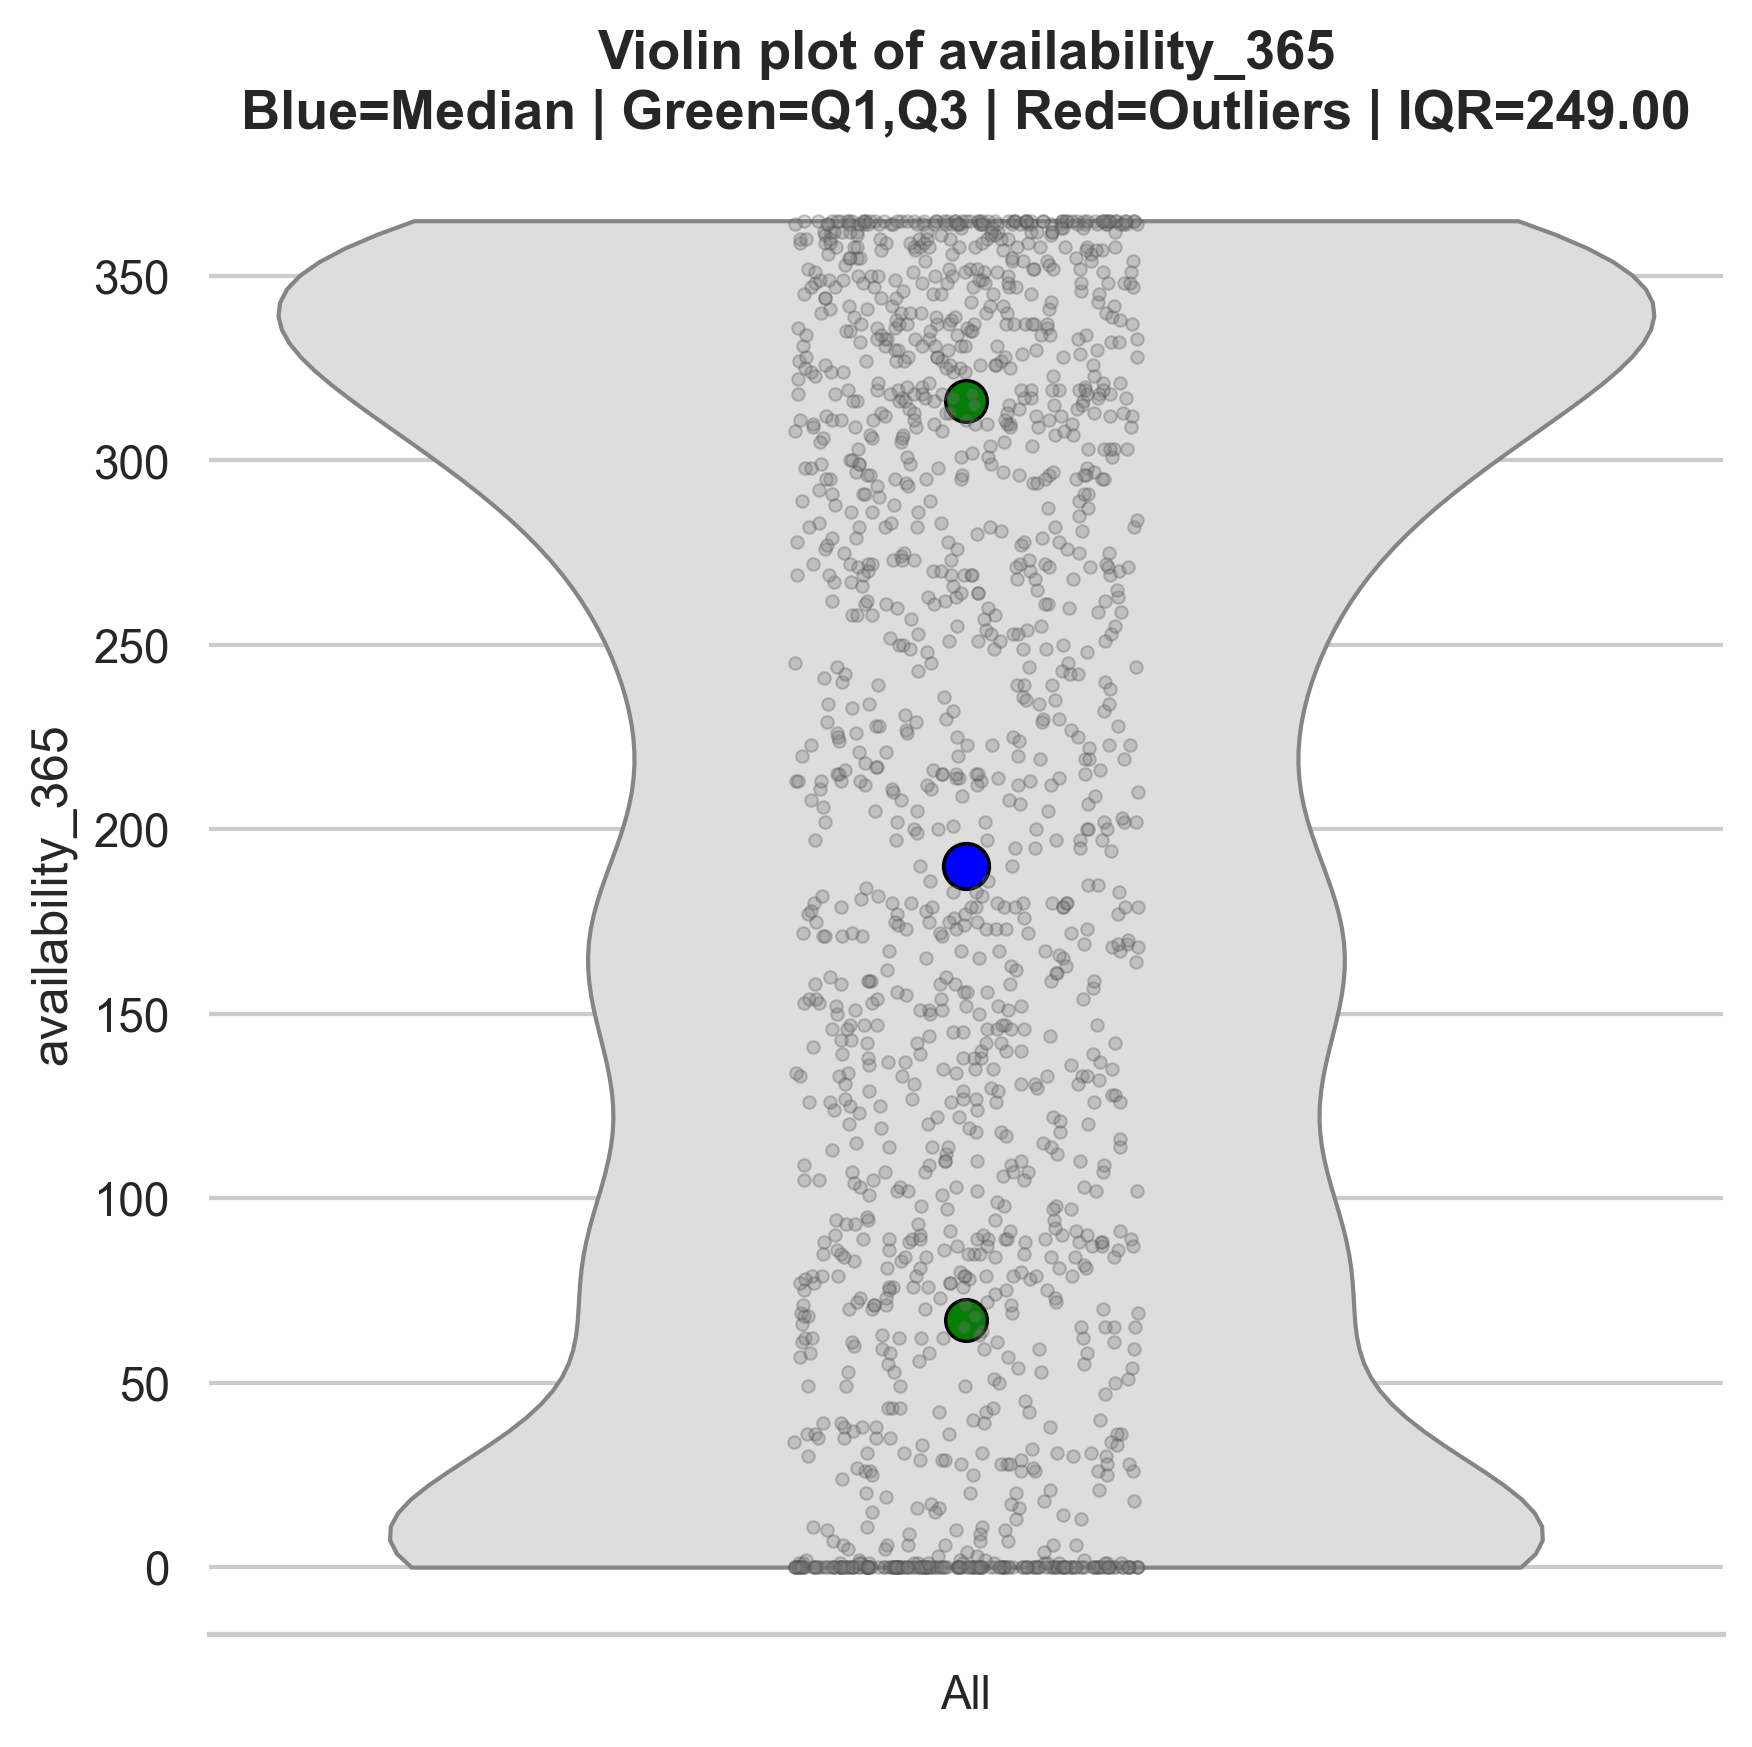

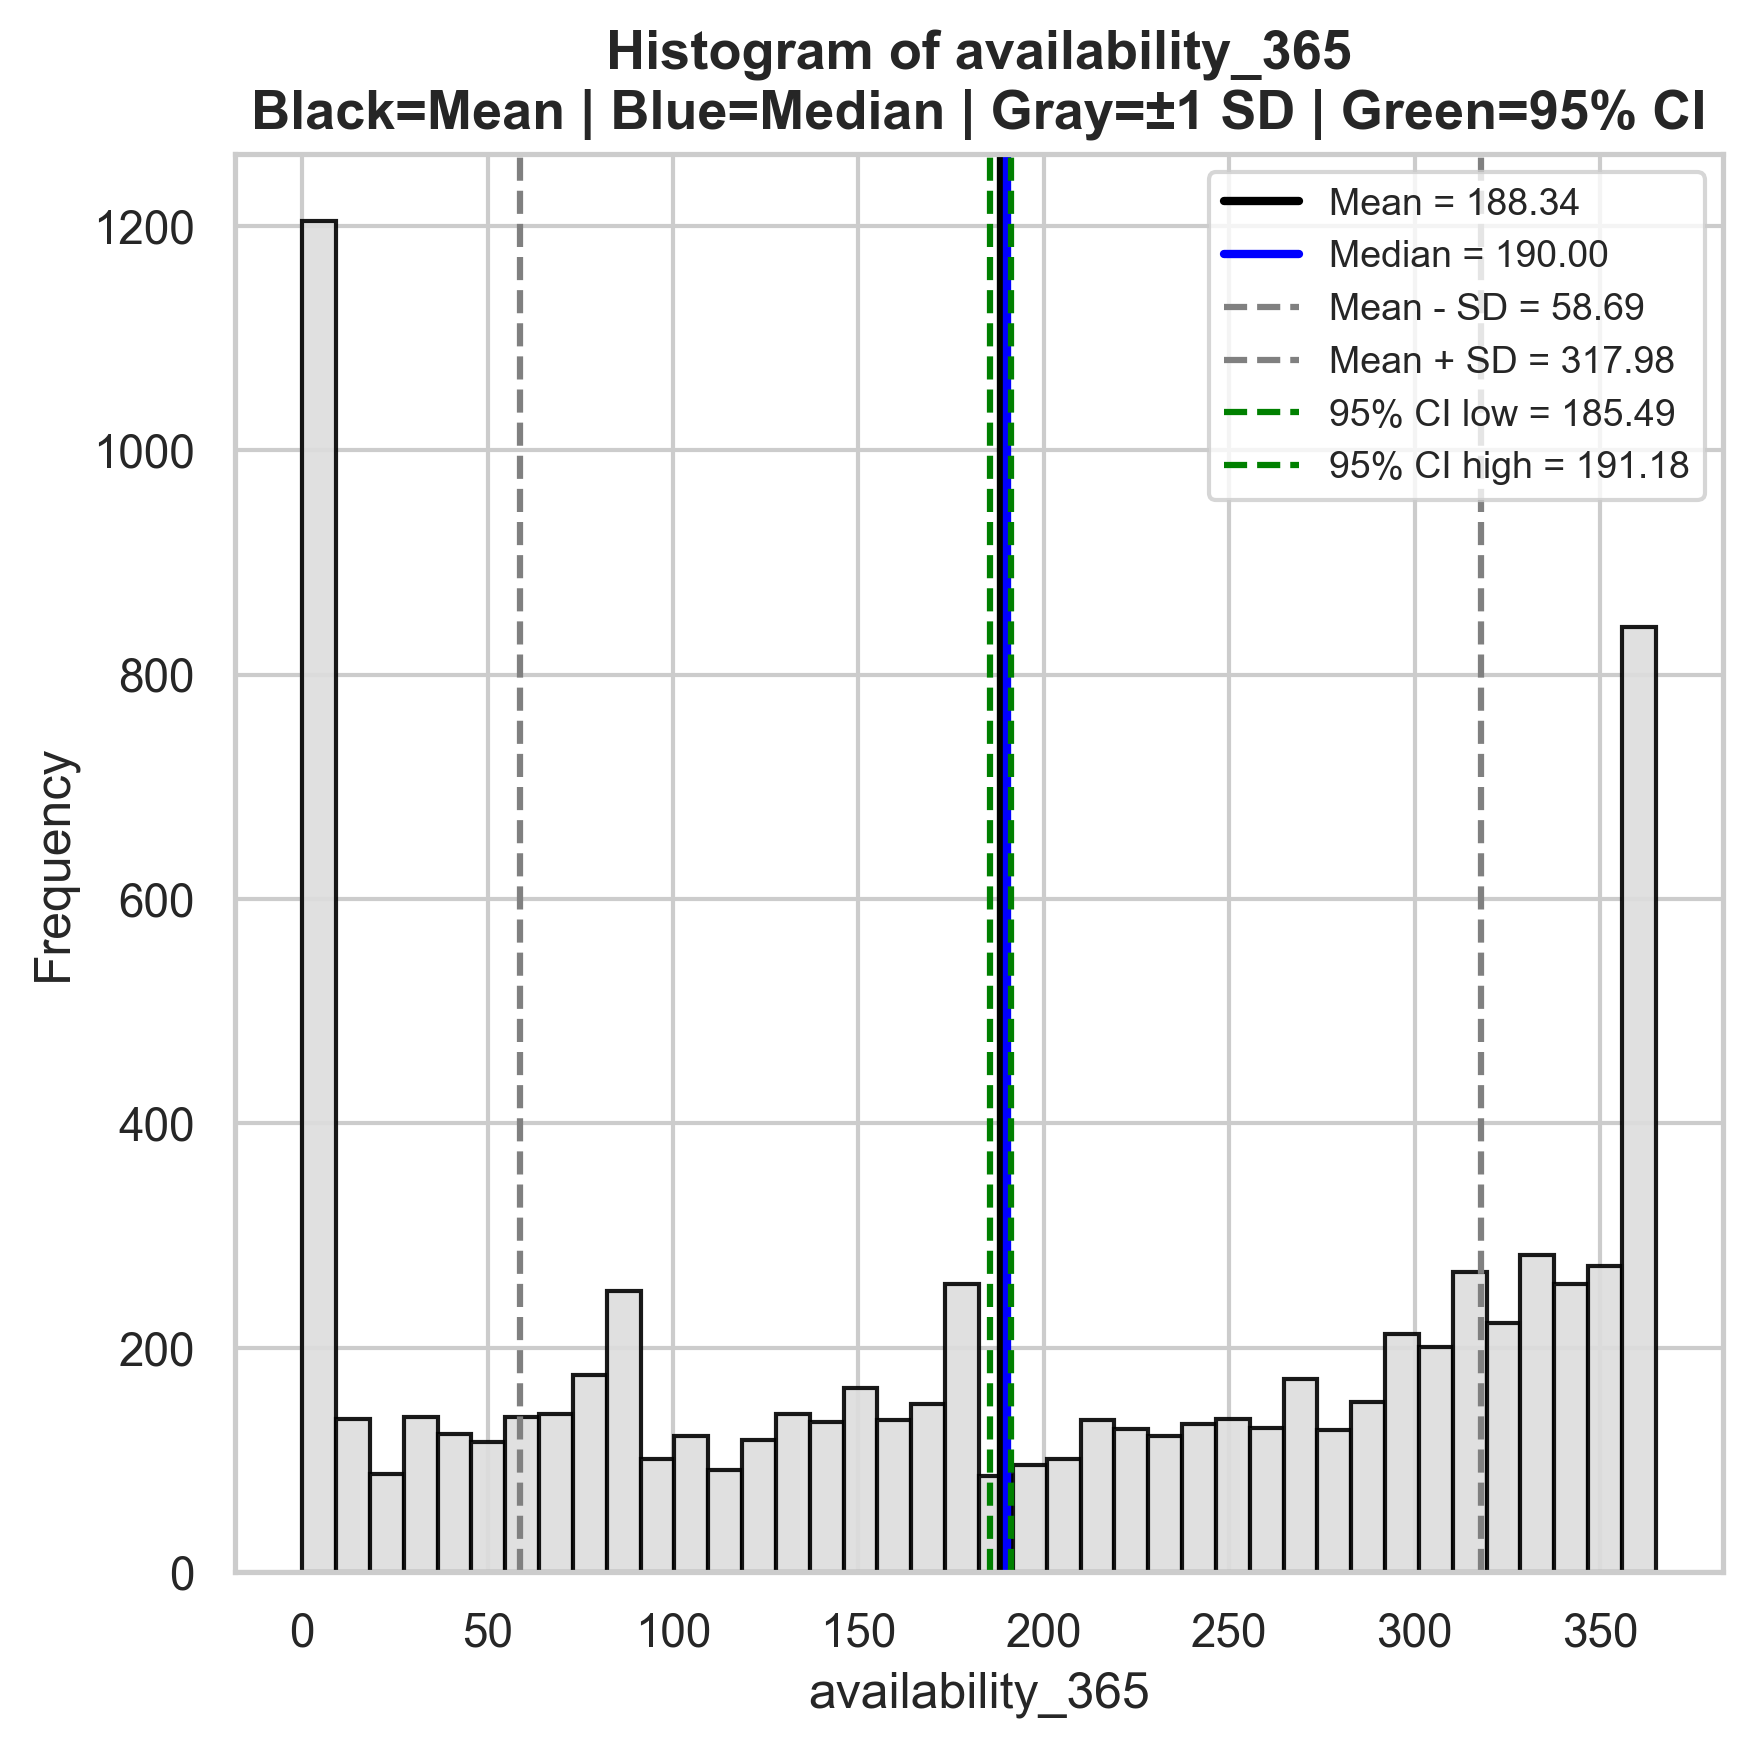

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,availability_365,8000,188.335875,190.0,129.643586,185.494557,191.177193,67.0,316.0,249.0,-306.5,689.5,0,-0.117351,Approximately symmetric.



Unique values table
Number of non-nulls: 8000
Number of unique values: 366


,column,value,count,frequency_non_null
0,availability_365,0,1003,0.125375
1,availability_365,1,62,0.007750
2,availability_365,2,19,0.002375
3,availability_365,3,21,0.002625
4,availability_365,4,9,0.001125
...,...,...,...,...
361,availability_365,361,38,0.004750
362,availability_365,362,58,0.007250
363,availability_365,363,61,0.007625
364,availability_365,364,144,0.018000



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,availability_365,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,availability_365,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,availability_365,numeric,city,categorical,Chi-square,280.259797,1.972052e-43,Significant,Statistically significant at p < 0.05.,
3,availability_365,numeric,room_type,categorical,Chi-square,406.242558,1.802664e-79,Significant,Statistically significant at p < 0.05.,
4,availability_365,numeric,accommodates,numeric,Pearson,0.124843,3.706536e-29,Significant,Statistically significant at p < 0.05.,
5,availability_365,numeric,bathrooms,numeric,Pearson,0.063369,1.536693e-08,Significant,Statistically significant at p < 0.05.,
6,availability_365,numeric,bedrooms,numeric,Pearson,0.093581,5.920264e-17,Significant,Statistically significant at p < 0.05.,
7,availability_365,numeric,beds,numeric,Pearson,0.116208,1.957591e-25,Significant,Statistically significant at p < 0.05.,
8,availability_365,numeric,price,numeric,Pearson,0.138348,9.230459e-35,Significant,Statistically significant at p < 0.05.,
9,availability_365,numeric,minimum_nights,numeric,Pearson,0.029312,8.744475e-03,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-0.117351,Approximately symmetric.,Baseline.
1,Log Transformation,-1.539458,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-0.739558,Moderately skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.588784,Moderately skewed.,Did not improve normality; skewness increased....


In [21]:
analysis = analyze_single_field(
    df, target_col="availability_365", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Availability 365*:
- mediana: 190.0
- IQR=249.0 [67.0; 316.0]
- no outliers determined
- Even though Skewness demonstrates symmetric distribution with two modas (0 and 365), Kurtuosis must be checked due to Min and Max values accumulation:
    * Min=0 - 12,5 % of values; 
    * Max=[364; 365] - 5,9% of values
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none
    * medium and significantly correlated with: availability_30	(r=0.51), availability_60 (r=0.59), availability_90 (r=0.64)
    * weakly and significantly correlated with: accommodates (r=0.12), beds (r=0.12), price (r=0.14)
    * absence of correlation with: all other parameters
- Non-parametric tests for association should be applied

<Axes: xlabel='room_type', ylabel='city'>

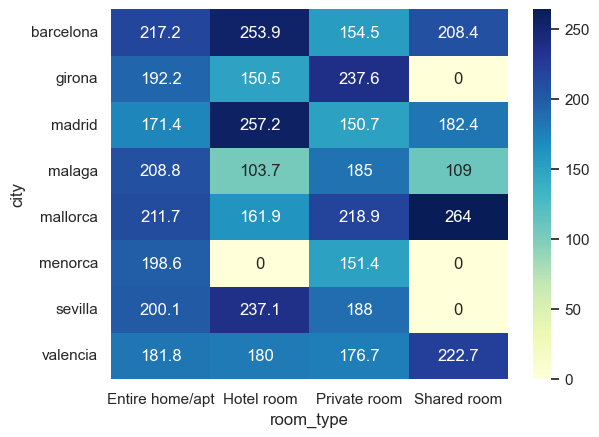

In [23]:
sns.heatmap(
    df.groupby(["city", "room_type"])["availability_365"]
    .mean()
    .round(1)
    .unstack(fill_value=0),
    annot=True,
    cmap="YlGnBu",
    fmt="g",
)

##### Number of reviews

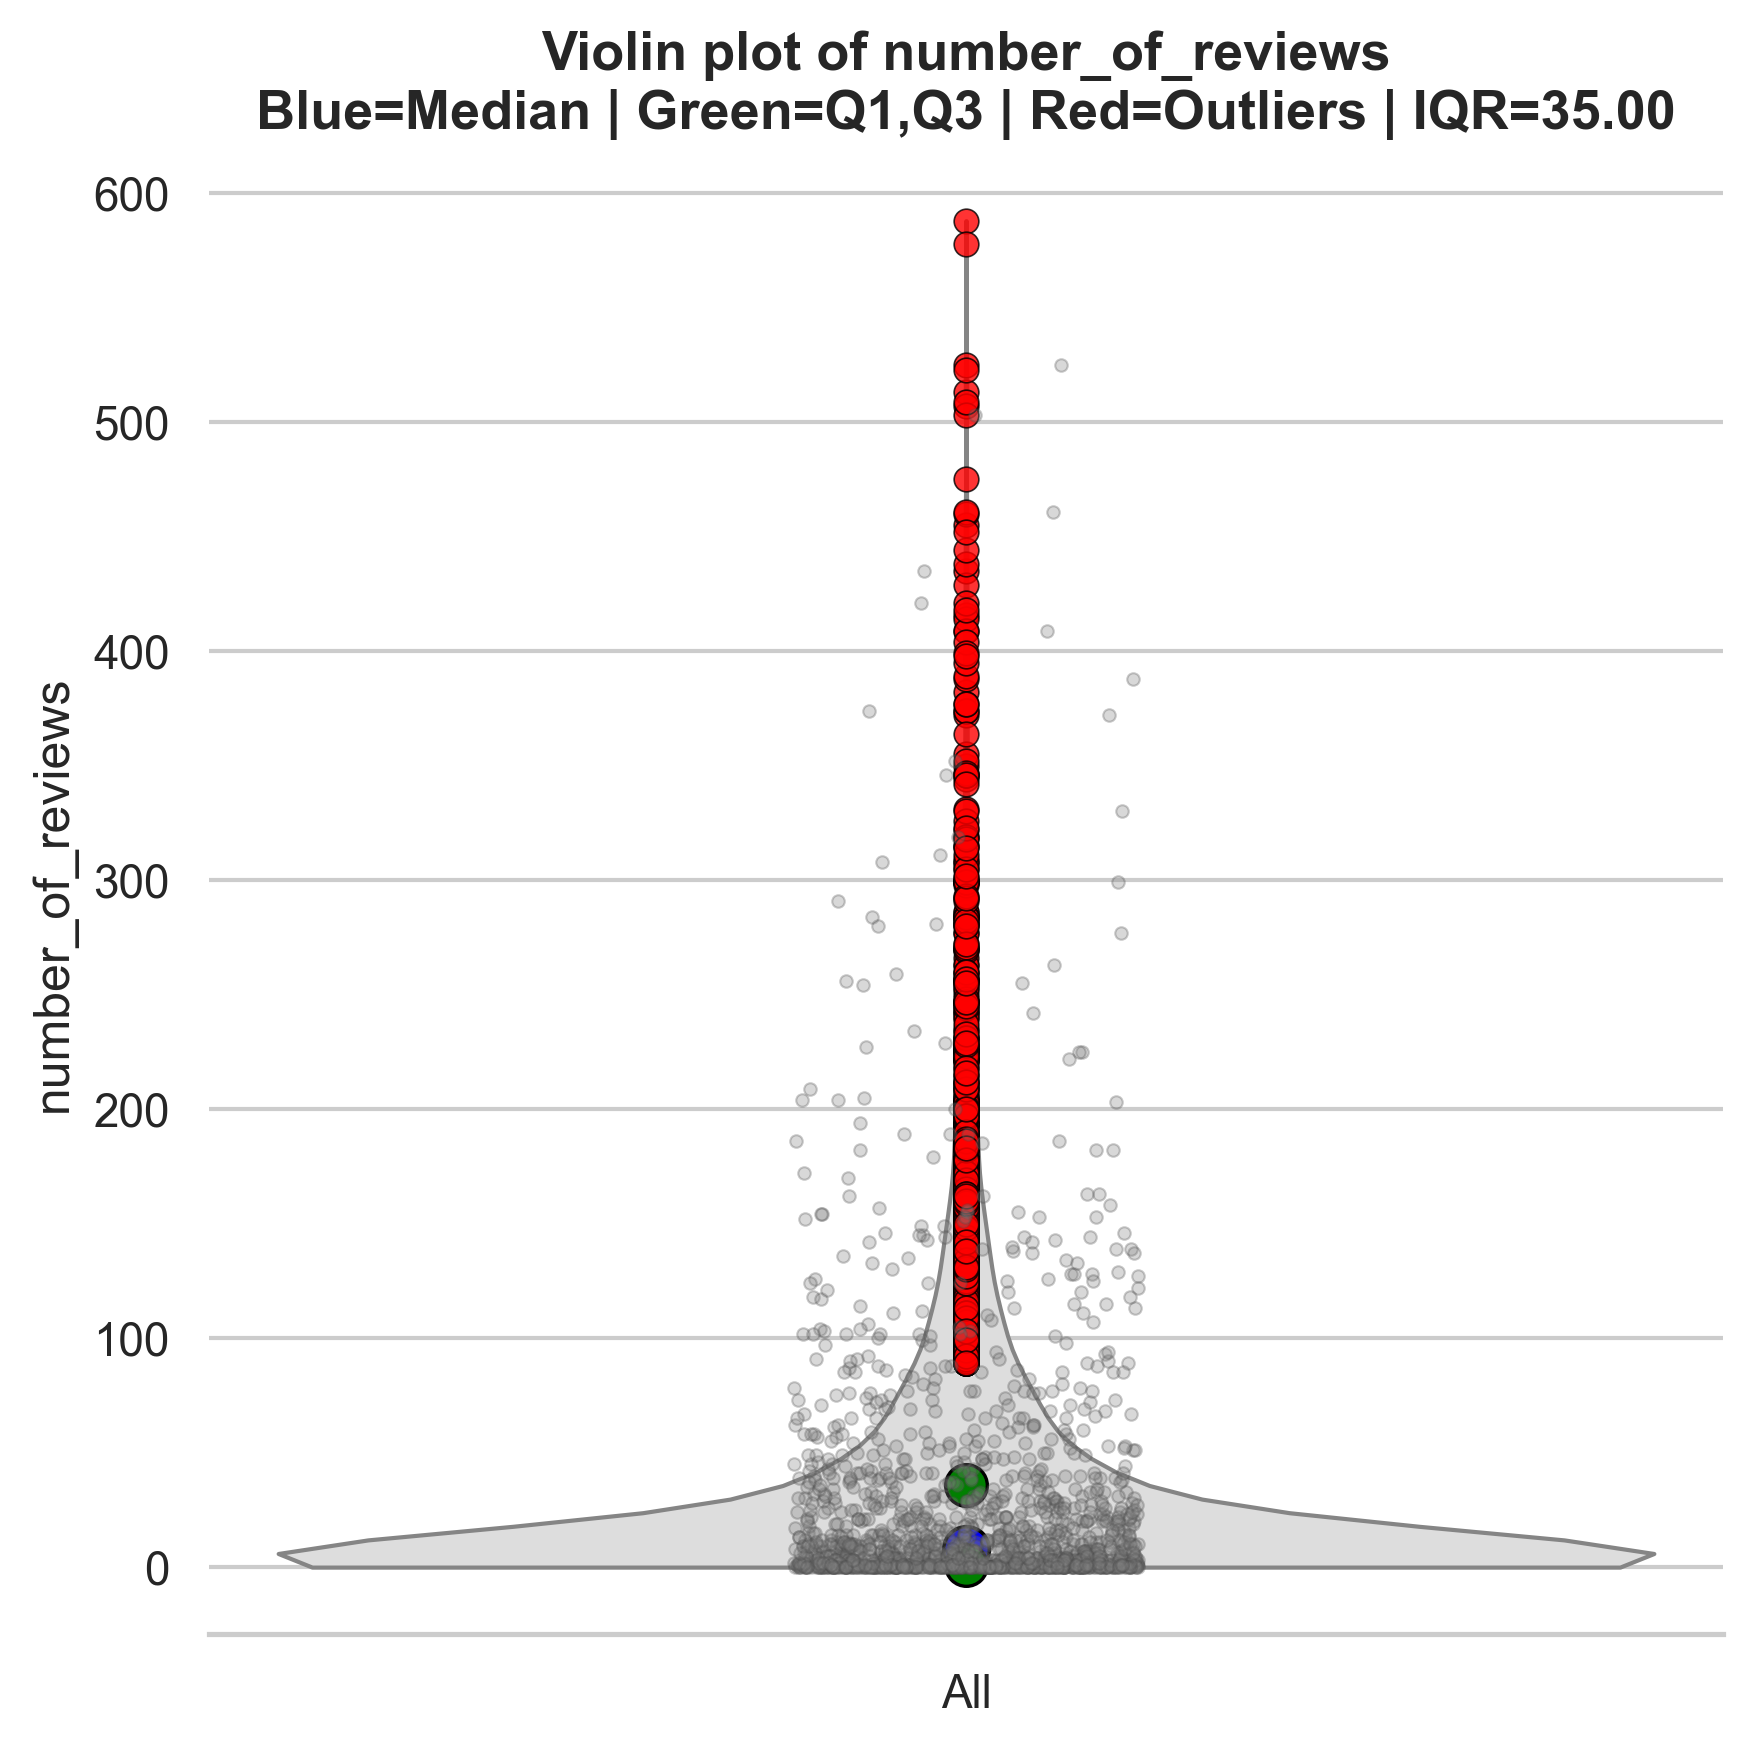

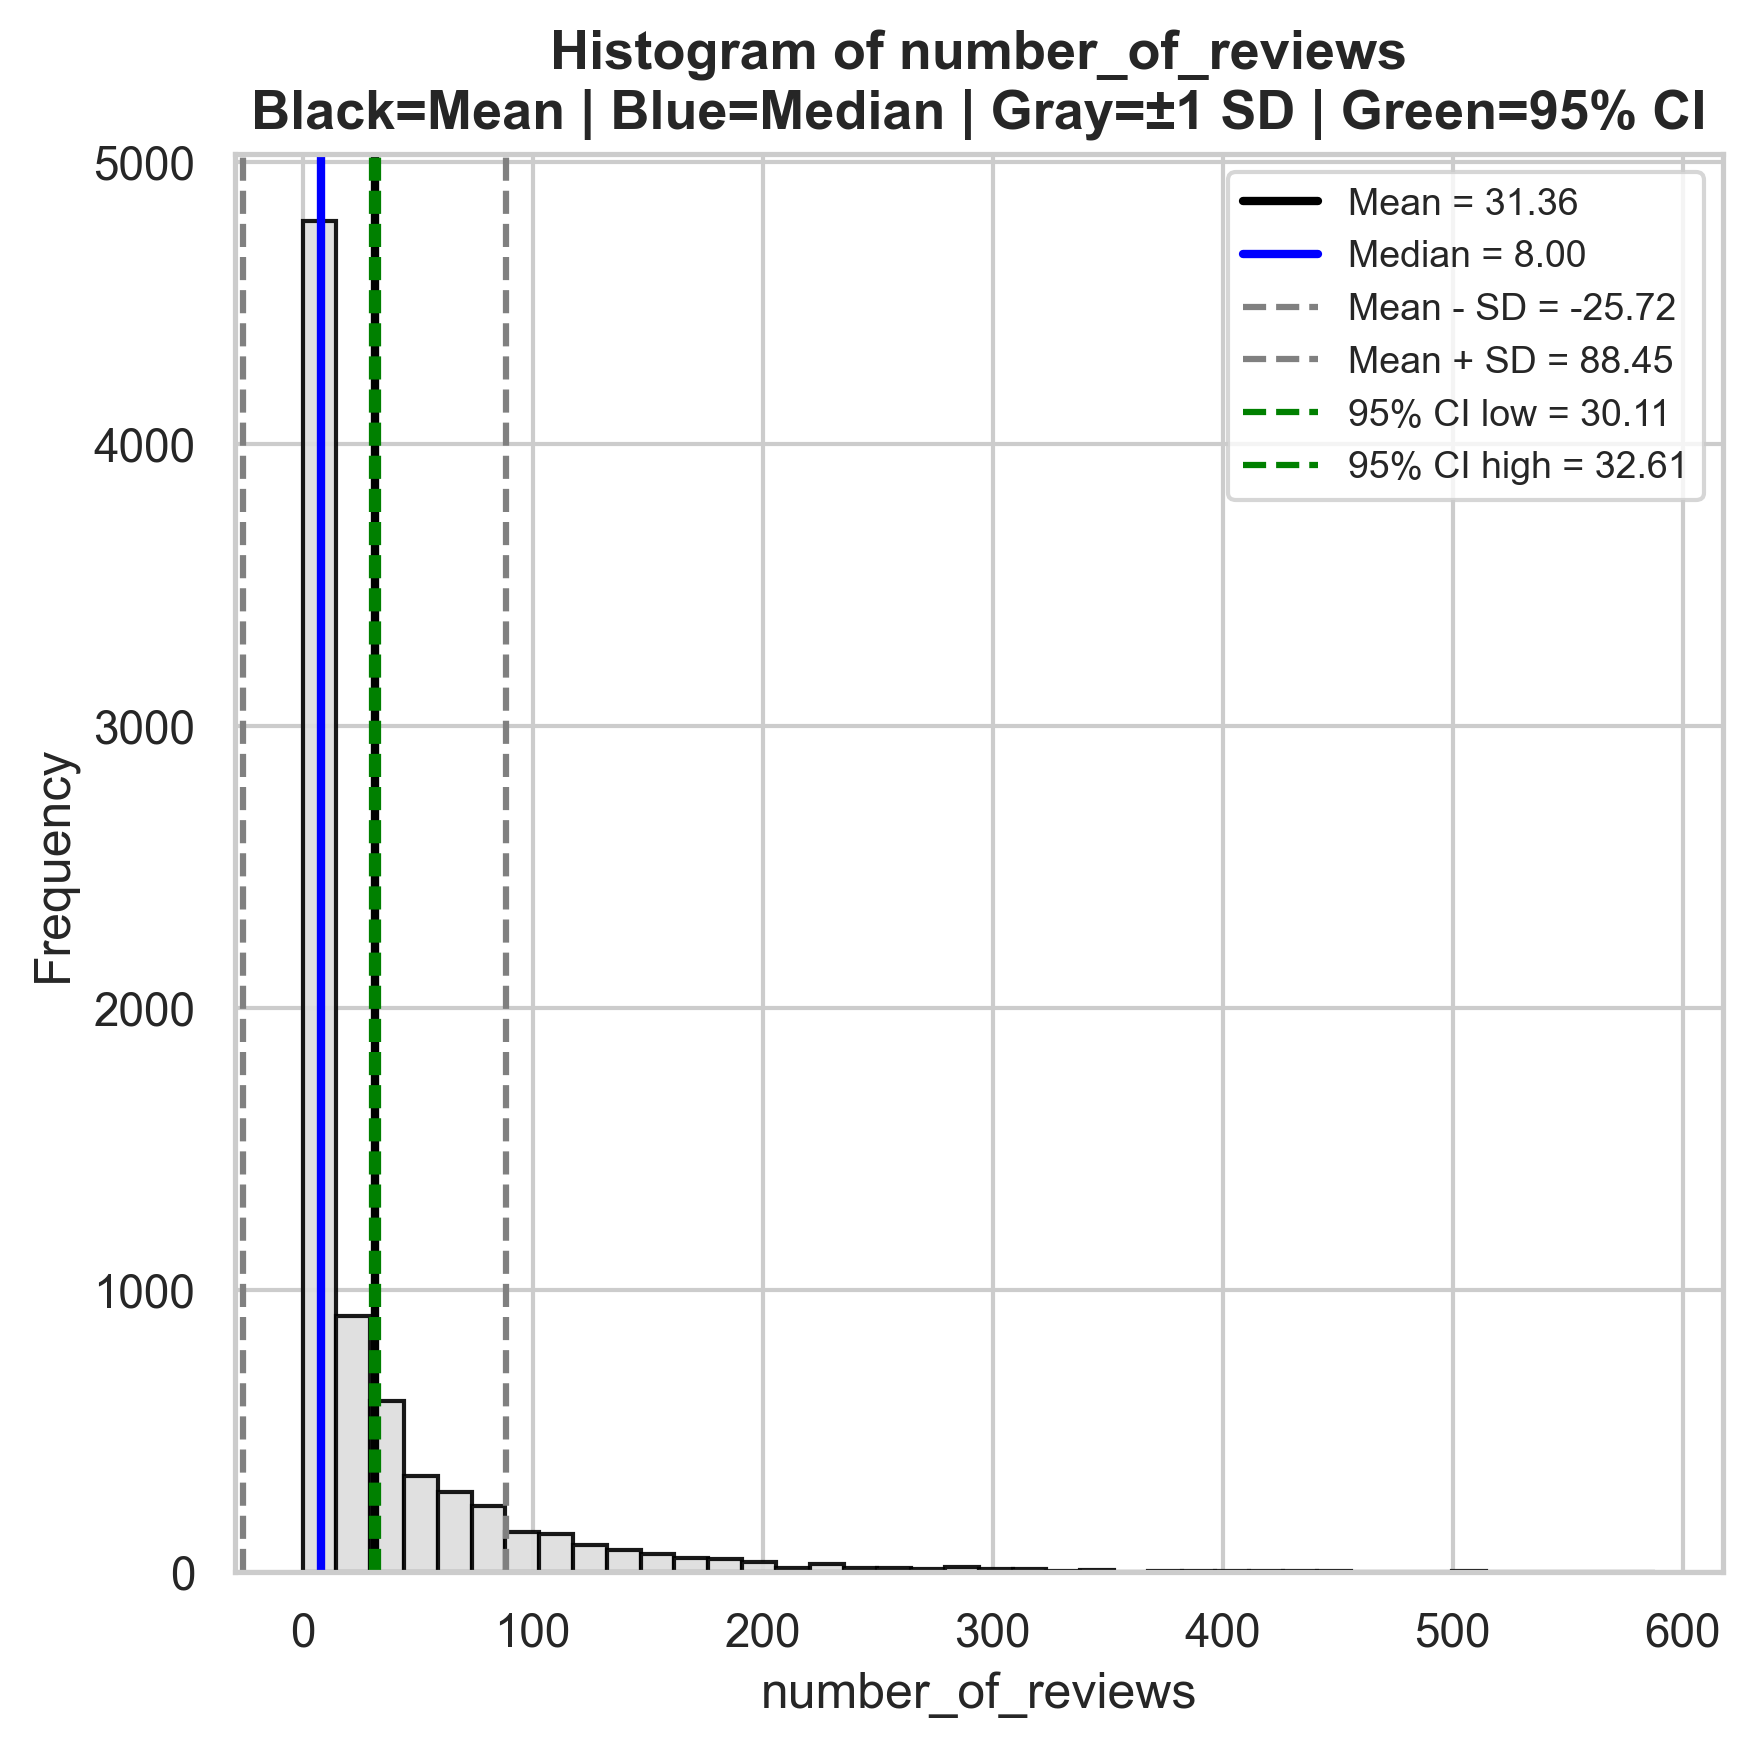

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,number_of_reviews,8000,31.36175,8.0,57.083552,30.110685,32.612815,1.0,36.0,35.0,-51.5,88.5,827,3.556479,Highly skewed.



Unique values table
Number of non-nulls: 8000
Number of unique values: 319


,column,value,count,frequency_non_null
0,number_of_reviews,0,1611,0.201375
1,number_of_reviews,1,704,0.088000
2,number_of_reviews,2,448,0.056000
3,number_of_reviews,3,358,0.044750
4,number_of_reviews,4,276,0.034500
...,...,...,...,...
314,number_of_reviews,513,1,0.000125
315,number_of_reviews,523,1,0.000125
316,number_of_reviews,525,1,0.000125
317,number_of_reviews,578,1,0.000125



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,number_of_reviews,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,number_of_reviews,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,number_of_reviews,numeric,city,categorical,Chi-square,895.278570,5.388953e-176,Significant,Statistically significant at p < 0.05.,
3,number_of_reviews,numeric,room_type,categorical,Chi-square,38.914989,1.193435e-05,Significant,Statistically significant at p < 0.05.,
4,number_of_reviews,numeric,accommodates,numeric,Pearson,-0.117694,4.473621e-26,Significant,Statistically significant at p < 0.05.,
5,number_of_reviews,numeric,bathrooms,numeric,Pearson,-0.131081,7.805608e-32,Significant,Statistically significant at p < 0.05.,
6,number_of_reviews,numeric,bedrooms,numeric,Pearson,-0.149275,6.734105e-41,Significant,Statistically significant at p < 0.05.,
7,number_of_reviews,numeric,beds,numeric,Pearson,-0.137395,5.552910e-35,Significant,Statistically significant at p < 0.05.,
8,number_of_reviews,numeric,price,numeric,Pearson,-0.154612,4.376614e-43,Significant,Statistically significant at p < 0.05.,
9,number_of_reviews,numeric,minimum_nights,numeric,Pearson,-0.077724,3.371938e-12,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,3.556479,Highly skewed.,Baseline.
1,Log Transformation,0.190095,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,1.349079,Highly skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,0.047242,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [26]:
analysis = analyze_single_field(
    df, target_col="number_of_reviews", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Numer of reviews*:
- mediana: 8.0
- IQR=35.0 [1.0; 36.0]
- 827 outliers determined
- apply Box-Cox Transformation to obtain normal distribution of the data
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: reviews_per_month (r=0.66)
    * weakly and significantly correlated with: accommodates (r= -0.12), bathrooms (r= -0.13), bedrooms (r= -0.15), beds (r= -0.14), price (r= -0.15), review_scores_accuracy (r=0.12), review_scores_checkin (r=0.12), review_scores_communication (r=0.11), review_scores_location (r=0.13), review_scores_value (r=0.11)

##### Reviews score rating

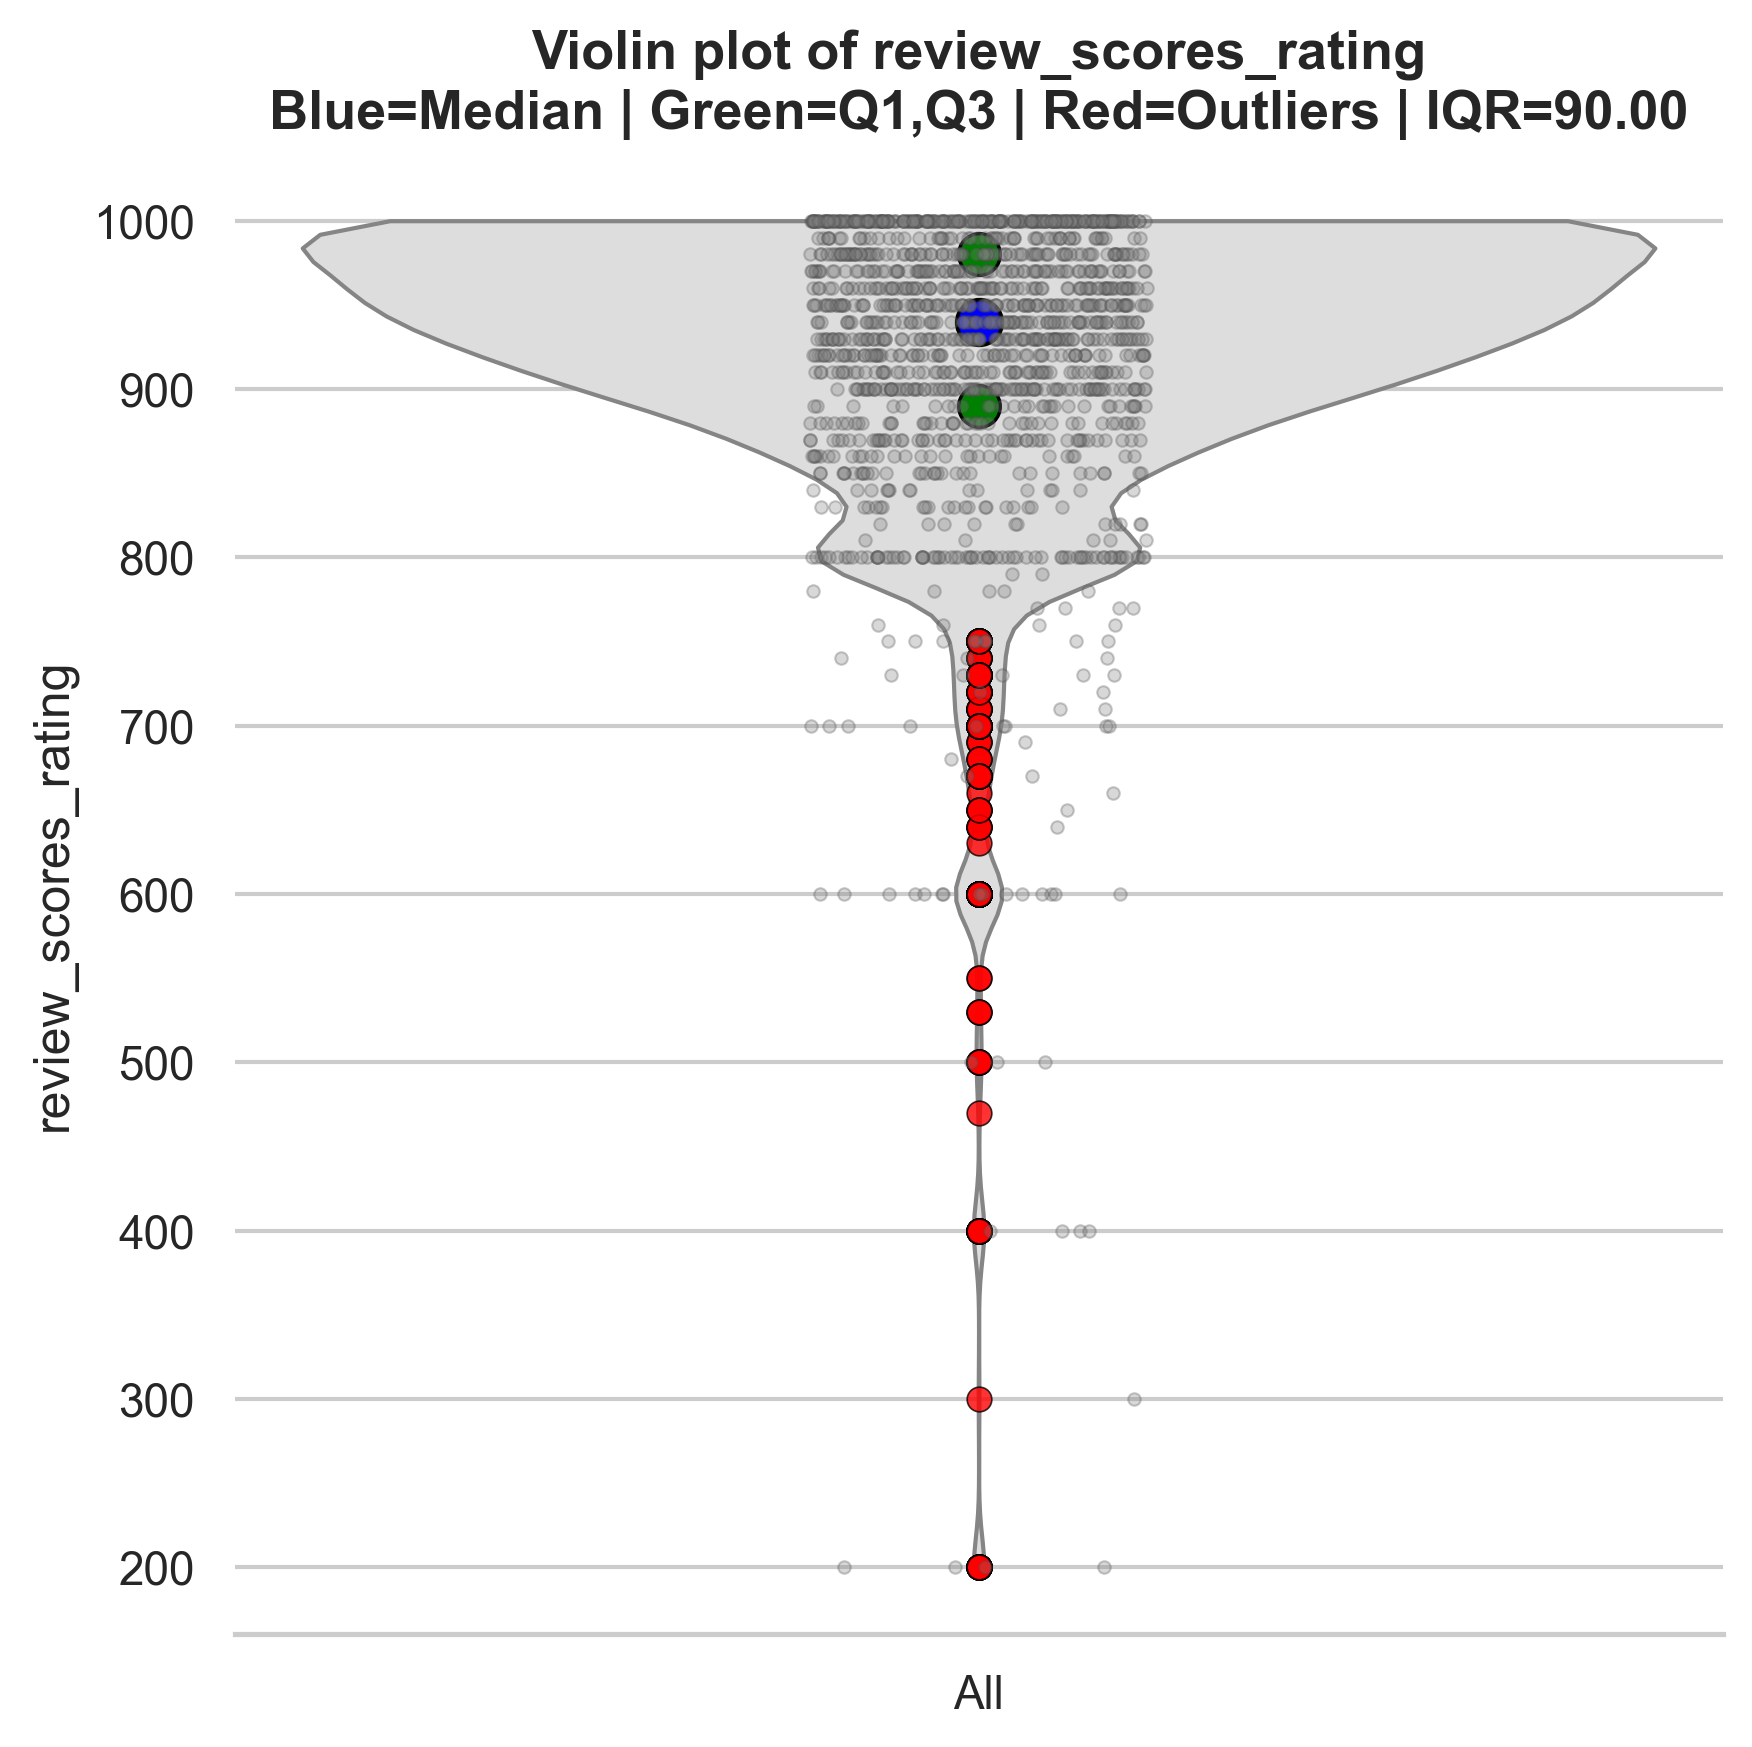

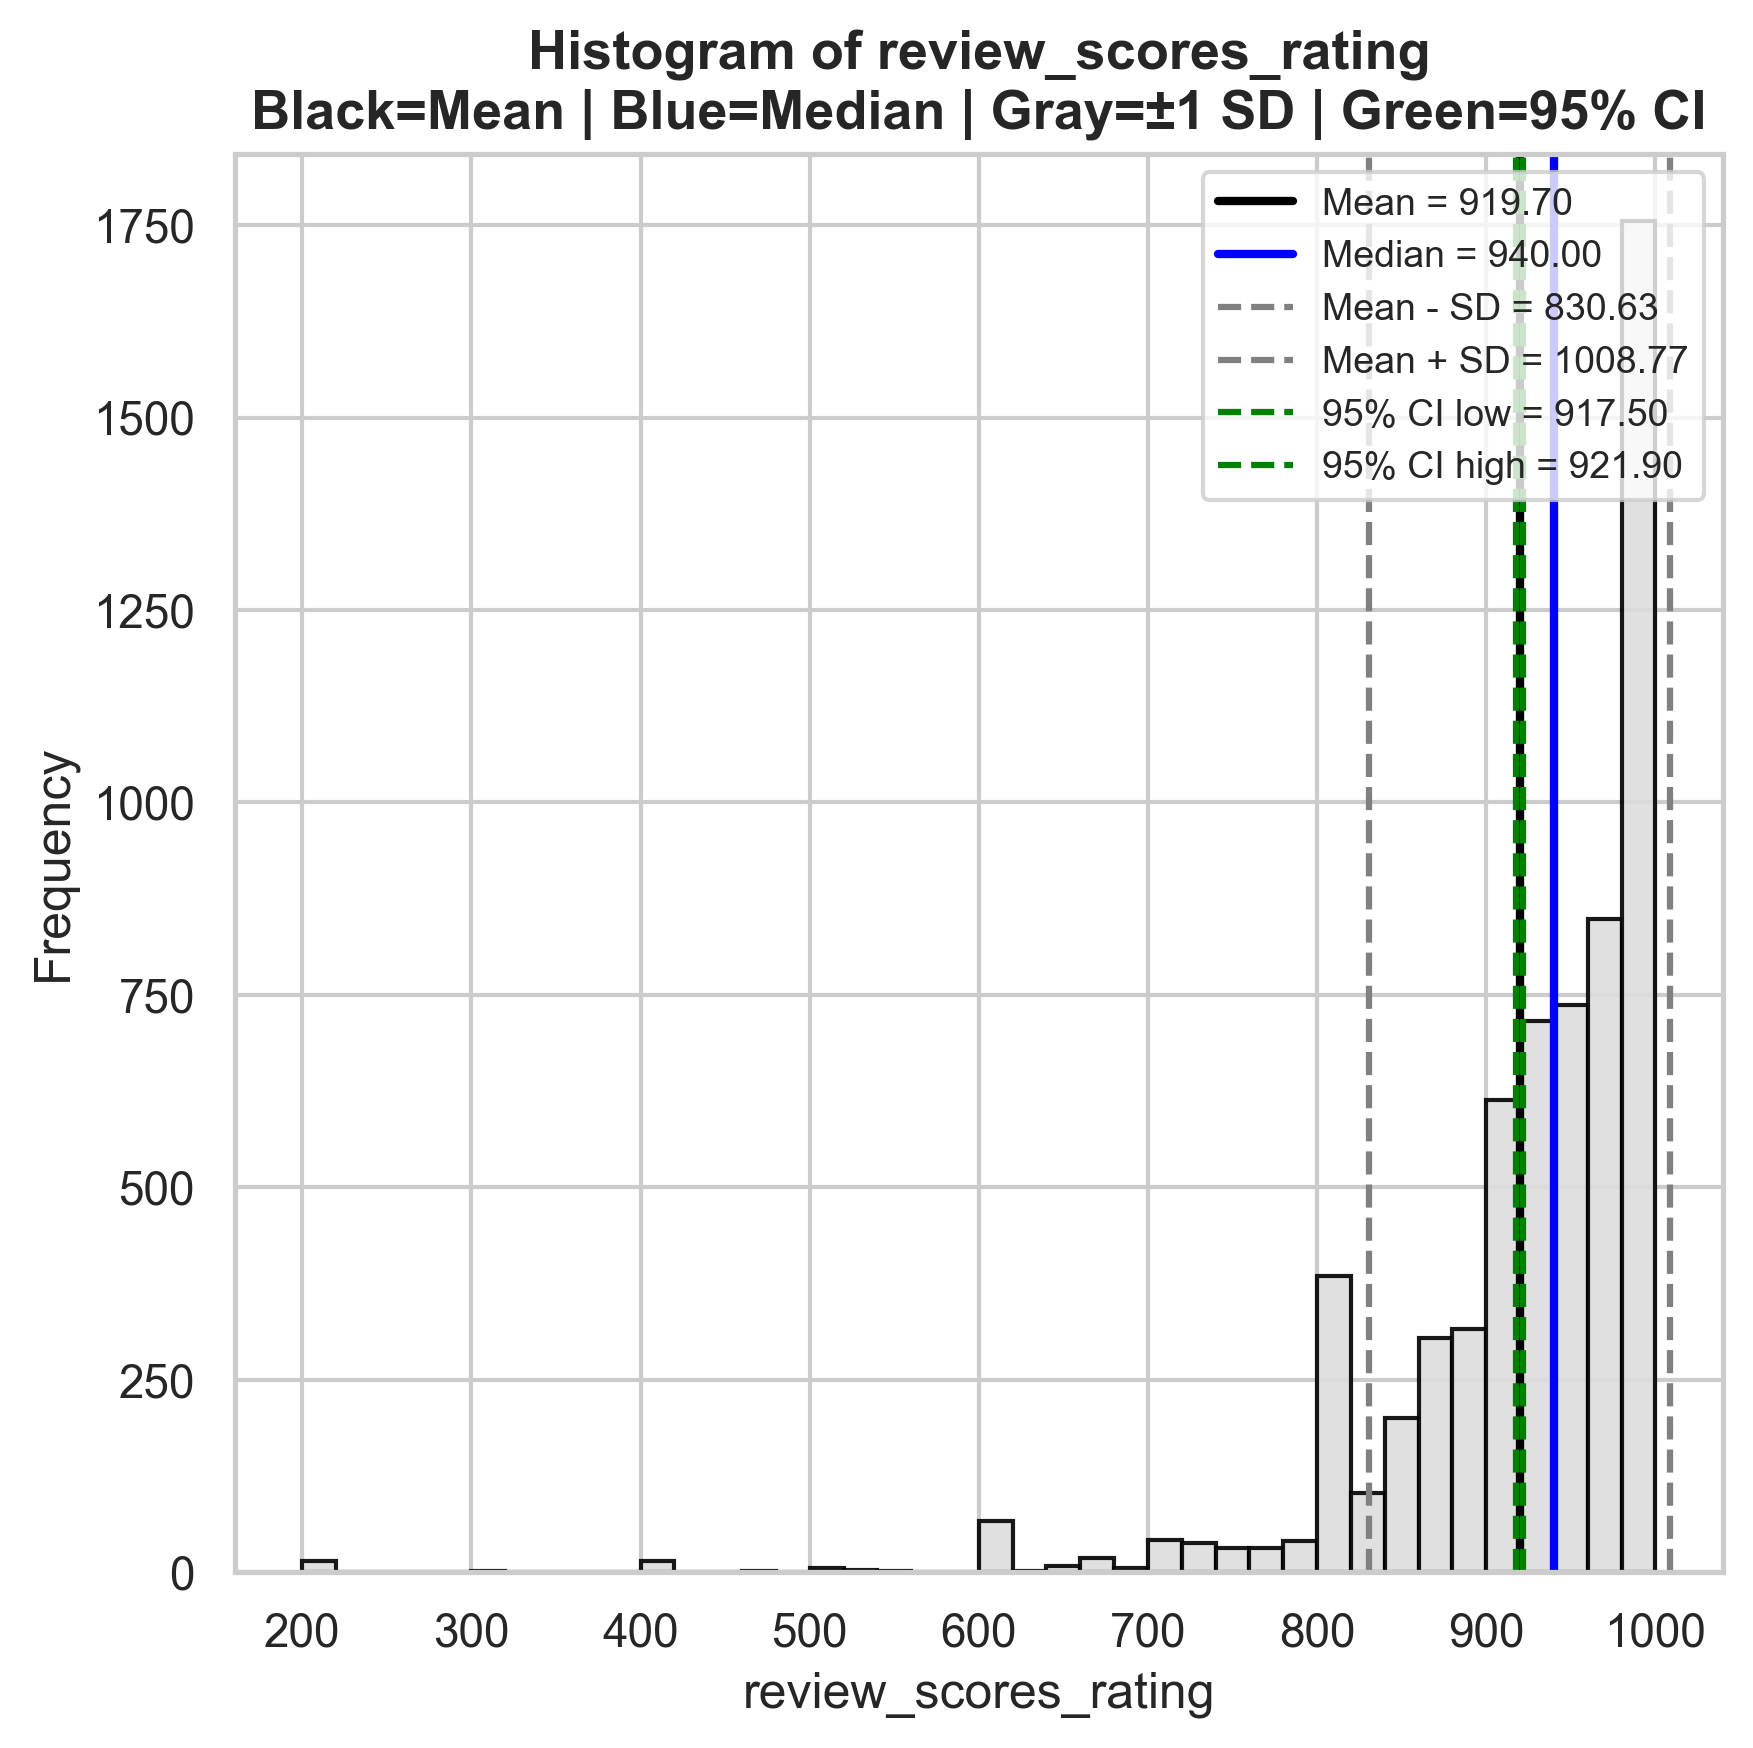

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_rating,6304,919.698604,940.0,89.067148,917.499525,921.897684,890.0,980.0,90.0,755.0,1115.0,254,-2.826609,Highly skewed.



Unique values table
Number of non-nulls: 6304
Number of unique values: 46


,column,value,count,frequency_non_null
0,review_scores_rating,200.0,15,0.002379
1,review_scores_rating,300.0,1,0.000159
2,review_scores_rating,400.0,15,0.002379
3,review_scores_rating,470.0,1,0.000159
4,review_scores_rating,500.0,6,0.000952
5,review_scores_rating,530.0,3,0.000476
6,review_scores_rating,550.0,2,0.000317
7,review_scores_rating,600.0,66,0.010470
8,review_scores_rating,630.0,1,0.000159
9,review_scores_rating,640.0,4,0.000635



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_rating,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_rating,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_rating,numeric,city,categorical,Chi-square,327.594449,7.782916e-53,Significant,Statistically significant at p < 0.05.,
3,review_scores_rating,numeric,room_type,categorical,Chi-square,17.934607,1.176906e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_rating,numeric,accommodates,numeric,Pearson,-0.004948,6.944705e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_rating,numeric,bathrooms,numeric,Pearson,0.056509,7.535268e-06,Significant,Statistically significant at p < 0.05.,
6,review_scores_rating,numeric,bedrooms,numeric,Pearson,0.031490,1.263156e-02,Significant,Statistically significant at p < 0.05.,
7,review_scores_rating,numeric,beds,numeric,Pearson,-0.001146,9.275418e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_rating,numeric,price,numeric,Pearson,0.040561,1.390839e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_rating,numeric,minimum_nights,numeric,Pearson,-0.009433,4.539787e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.826609,Highly skewed.,Baseline.
1,Log Transformation,-5.777961,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.935327,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.333142,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [27]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_rating",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Score Ratings*:
- mediana: 940.0
- IQR=90.0 [890.0; 980.0]
- 254 outliers determined
- apply Box-Cox Transformation to improve normal distribution shape of the data
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: review_scores_accuracy (r=0.73), review_scores_value (r=0.76)
    * medium and significantly correlated with: review_scores_cleanliness (r=0.69), review_scores_checkin (r=0.57), review_scores_communication (r=0.61), review_scores_location (r=0.40)
    * weakly and significantly correlated with: accommodates none found

##### ACCURACY

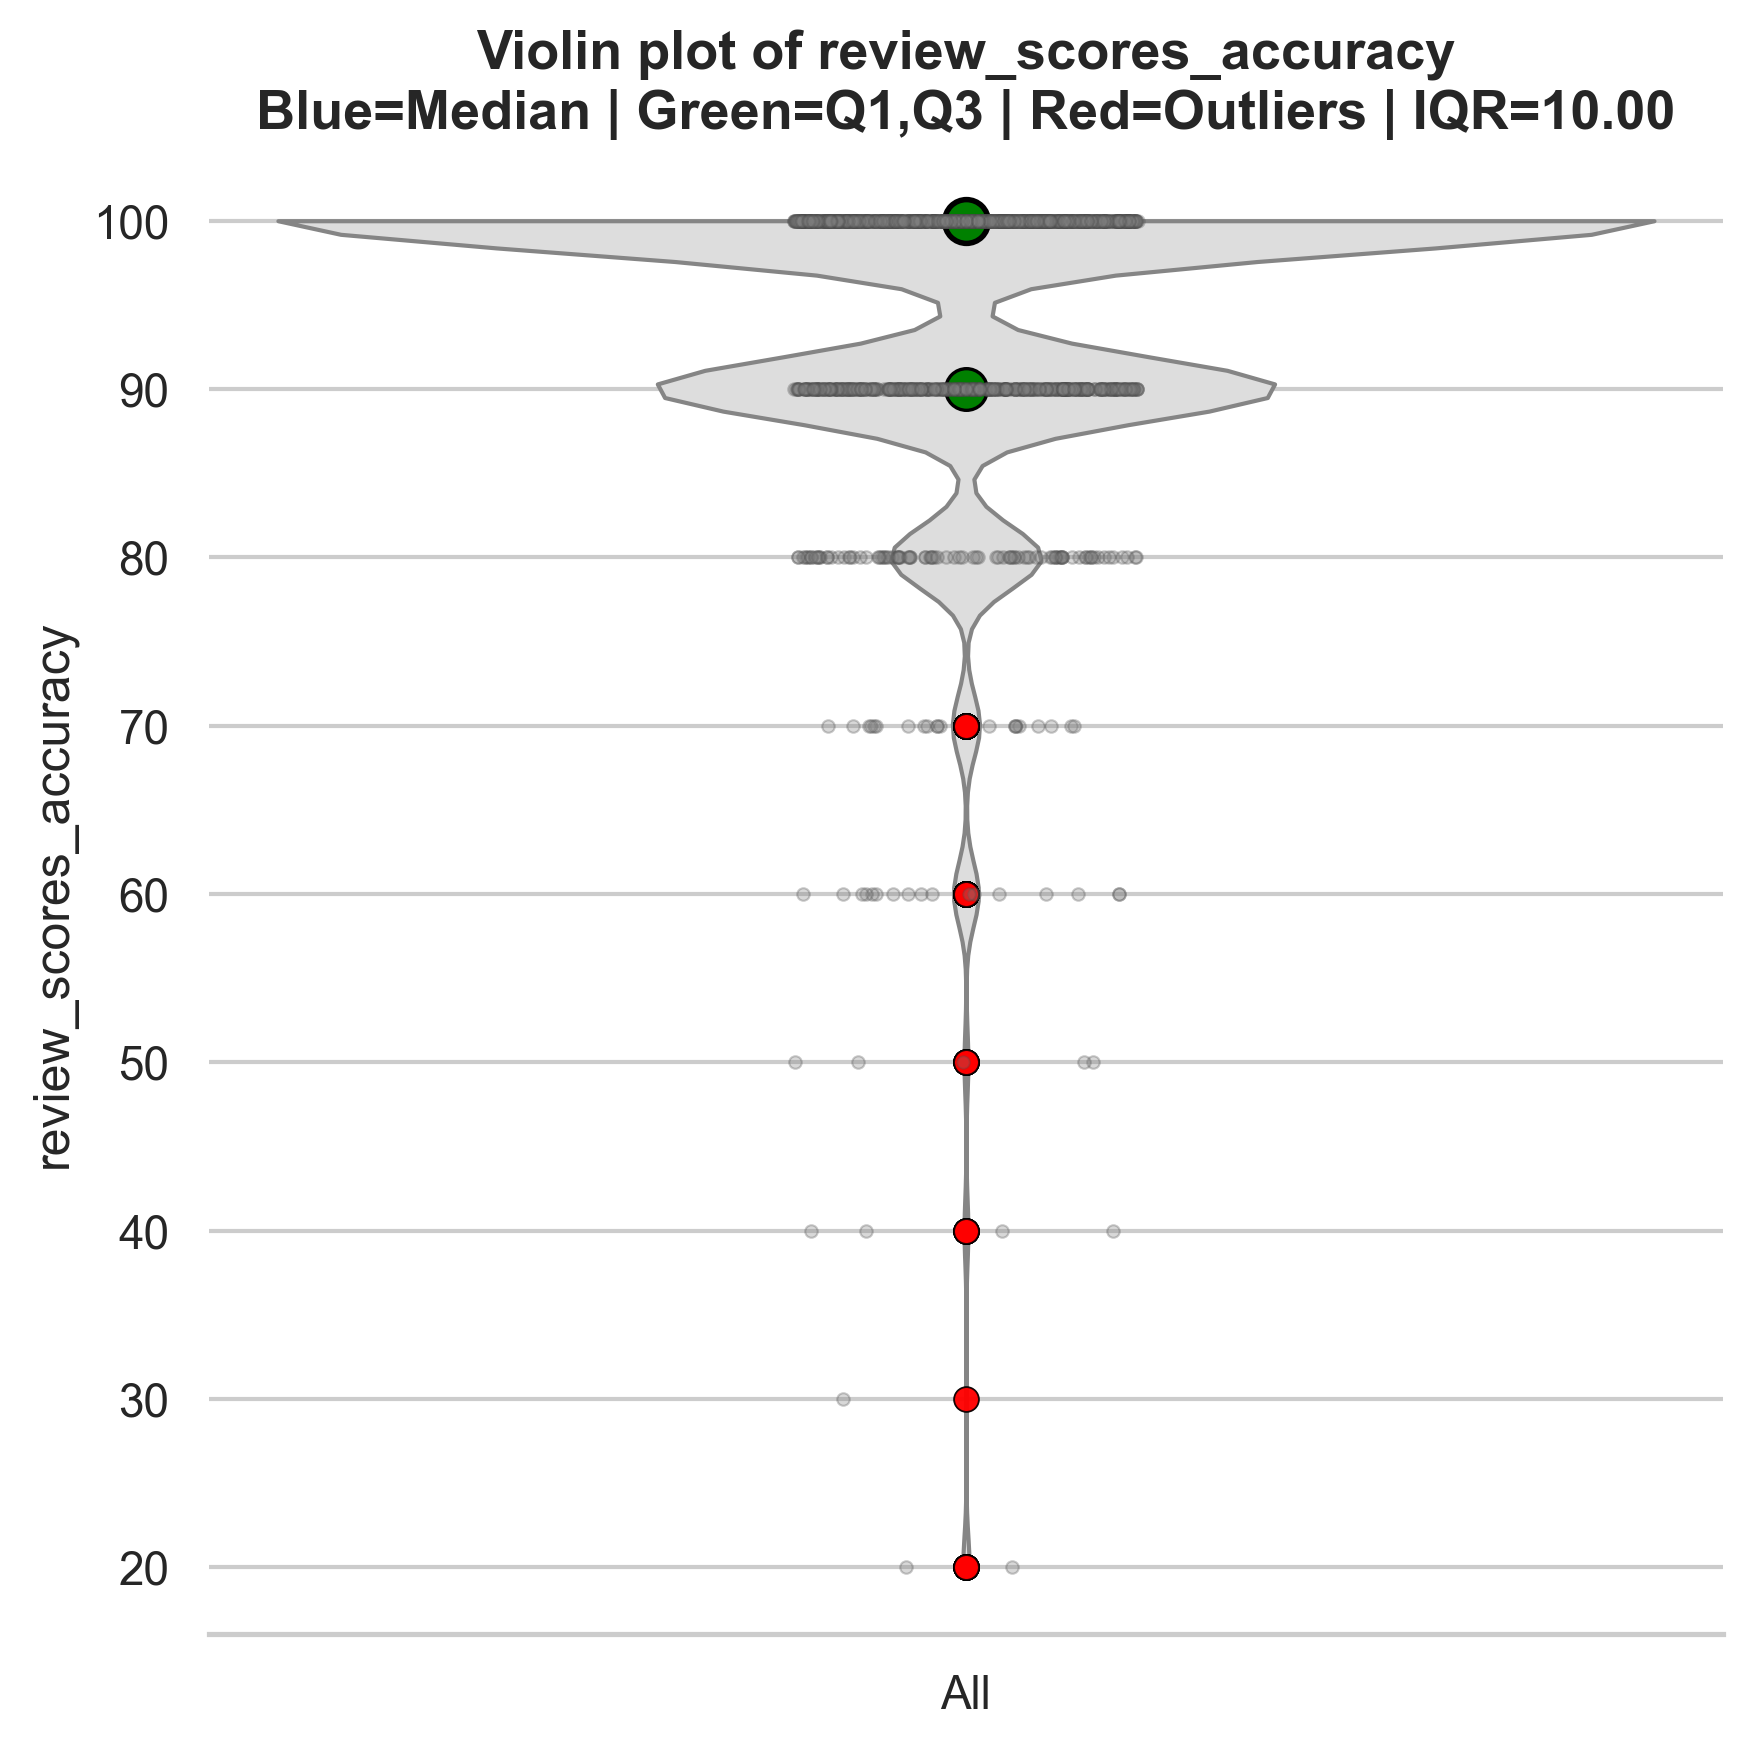

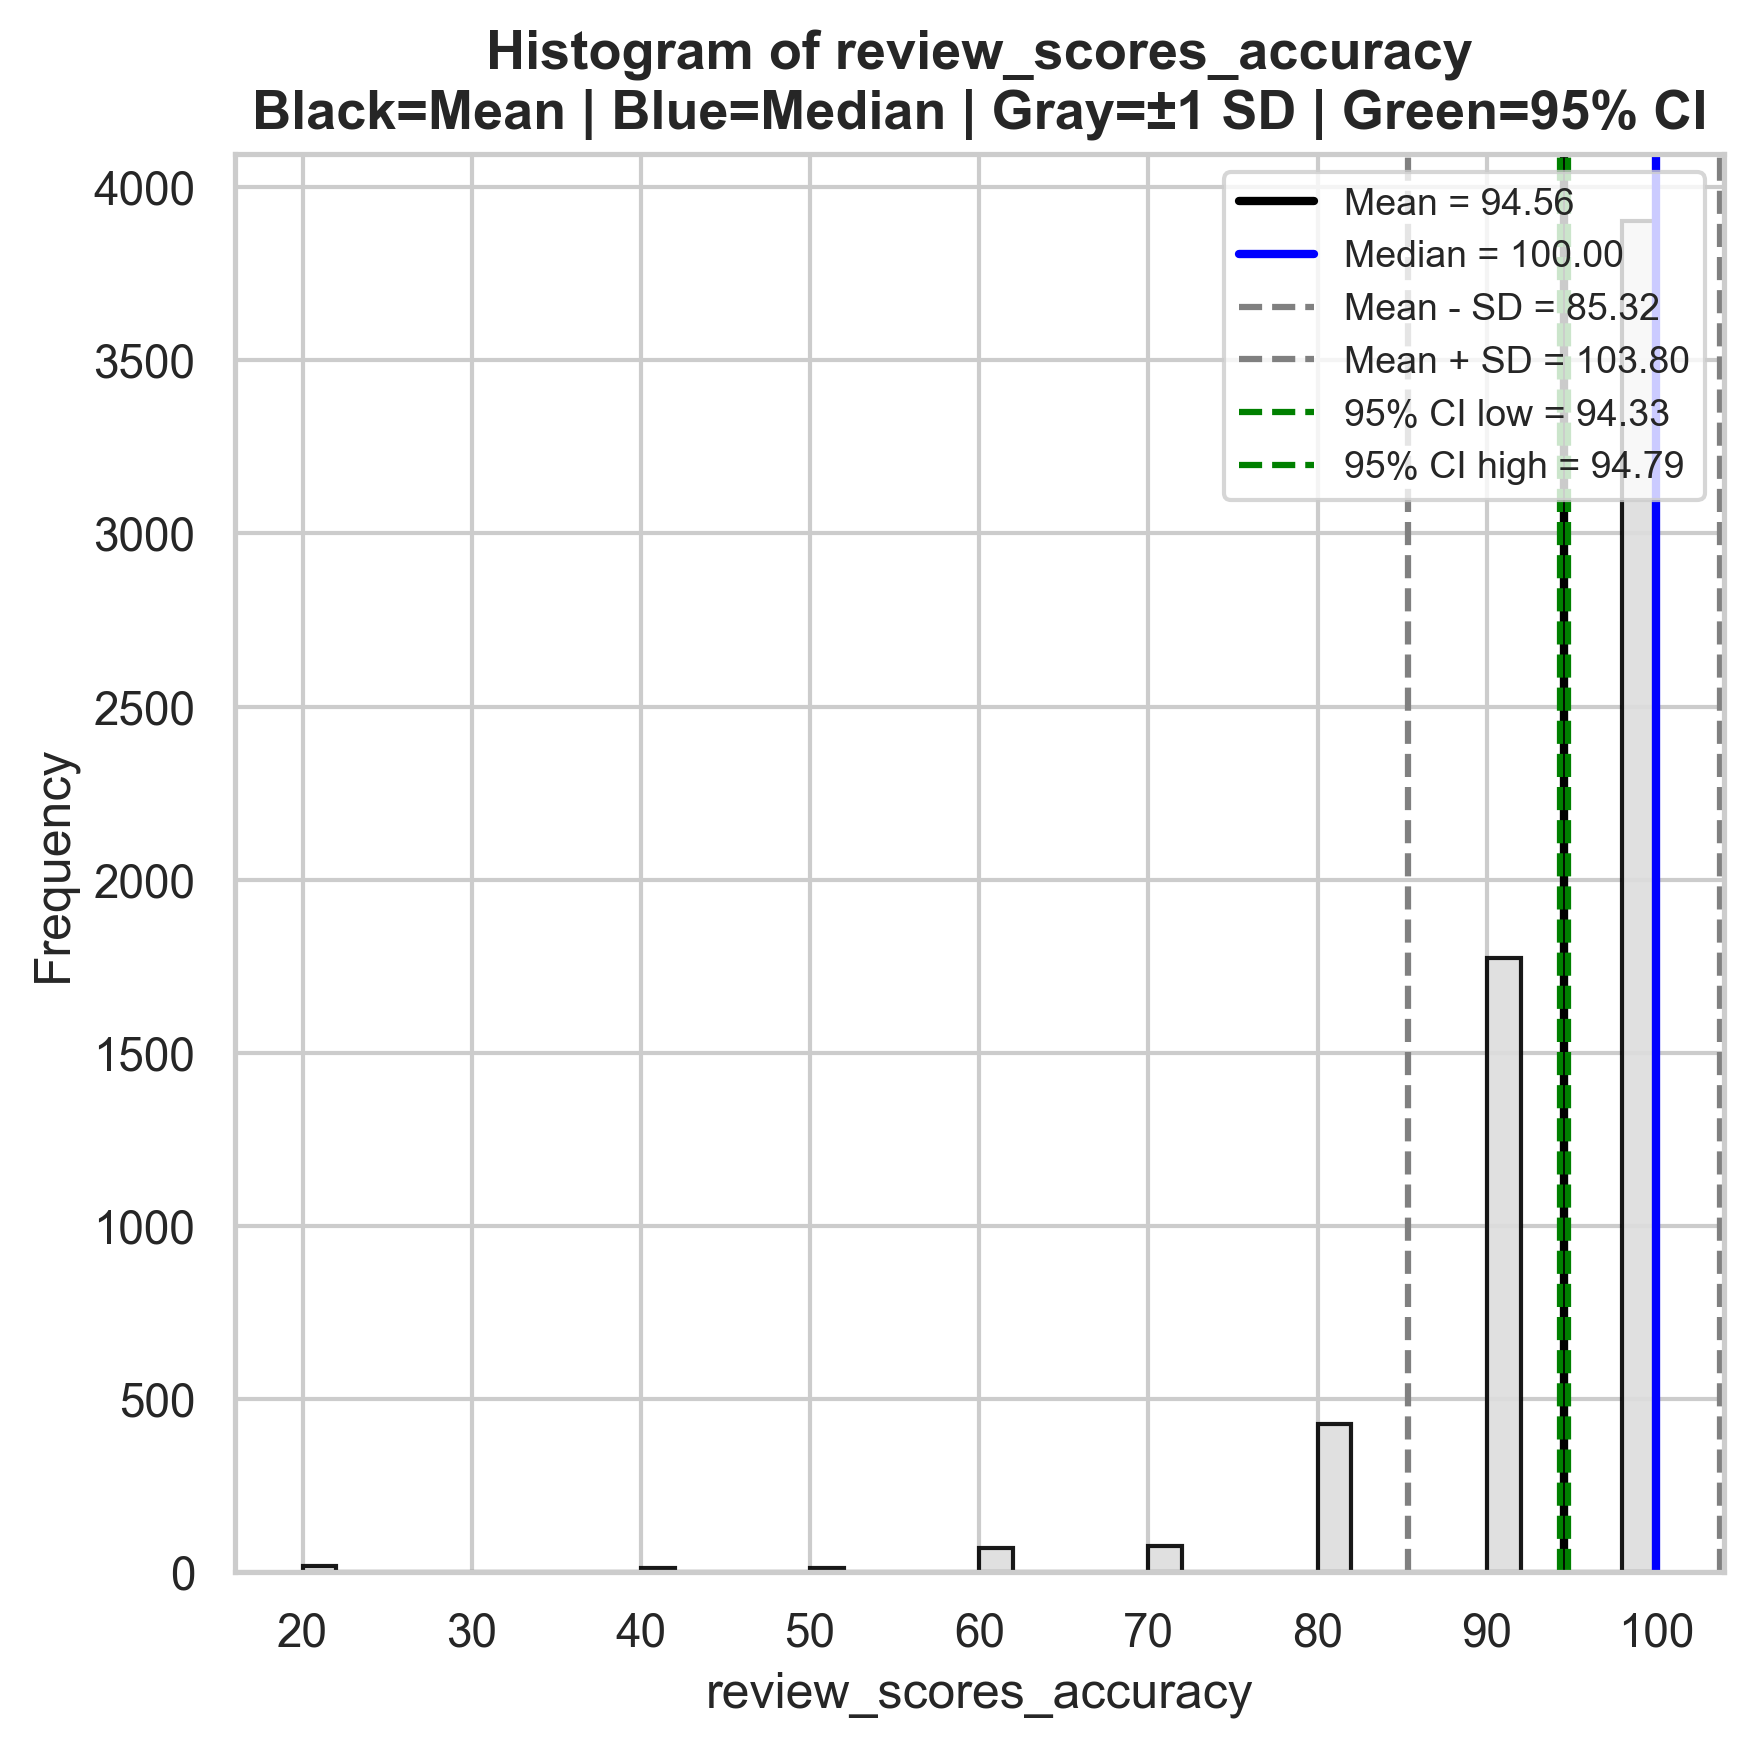

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_accuracy,6295,94.557585,100.0,9.241515,94.329248,94.785923,90.0,100.0,10.0,75.0,115.0,190,-3.159527,Highly skewed.



Unique values table
Number of non-nulls: 6295
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_accuracy,20.0,18,0.002859
1,review_scores_accuracy,30.0,2,0.000318
2,review_scores_accuracy,40.0,11,0.001747
3,review_scores_accuracy,50.0,11,0.001747
4,review_scores_accuracy,60.0,71,0.011279
5,review_scores_accuracy,70.0,77,0.012232
6,review_scores_accuracy,80.0,429,0.068149
7,review_scores_accuracy,90.0,1774,0.281811
8,review_scores_accuracy,100.0,3902,0.619857



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_accuracy,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_accuracy,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_accuracy,numeric,city,categorical,Chi-square,114.960296,8.567878e-22,Significant,Statistically significant at p < 0.05.,
3,review_scores_accuracy,numeric,room_type,categorical,Chi-square,6.853758,7.670800e-02,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_accuracy,numeric,accommodates,numeric,Pearson,-0.047827,1.469998e-04,Significant,Statistically significant at p < 0.05.,
5,review_scores_accuracy,numeric,bathrooms,numeric,Pearson,-0.000291,9.816496e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_accuracy,numeric,bedrooms,numeric,Pearson,-0.022911,6.982336e-02,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_accuracy,numeric,beds,numeric,Pearson,-0.046696,2.103787e-04,Significant,Statistically significant at p < 0.05.,
8,review_scores_accuracy,numeric,price,numeric,Pearson,-0.018457,1.462259e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_accuracy,numeric,minimum_nights,numeric,Pearson,-0.011274,3.711356e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.159527,Highly skewed.,Baseline.
1,Log Transformation,-6.202875,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-4.321975,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.661120,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [28]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_accuracy",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Accuracy*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 190 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 48,8% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: review_scores_rating (r=0.73)
    * medium and significantly correlated with: review_scores_cleanliness (r=0.59), review_scores_checkin (r=0.56), review_scores_communication (r=0.59),review_scores_location (r=0.39), review_scores_value (r=0.65)
    * weakly and significantly correlated with: number_of_reviews (r=0.12), reviews_per_month (r=0.12)
- Non parametric tests must be applied

##### CLEANLINESS

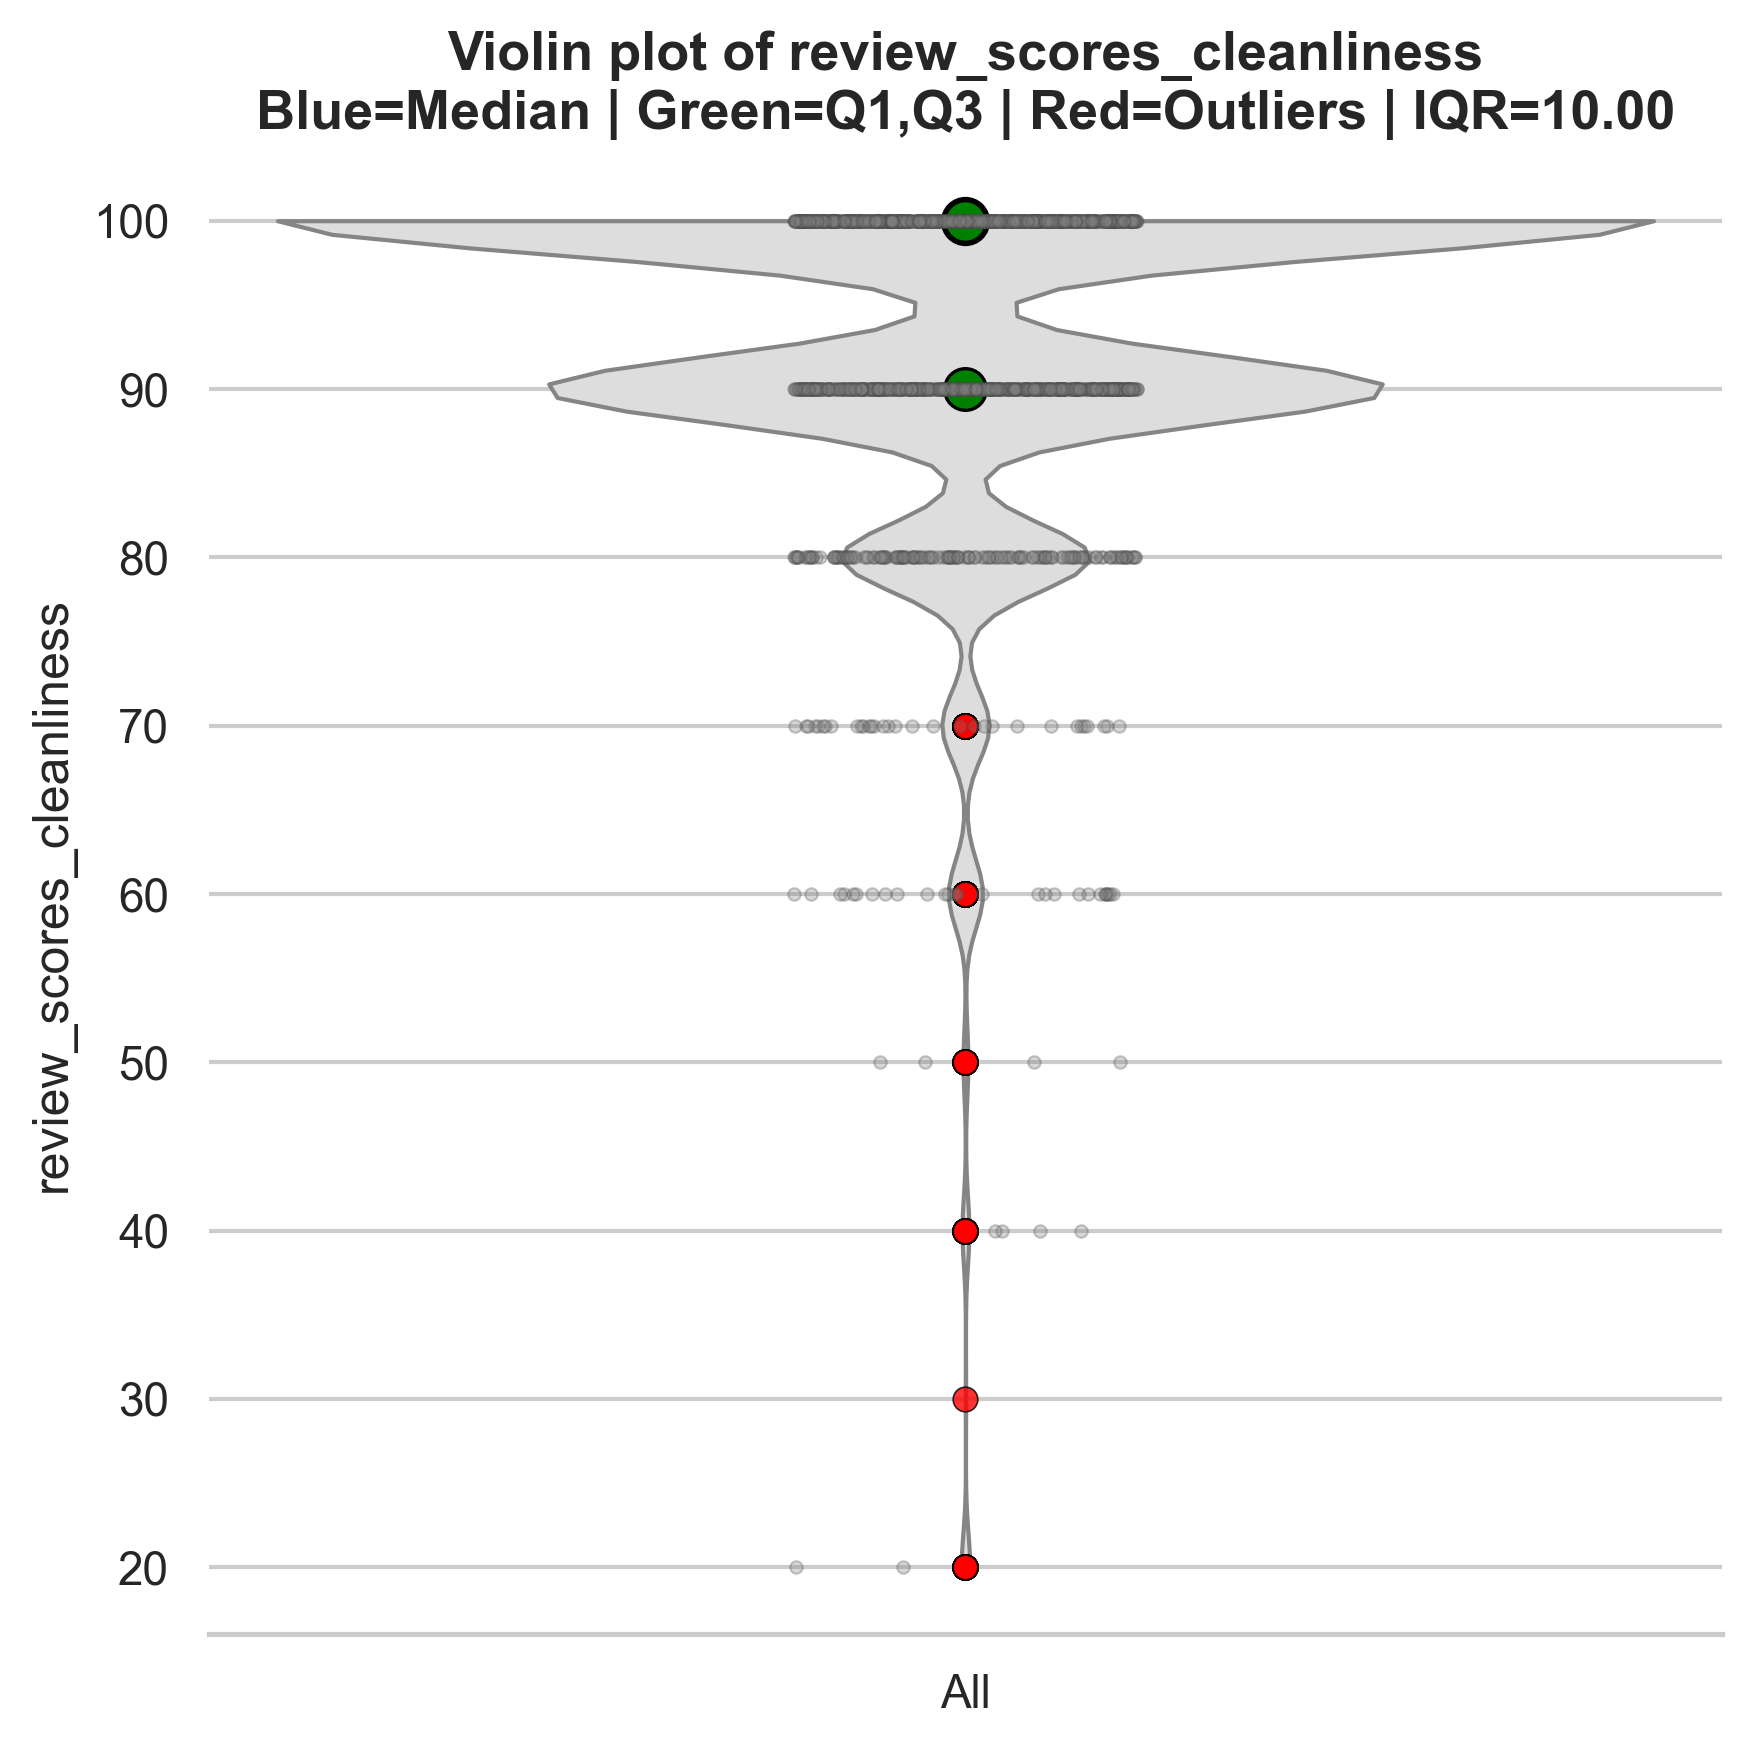

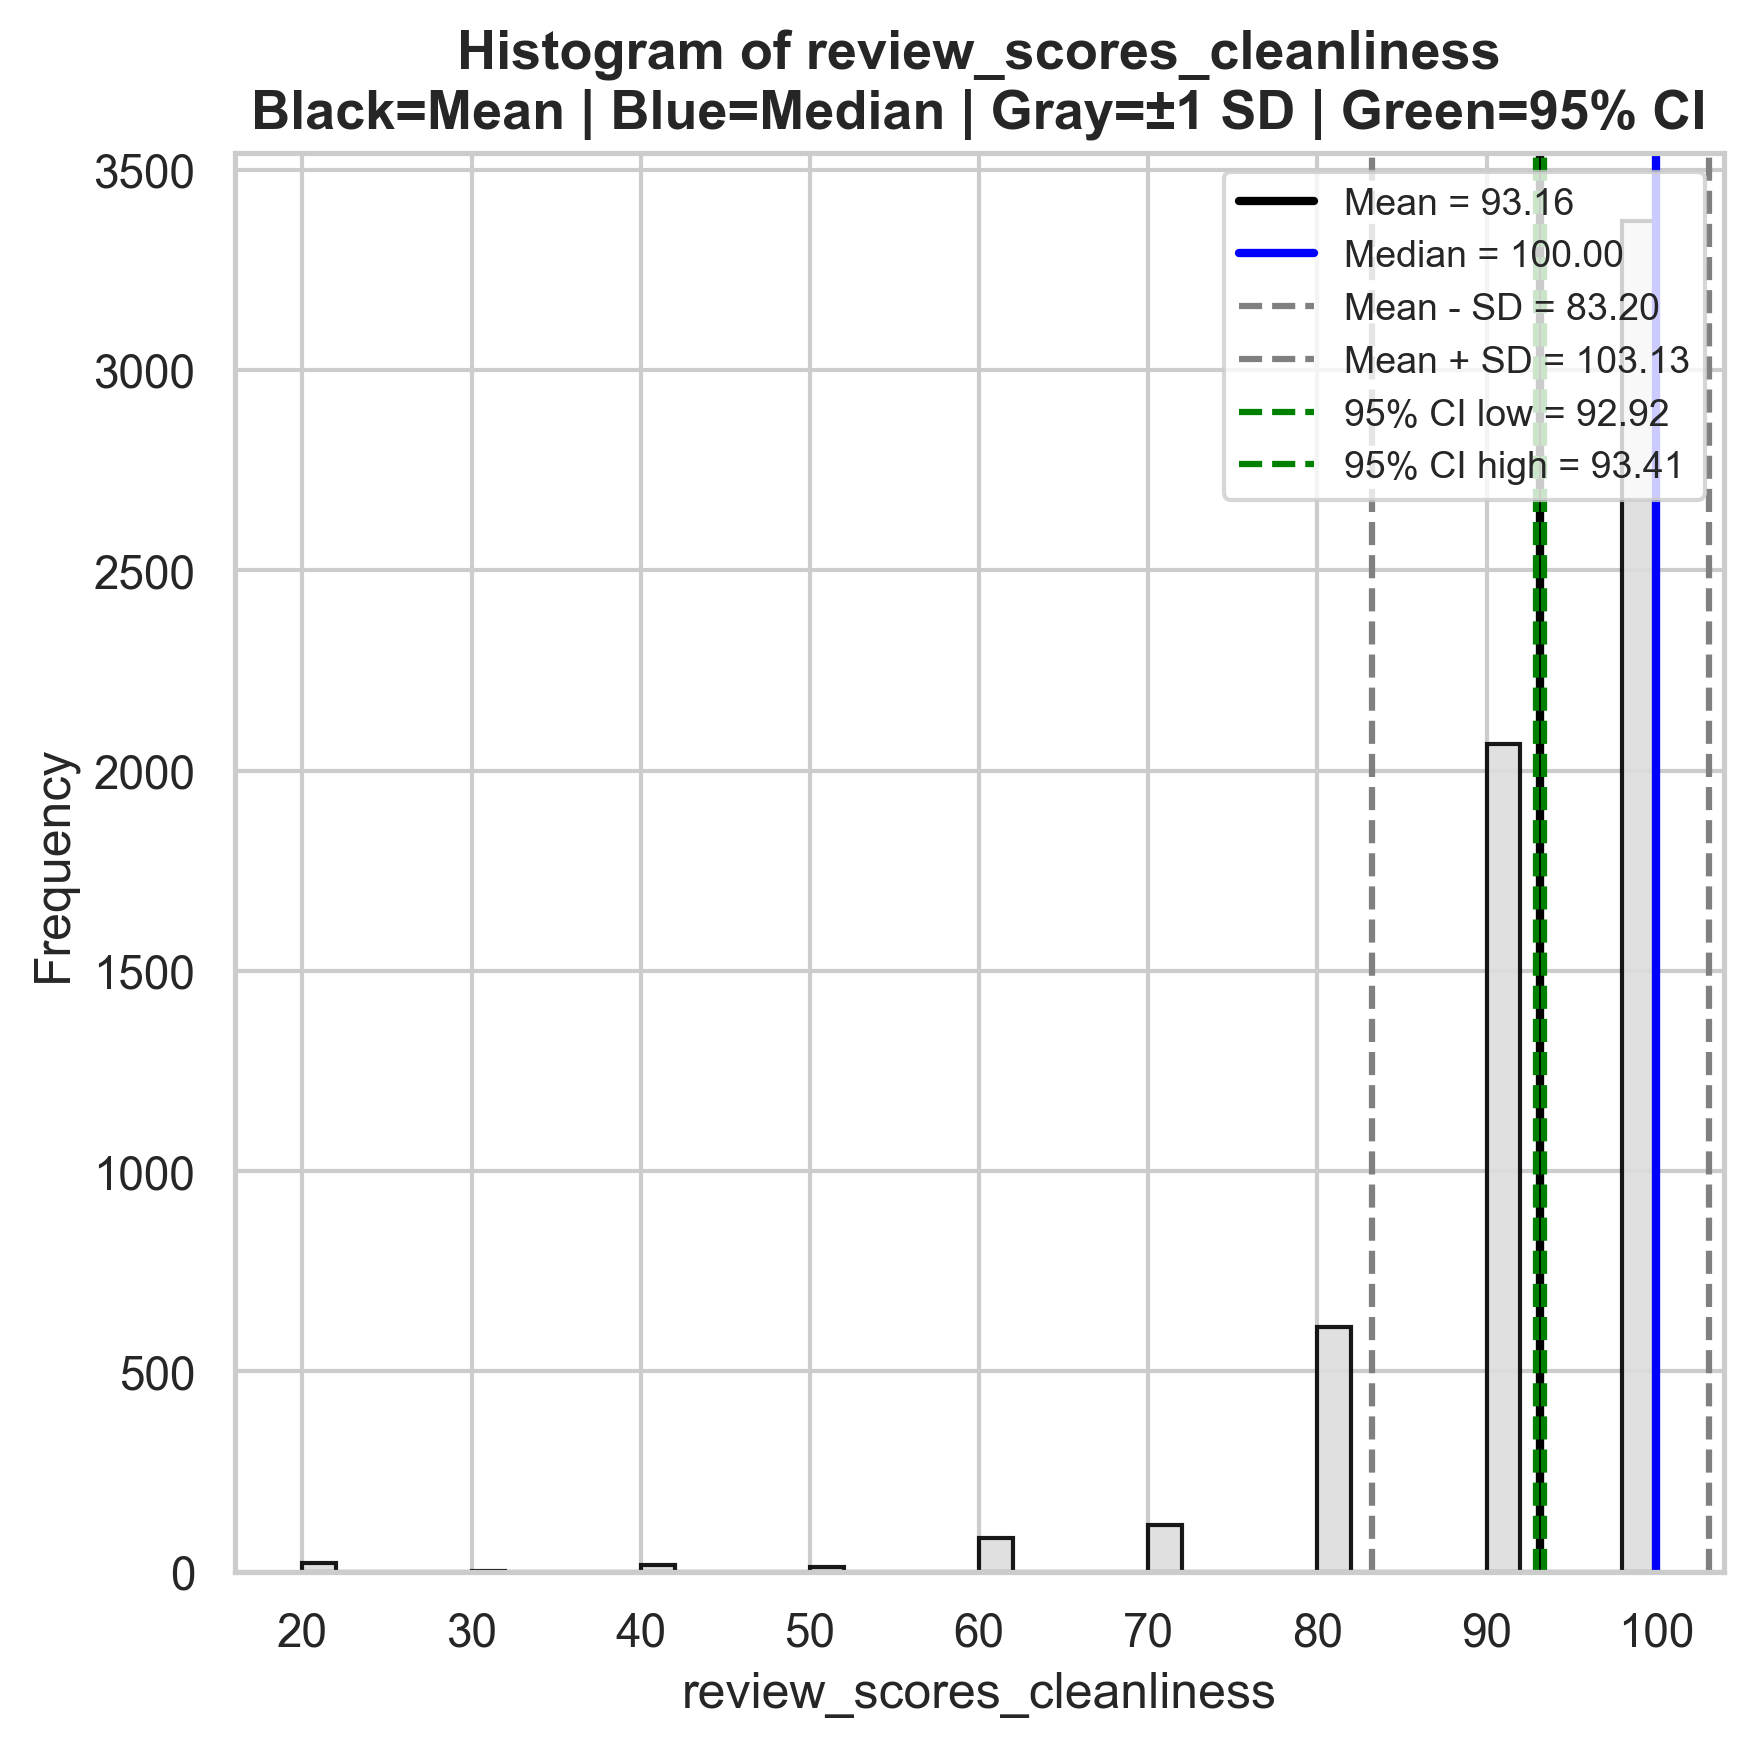

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,6301,93.16299,100.0,9.963916,92.916921,93.409059,90.0,100.0,10.0,75.0,115.0,251,-2.70934,Highly skewed.



Unique values table
Number of non-nulls: 6301
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,21,0.003333
1,review_scores_cleanliness,30.0,1,0.000159
2,review_scores_cleanliness,40.0,17,0.002698
3,review_scores_cleanliness,50.0,12,0.001904
4,review_scores_cleanliness,60.0,84,0.013331
5,review_scores_cleanliness,70.0,116,0.018410
6,review_scores_cleanliness,80.0,610,0.096810
7,review_scores_cleanliness,90.0,2067,0.328043
8,review_scores_cleanliness,100.0,3373,0.535312



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,98.084055,2.681676e-18,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,3.517664,3.184784e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.012441,3.234471e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,numeric,Pearson,0.023507,6.272523e-02,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,numeric,Pearson,0.010766,3.940719e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.015888,2.073096e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.038037,2.728896e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.015066,2.318085e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.709340,Highly skewed.,Baseline.
1,Log Transformation,-5.511142,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.777461,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.479937,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [29]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_cleanliness",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Cleanliness*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 251 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 42,2% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.69), review_scores_accuracy (r=0.59), review_scores_checkin (r=0.46), review_scores_communication (r=0.50), review_scores_value (r=0.61)
    * weakly and significantly correlated with: review_scores_location (r=0.29)
- Non parametric tests must be used

##### CHECKIN

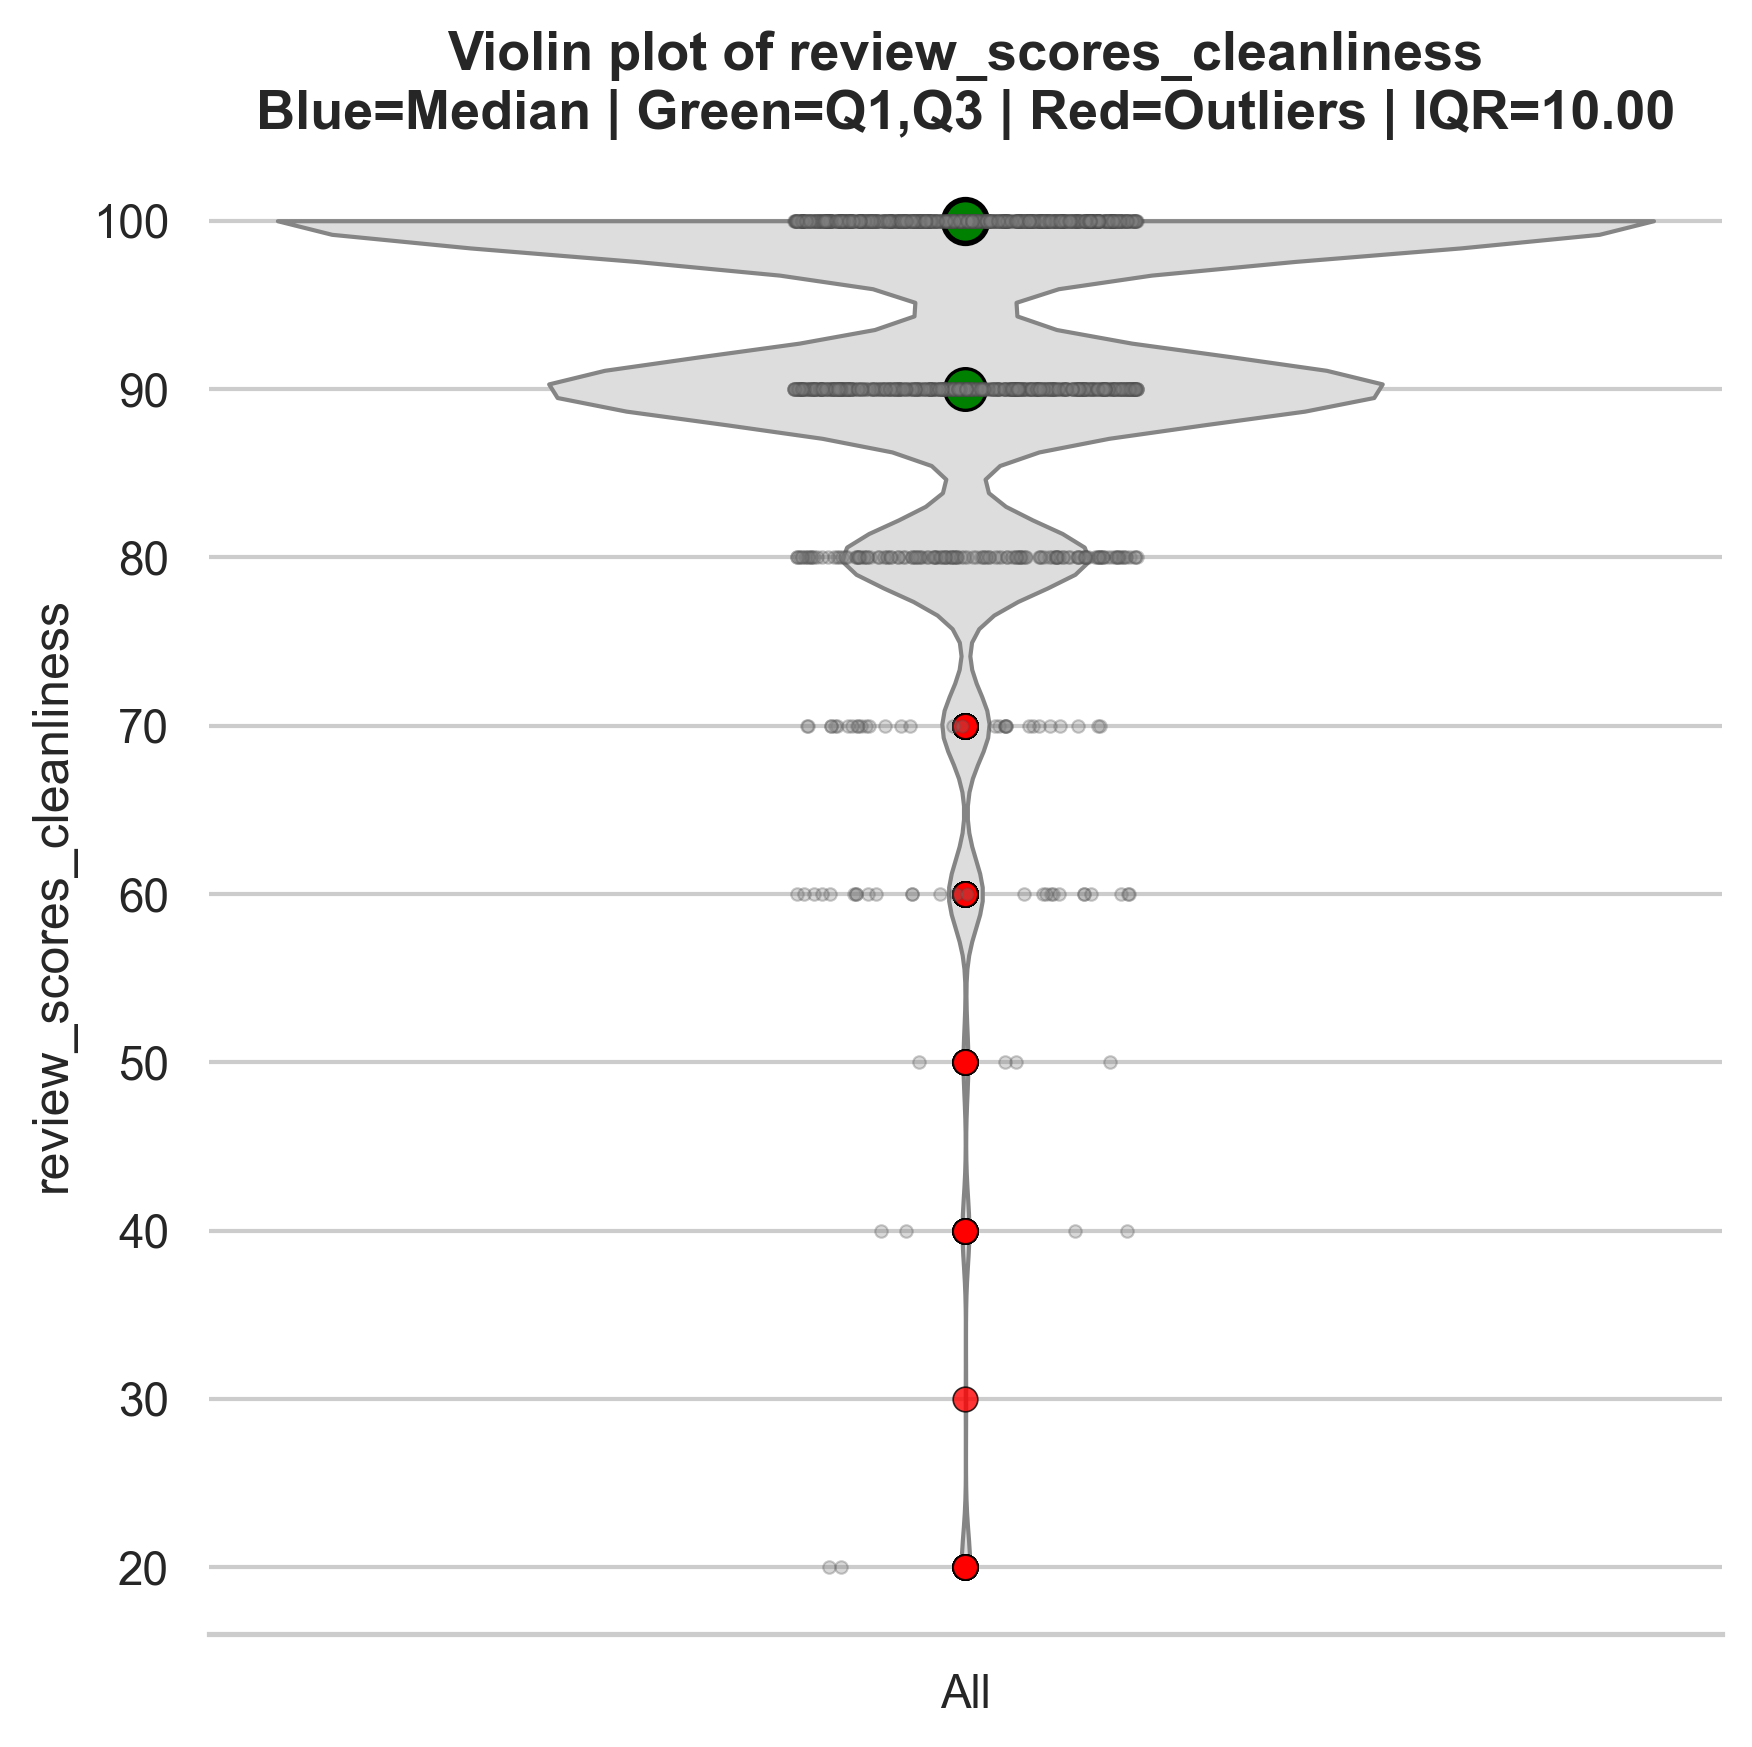

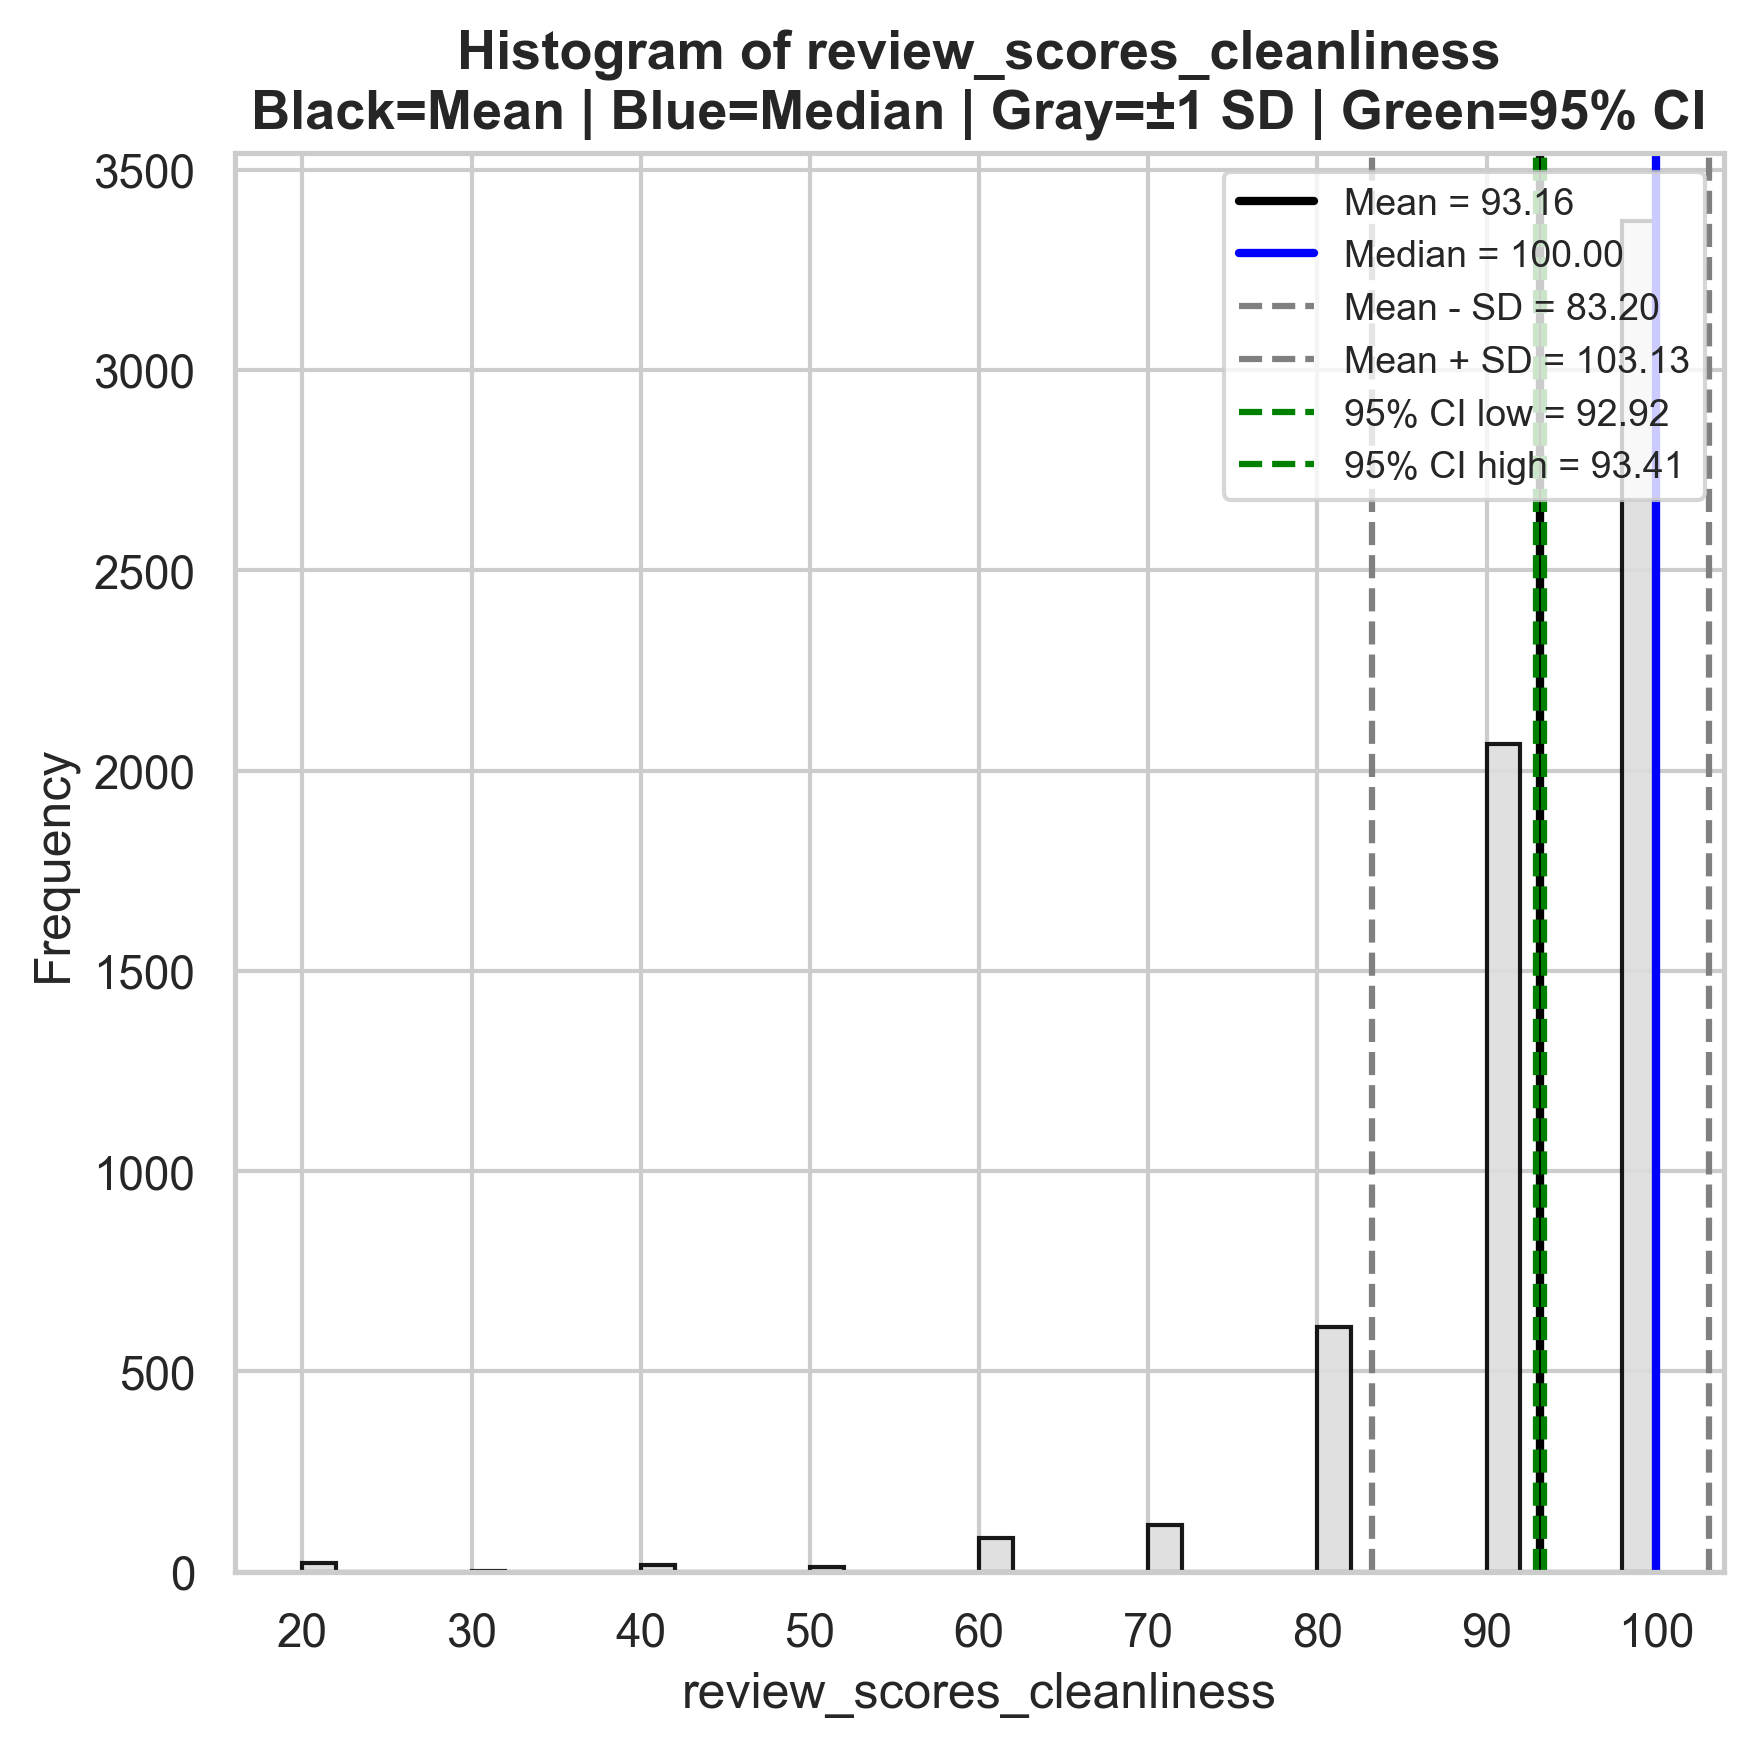

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_cleanliness,6301,93.16299,100.0,9.963916,92.916921,93.409059,90.0,100.0,10.0,75.0,115.0,251,-2.70934,Highly skewed.



Unique values table
Number of non-nulls: 6301
Number of unique values: 9


,column,value,count,frequency_non_null
0,review_scores_cleanliness,20.0,21,0.003333
1,review_scores_cleanliness,30.0,1,0.000159
2,review_scores_cleanliness,40.0,17,0.002698
3,review_scores_cleanliness,50.0,12,0.001904
4,review_scores_cleanliness,60.0,84,0.013331
5,review_scores_cleanliness,70.0,116,0.018410
6,review_scores_cleanliness,80.0,610,0.096810
7,review_scores_cleanliness,90.0,2067,0.328043
8,review_scores_cleanliness,100.0,3373,0.535312



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_cleanliness,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_cleanliness,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_cleanliness,numeric,city,categorical,Chi-square,98.084055,2.681676e-18,Significant,Statistically significant at p < 0.05.,
3,review_scores_cleanliness,numeric,room_type,categorical,Chi-square,3.517664,3.184784e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_cleanliness,numeric,accommodates,numeric,Pearson,-0.012441,3.234471e-01,Not significant,Not statistically significant at p < 0.05.,
5,review_scores_cleanliness,numeric,bathrooms,numeric,Pearson,0.023507,6.272523e-02,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_cleanliness,numeric,bedrooms,numeric,Pearson,0.010766,3.940719e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_cleanliness,numeric,beds,numeric,Pearson,-0.015888,2.073096e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_cleanliness,numeric,price,numeric,Pearson,0.038037,2.728896e-03,Significant,Statistically significant at p < 0.05.,
9,review_scores_cleanliness,numeric,minimum_nights,numeric,Pearson,-0.015066,2.318085e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.709340,Highly skewed.,Baseline.
1,Log Transformation,-5.511142,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.777461,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.479937,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [30]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_cleanliness",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Checkin*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 251 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 42,2% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.68), review_scores_accuracy (r=0.59), review_scores_checkin (r=0.46), review_scores_communication (r=0.50), review_scores_value (r=0.61)
    * weakly and significantly correlated with: review_scores_location (r=0.29)
- Non parametric tests must be used

##### COMMUNICATION

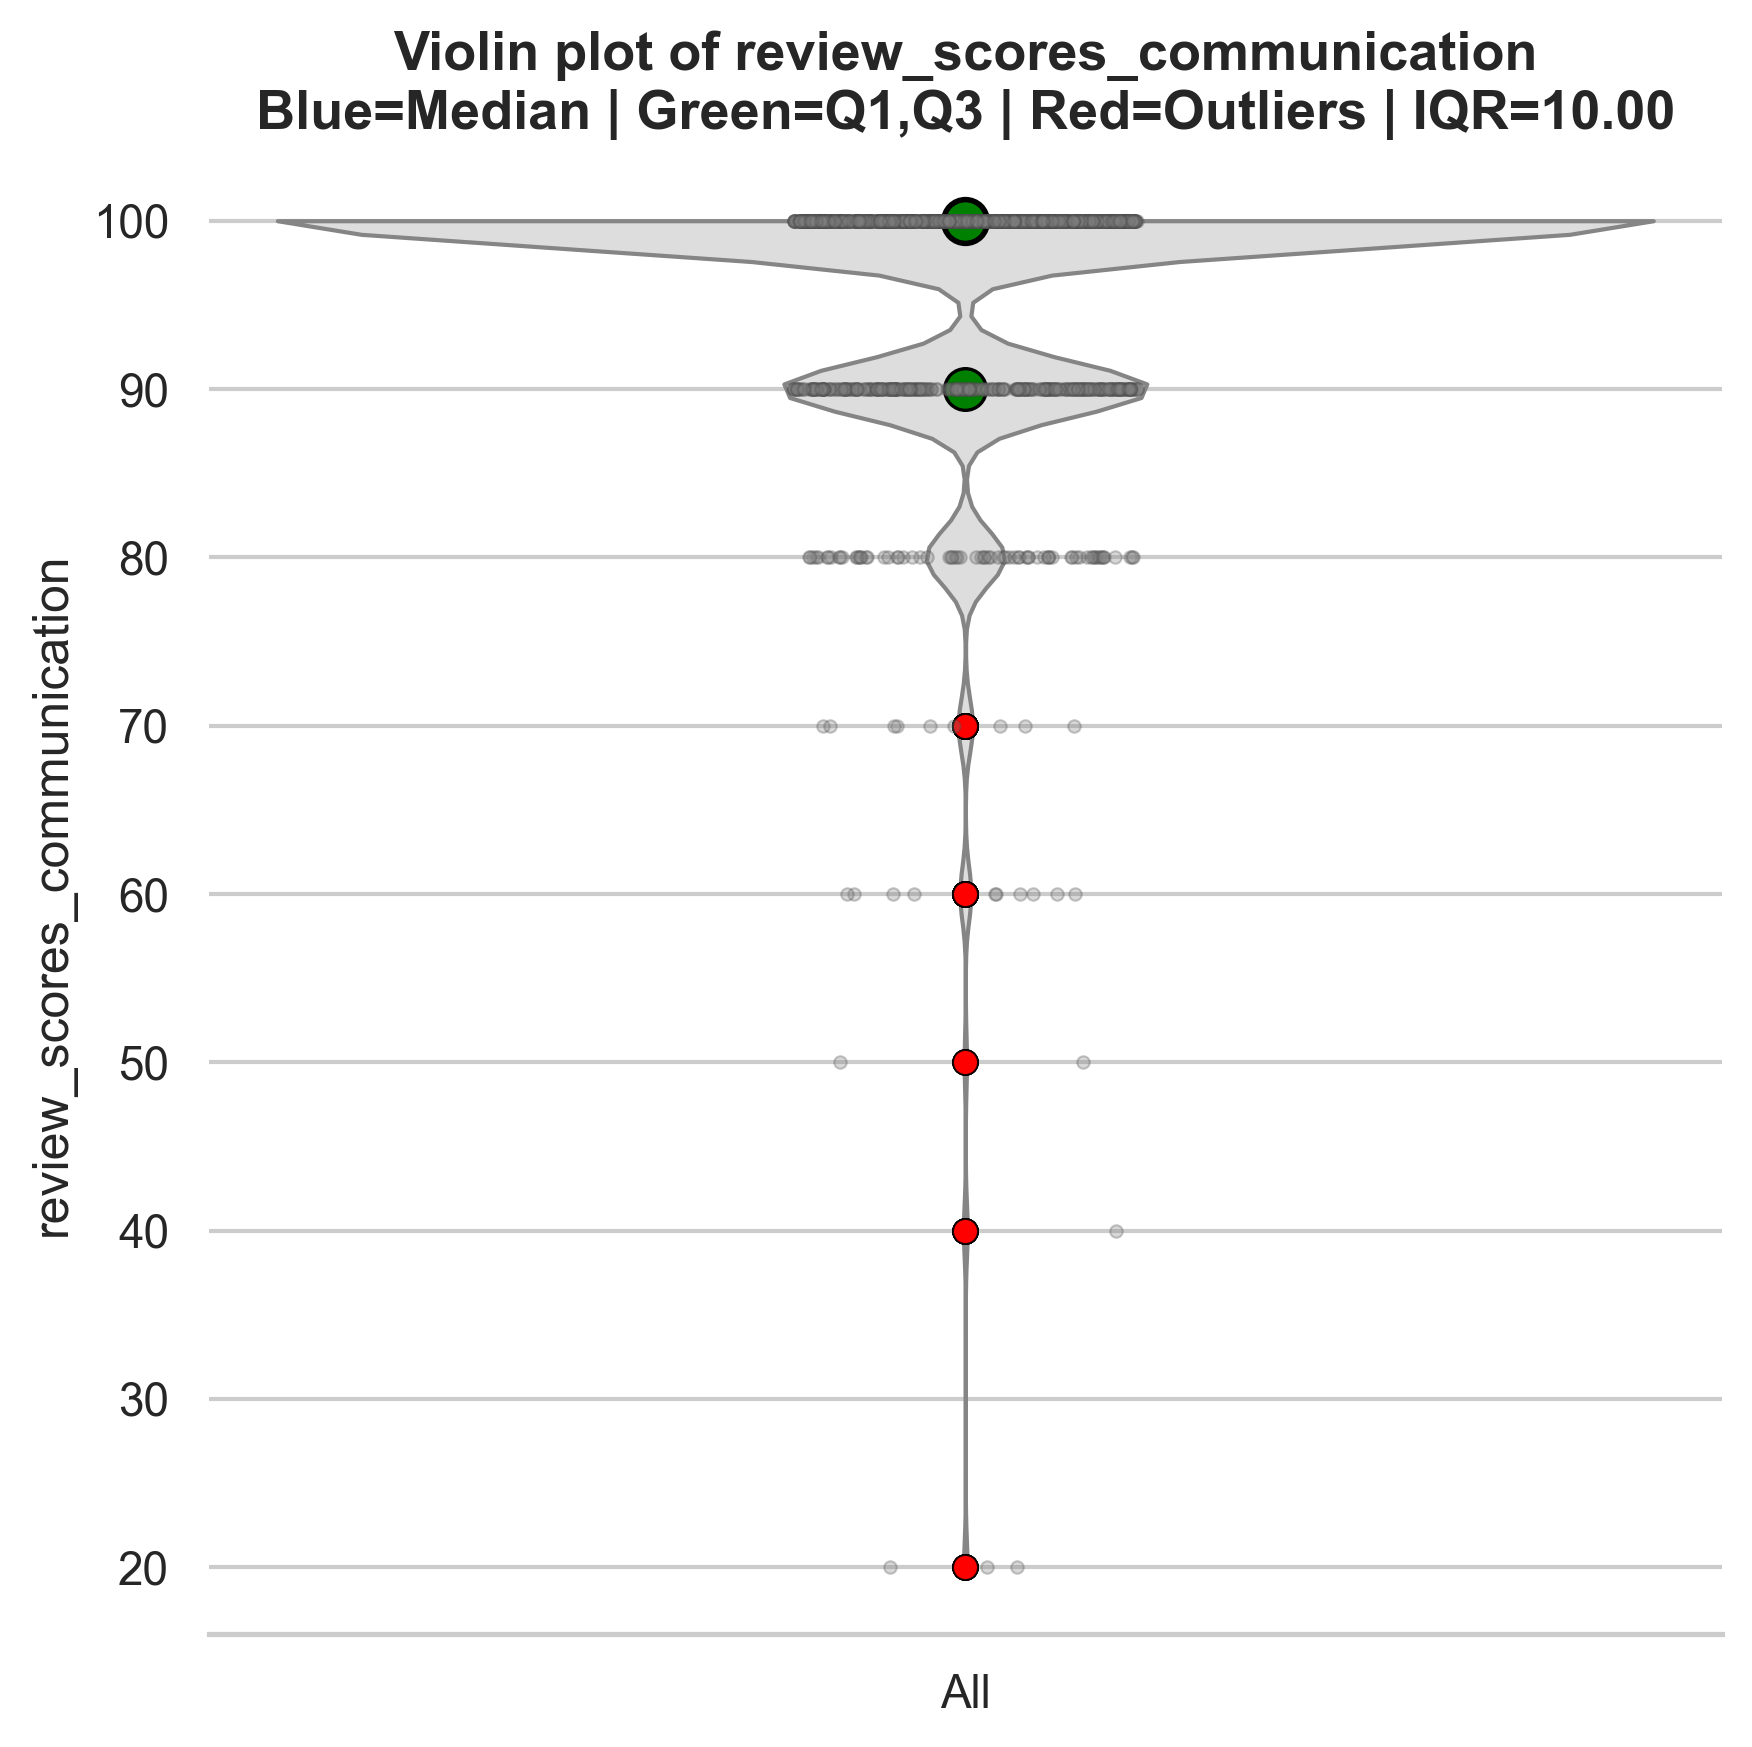

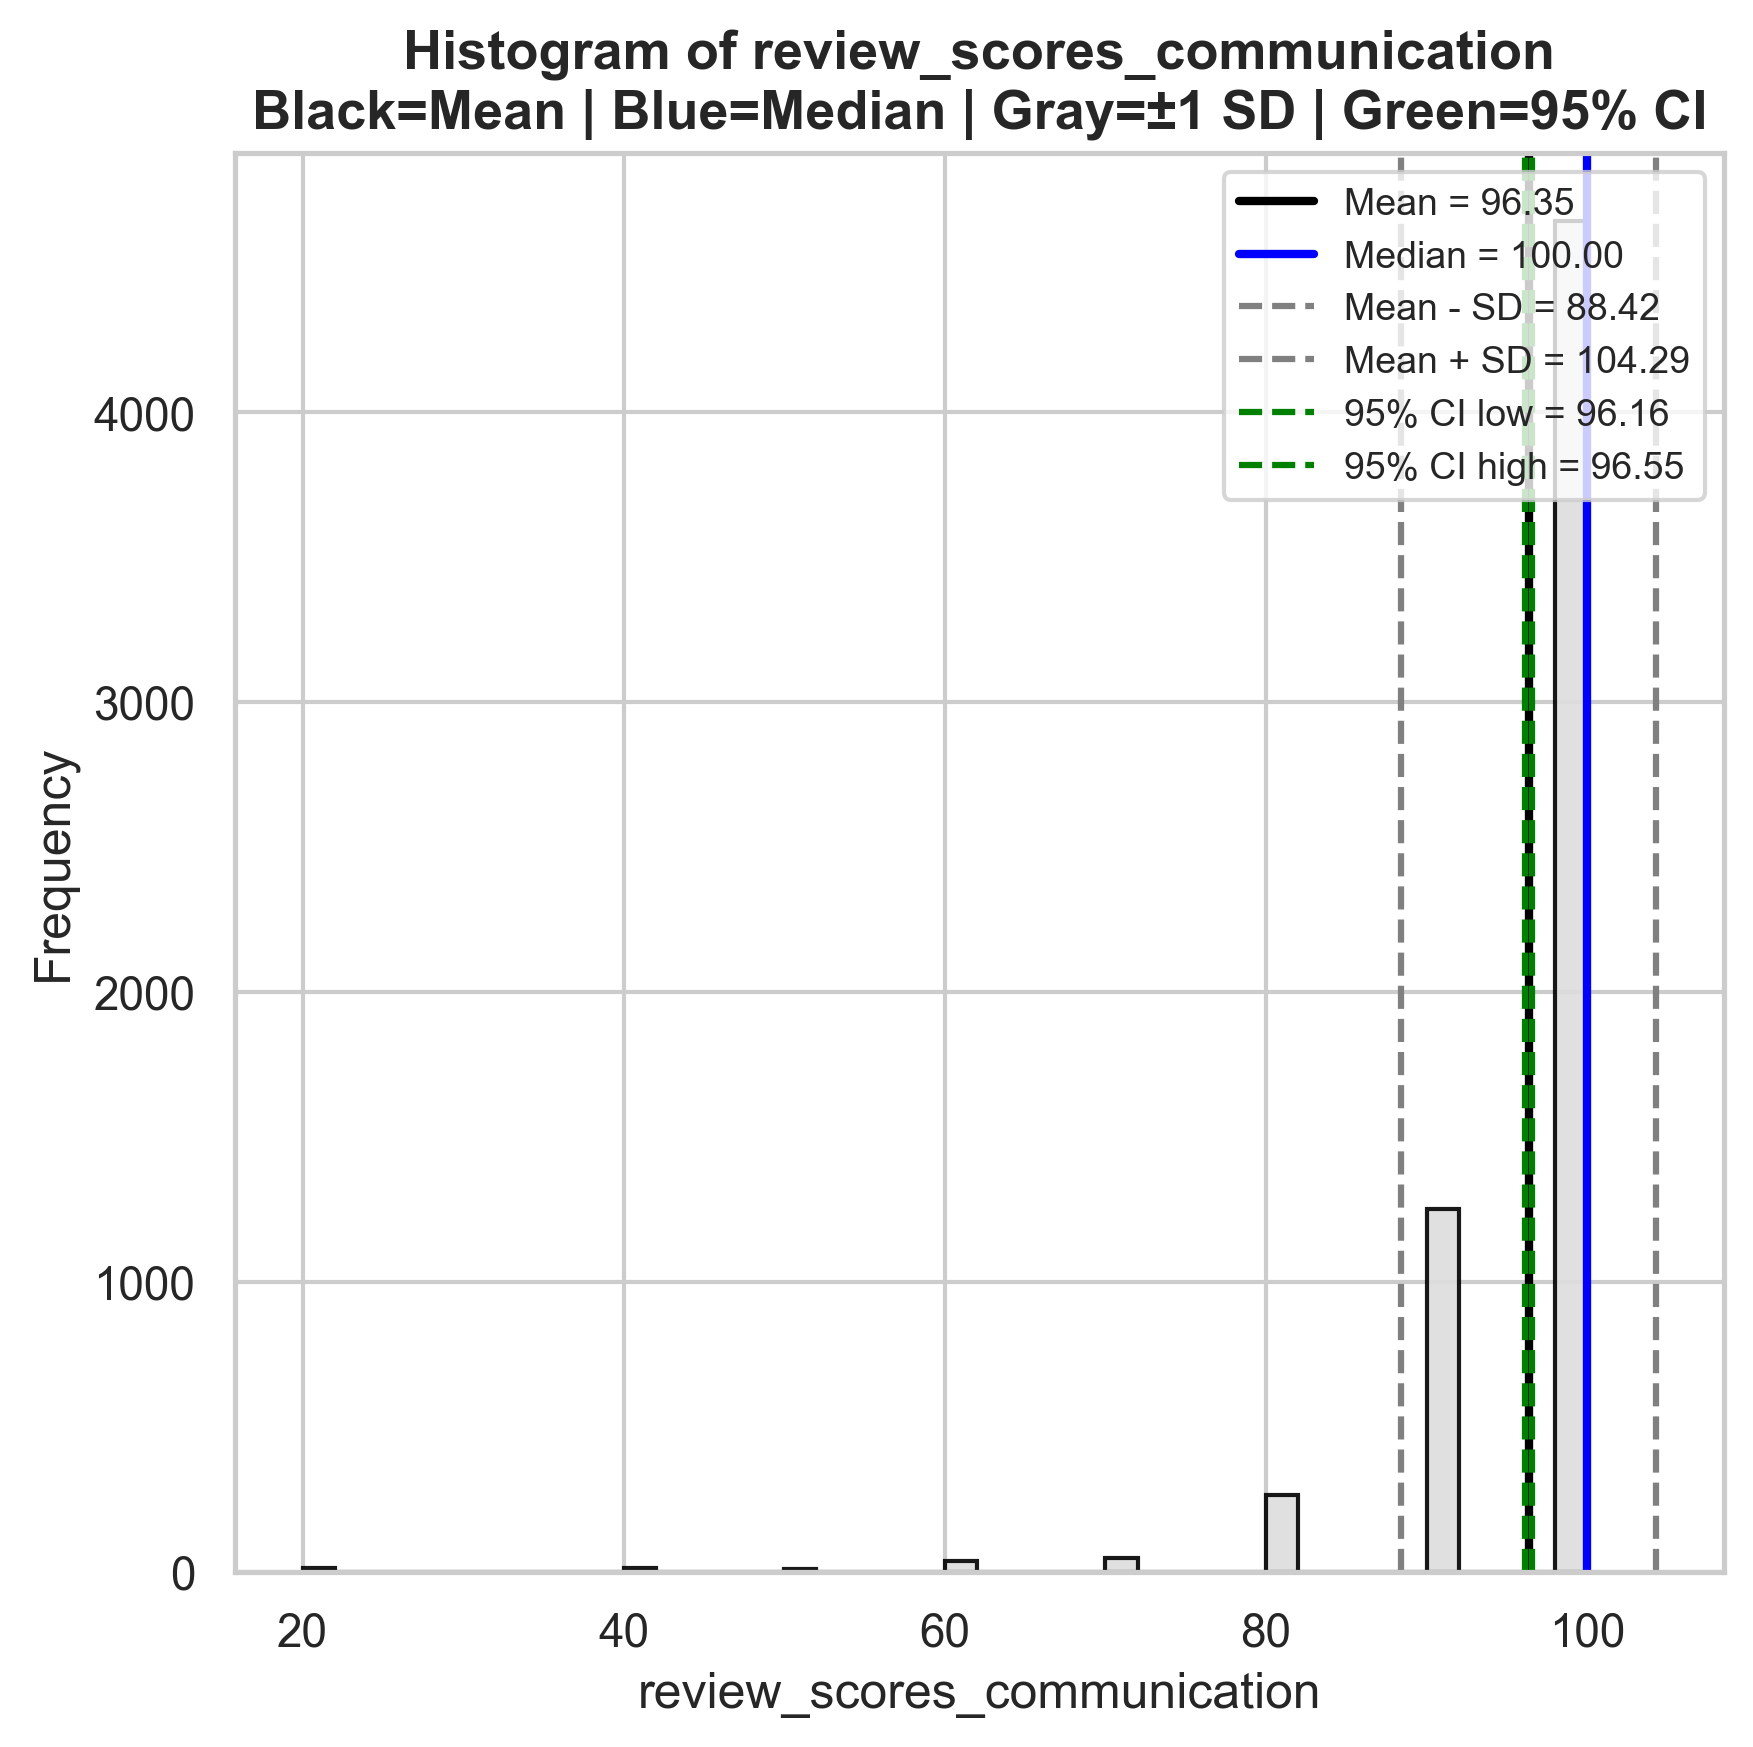

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_communication,6299,96.353389,100.0,7.932885,96.157448,96.549331,90.0,100.0,10.0,75.0,115.0,120,-3.959684,Highly skewed.



Unique values table
Number of non-nulls: 6299
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_communication,20.0,12,0.001905
1,review_scores_communication,40.0,13,0.002064
2,review_scores_communication,50.0,8,0.001270
3,review_scores_communication,60.0,38,0.006033
4,review_scores_communication,70.0,49,0.007779
5,review_scores_communication,80.0,266,0.042229
6,review_scores_communication,90.0,1252,0.198762
7,review_scores_communication,100.0,4661,0.739959



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_communication,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_communication,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_communication,numeric,city,categorical,Chi-square,77.000879,5.622456e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_communication,numeric,room_type,categorical,Chi-square,1.880313,5.976158e-01,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_communication,numeric,accommodates,numeric,Pearson,-0.027370,2.983902e-02,Significant,Statistically significant at p < 0.05.,
5,review_scores_communication,numeric,bathrooms,numeric,Pearson,-0.000628,9.603641e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_communication,numeric,bedrooms,numeric,Pearson,-0.007477,5.539610e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_communication,numeric,beds,numeric,Pearson,-0.016361,1.941807e-01,Not significant,Not statistically significant at p < 0.05.,
8,review_scores_communication,numeric,price,numeric,Pearson,-0.016678,1.890684e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_communication,numeric,minimum_nights,numeric,Pearson,-0.013818,2.728521e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-3.959684,Highly skewed.,Baseline.
1,Log Transformation,-7.386914,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-5.260699,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-1.116641,Highly skewed.,Improved; skewness decreased. Improved using l...


In [31]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_communication",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Communication*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 120 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 58,3% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.61), review_scores_accuracy (r=0.59), review_scores_cleanliness (r=0.50), review_scores_checkin (r=0.65), review_scores_location (r=0.32), review_scores_value (r=0.51)
    * weakly and significantly correlated with: number_of_reviews (r=0.11), reviews_per_month (r=0.11)
- Non parametric tests must be used

##### LOCATION

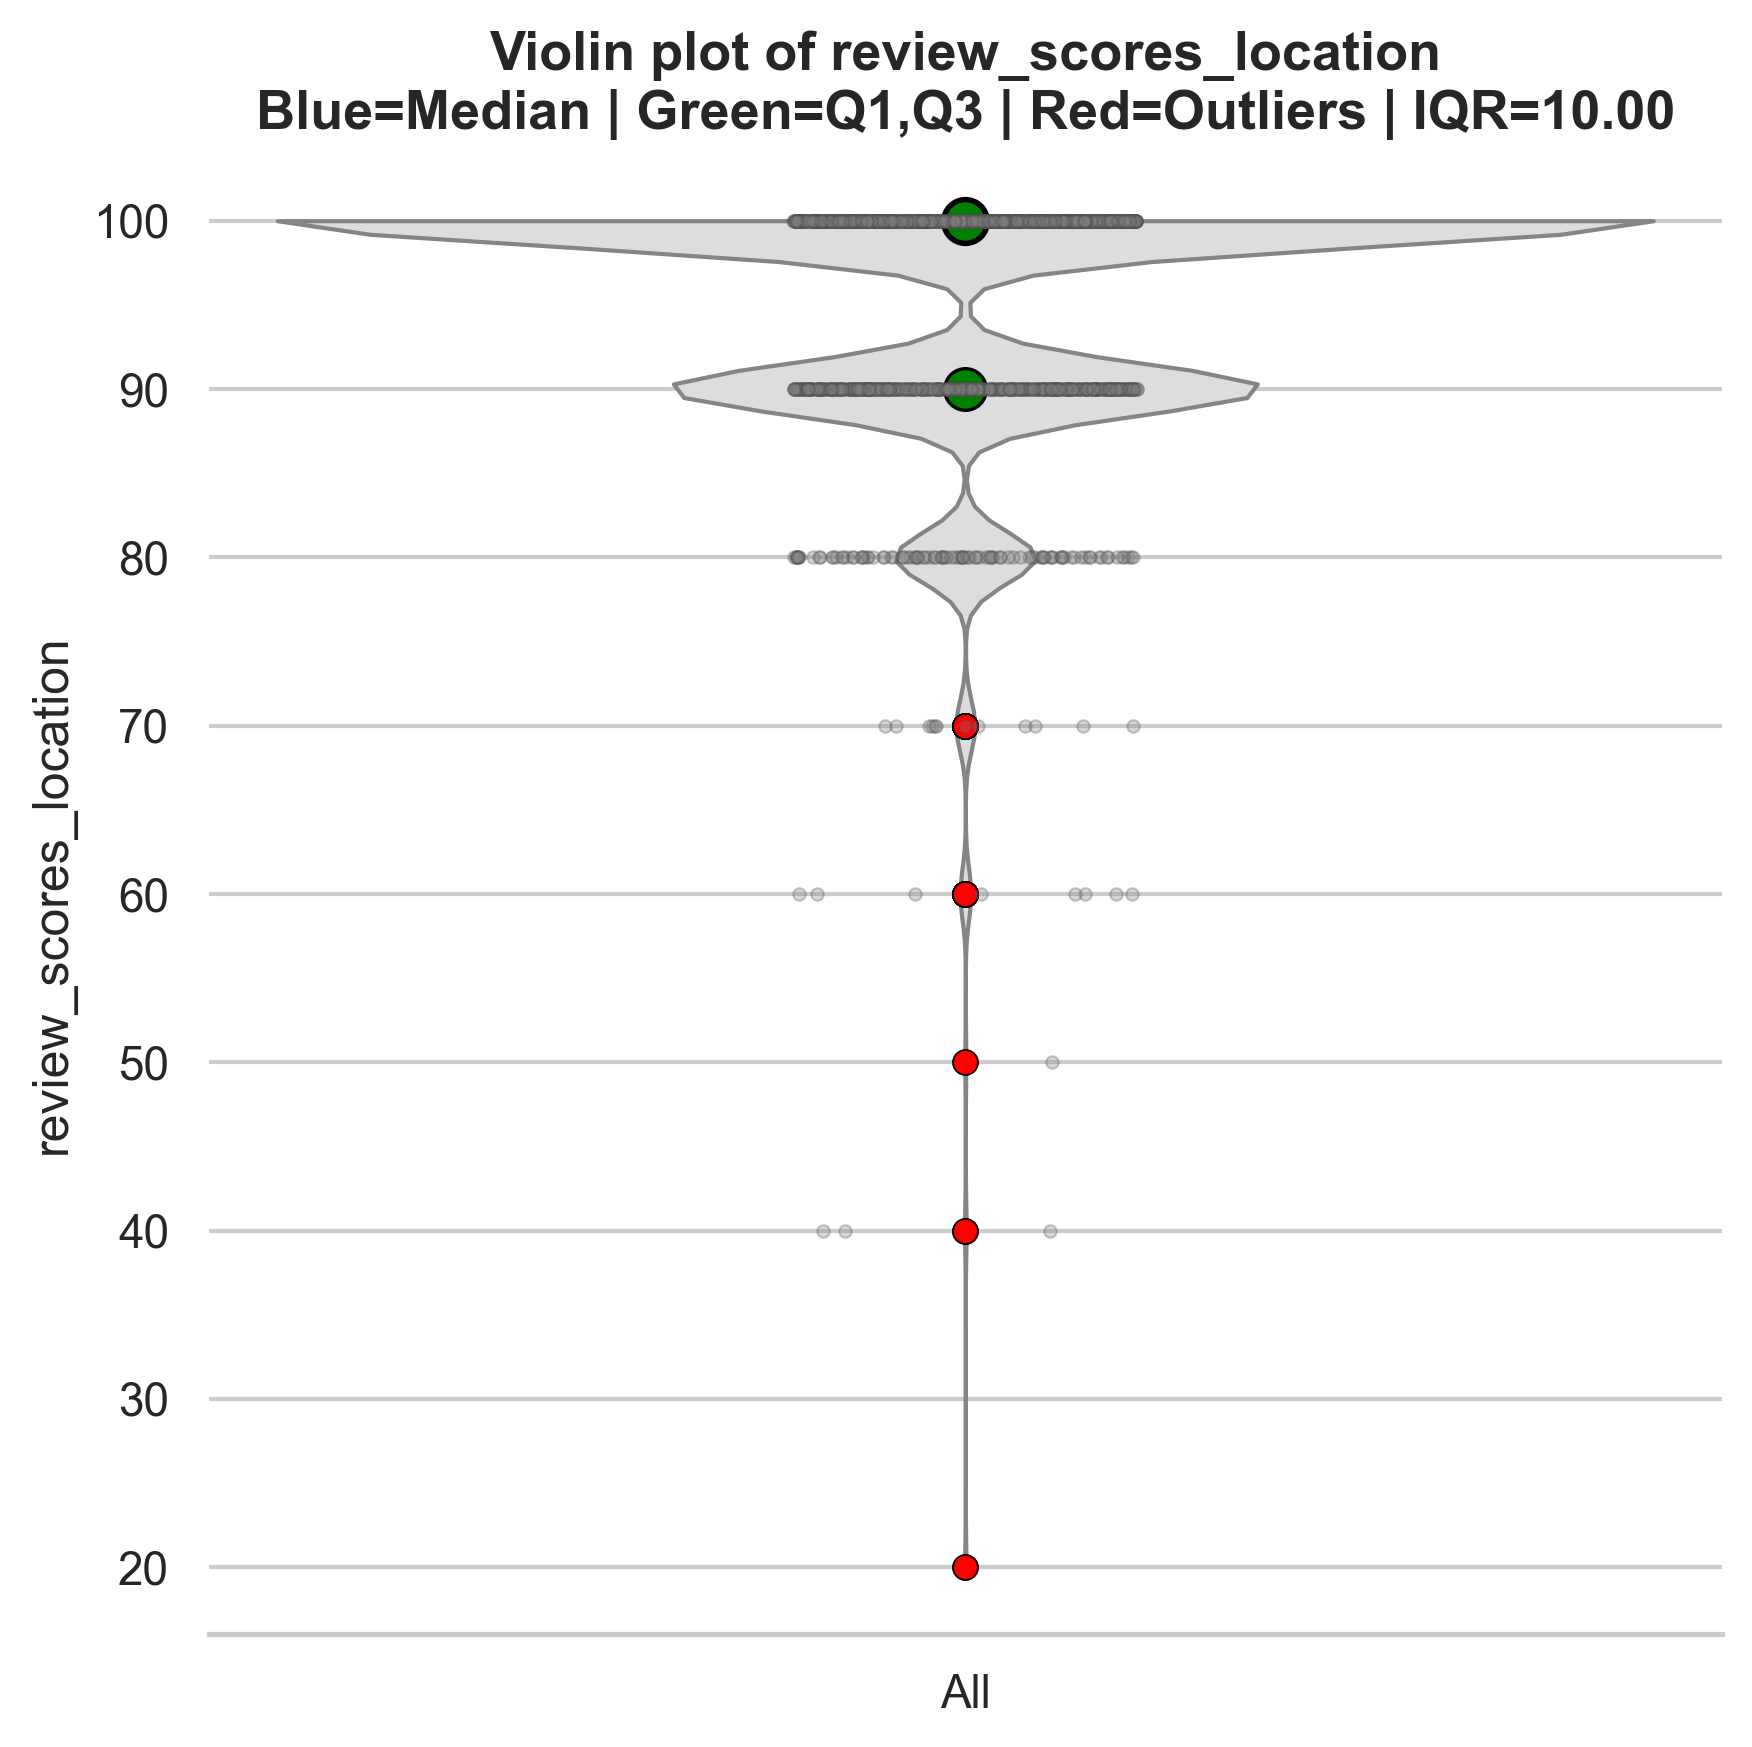

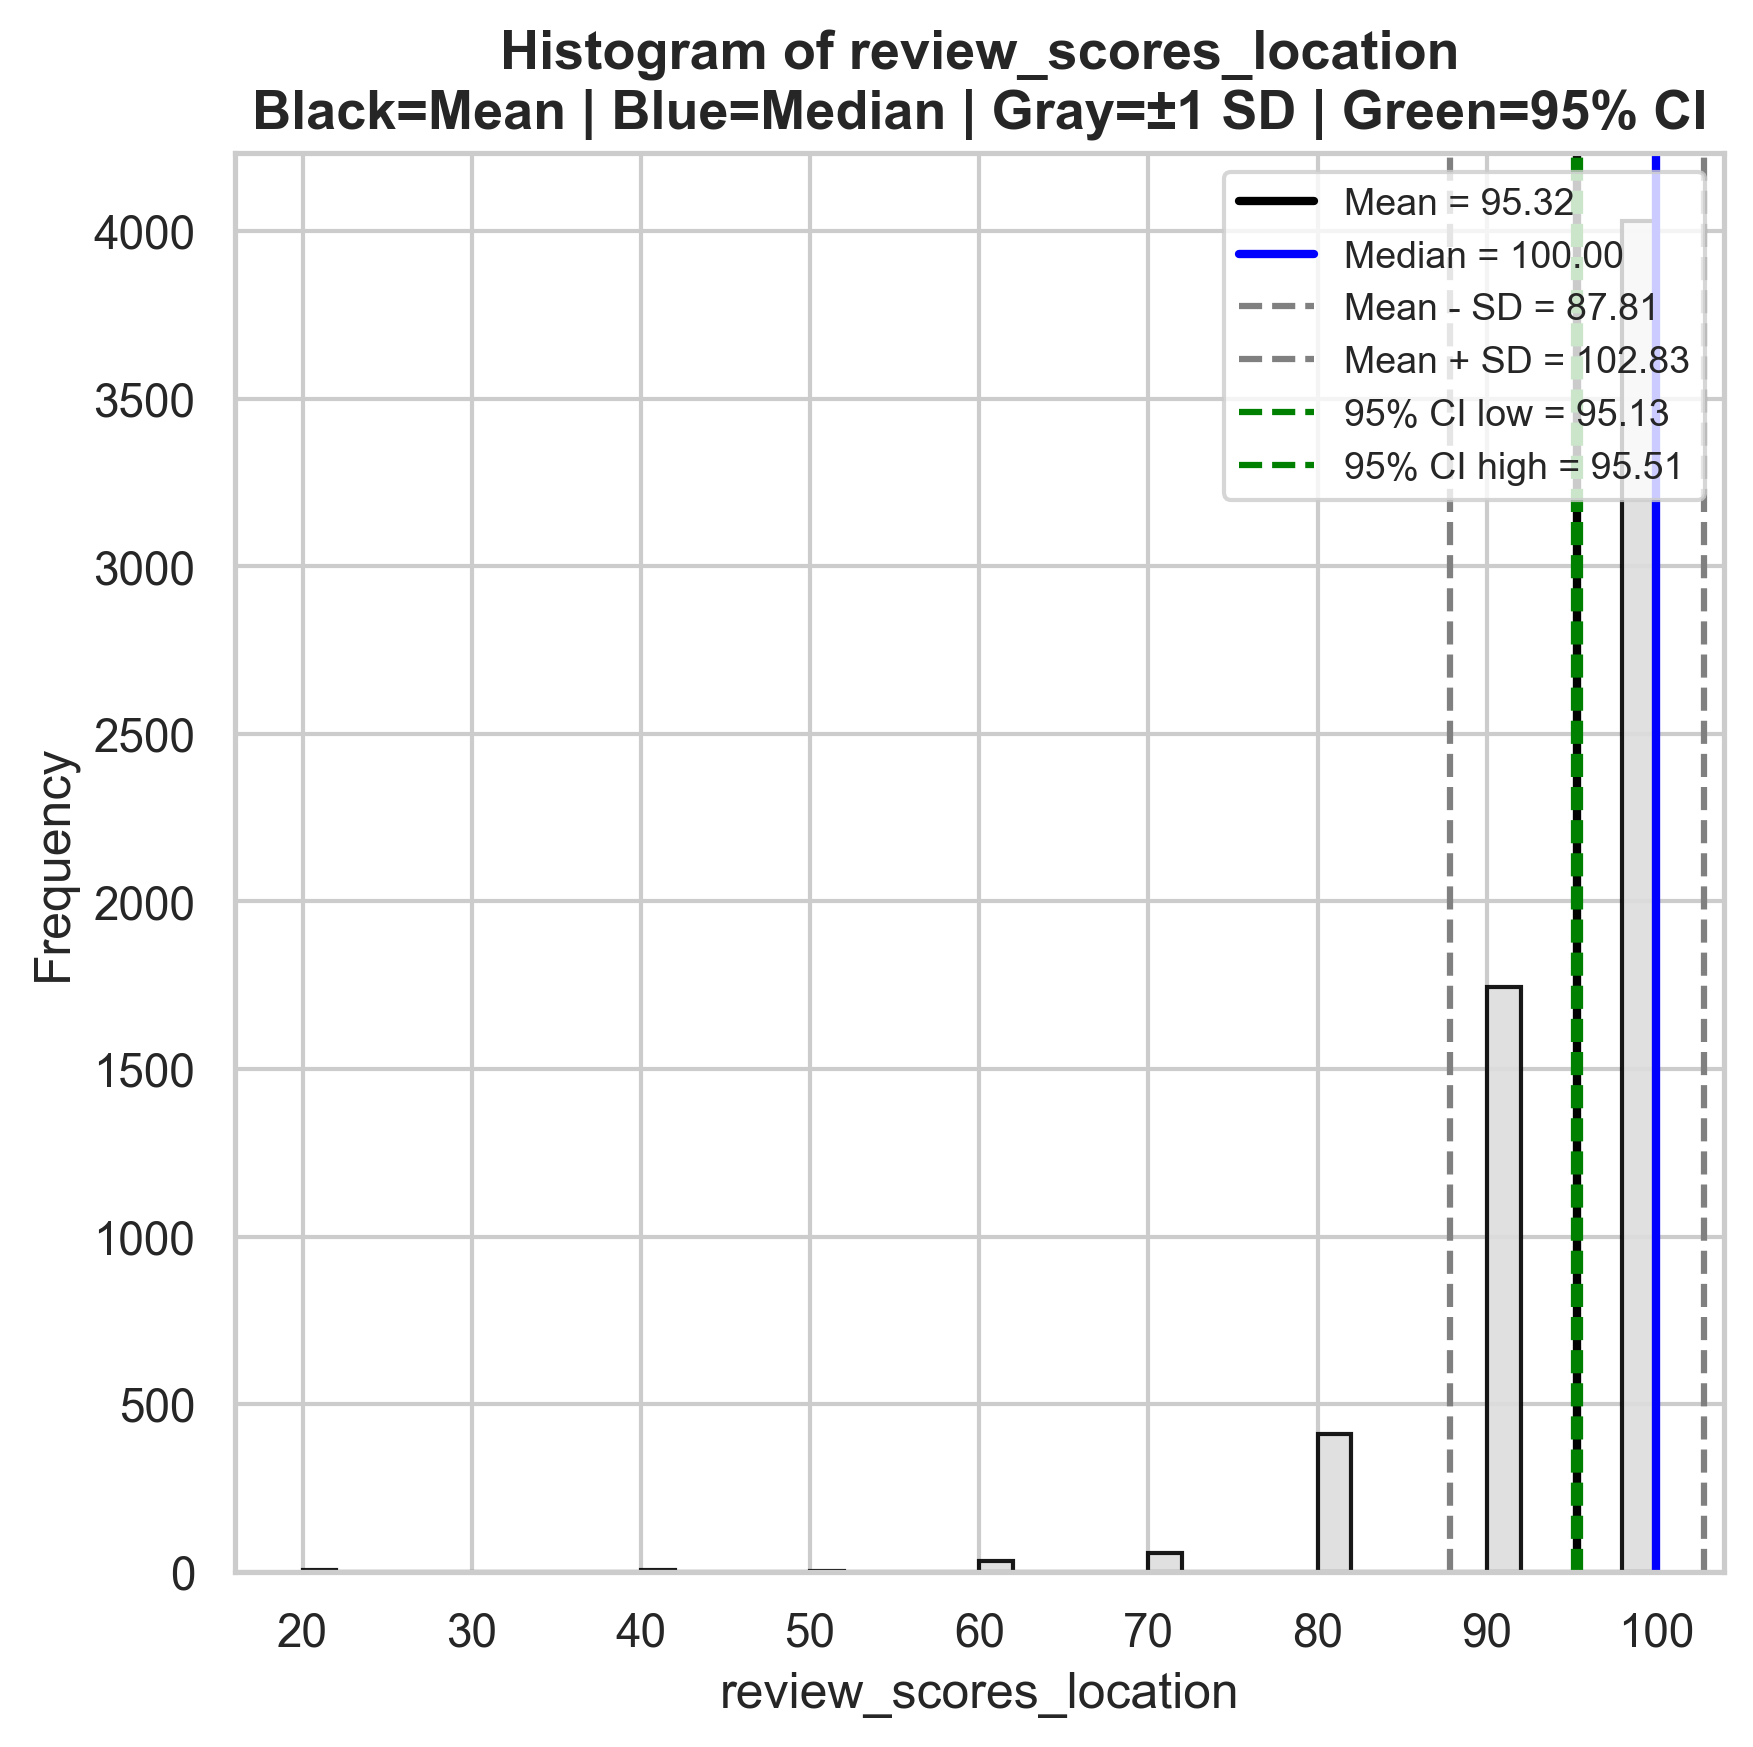

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_location,6289,95.320401,100.0,7.5072,95.134826,95.505975,90.0,100.0,10.0,75.0,115.0,100,-2.438555,Highly skewed.



Unique values table
Number of non-nulls: 6289
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_location,20.0,4,0.000636
1,review_scores_location,40.0,5,0.000795
2,review_scores_location,50.0,3,0.000477
3,review_scores_location,60.0,32,0.005088
4,review_scores_location,70.0,56,0.008904
5,review_scores_location,80.0,412,0.065511
6,review_scores_location,90.0,1746,0.277628
7,review_scores_location,100.0,4031,0.640960



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_location,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_location,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_location,numeric,city,categorical,Chi-square,80.302117,1.195302e-14,Significant,Statistically significant at p < 0.05.,
3,review_scores_location,numeric,room_type,categorical,Chi-square,7.416824,5.973456e-02,Not significant,Not statistically significant at p < 0.05.,
4,review_scores_location,numeric,accommodates,numeric,Pearson,-0.060383,1.651061e-06,Significant,Statistically significant at p < 0.05.,
5,review_scores_location,numeric,bathrooms,numeric,Pearson,-0.018373,1.461876e-01,Not significant,Not statistically significant at p < 0.05.,
6,review_scores_location,numeric,bedrooms,numeric,Pearson,-0.065568,2.090665e-07,Significant,Statistically significant at p < 0.05.,
7,review_scores_location,numeric,beds,numeric,Pearson,-0.072823,7.399620e-09,Significant,Statistically significant at p < 0.05.,
8,review_scores_location,numeric,price,numeric,Pearson,0.002032,8.729498e-01,Not significant,Not statistically significant at p < 0.05.,
9,review_scores_location,numeric,minimum_nights,numeric,Pearson,-0.020243,1.084495e-01,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.438555,Highly skewed.,Baseline.
1,Log Transformation,-5.043508,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.300724,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.664688,Moderately skewed.,Improved; skewness decreased. Improved using l...


In [33]:
analysis = analyze_single_field(
    df,
    target_col="review_scores_location",
    results_dir=RESULTS_DIR,
    show_in_notebook=True,
)

*Recommendations for Review Scores - Location*:
- mediana: 100.0
- IQR=10.0 [90.0; 100.0]
- 100 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 50,4% of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.40), review_scores_accuracy (r=0.39), review_scores_communication (r=0.32), review_scores_value (r=0.41)
    * weakly and significantly correlated with: number_of_reviews (r=0.13), reviews_per_month (r=0.13), review_scores_cleanliness (r=0.29), review_scores_checkin (r=0.29)
- Non parametric tests must be used

##### VALUE

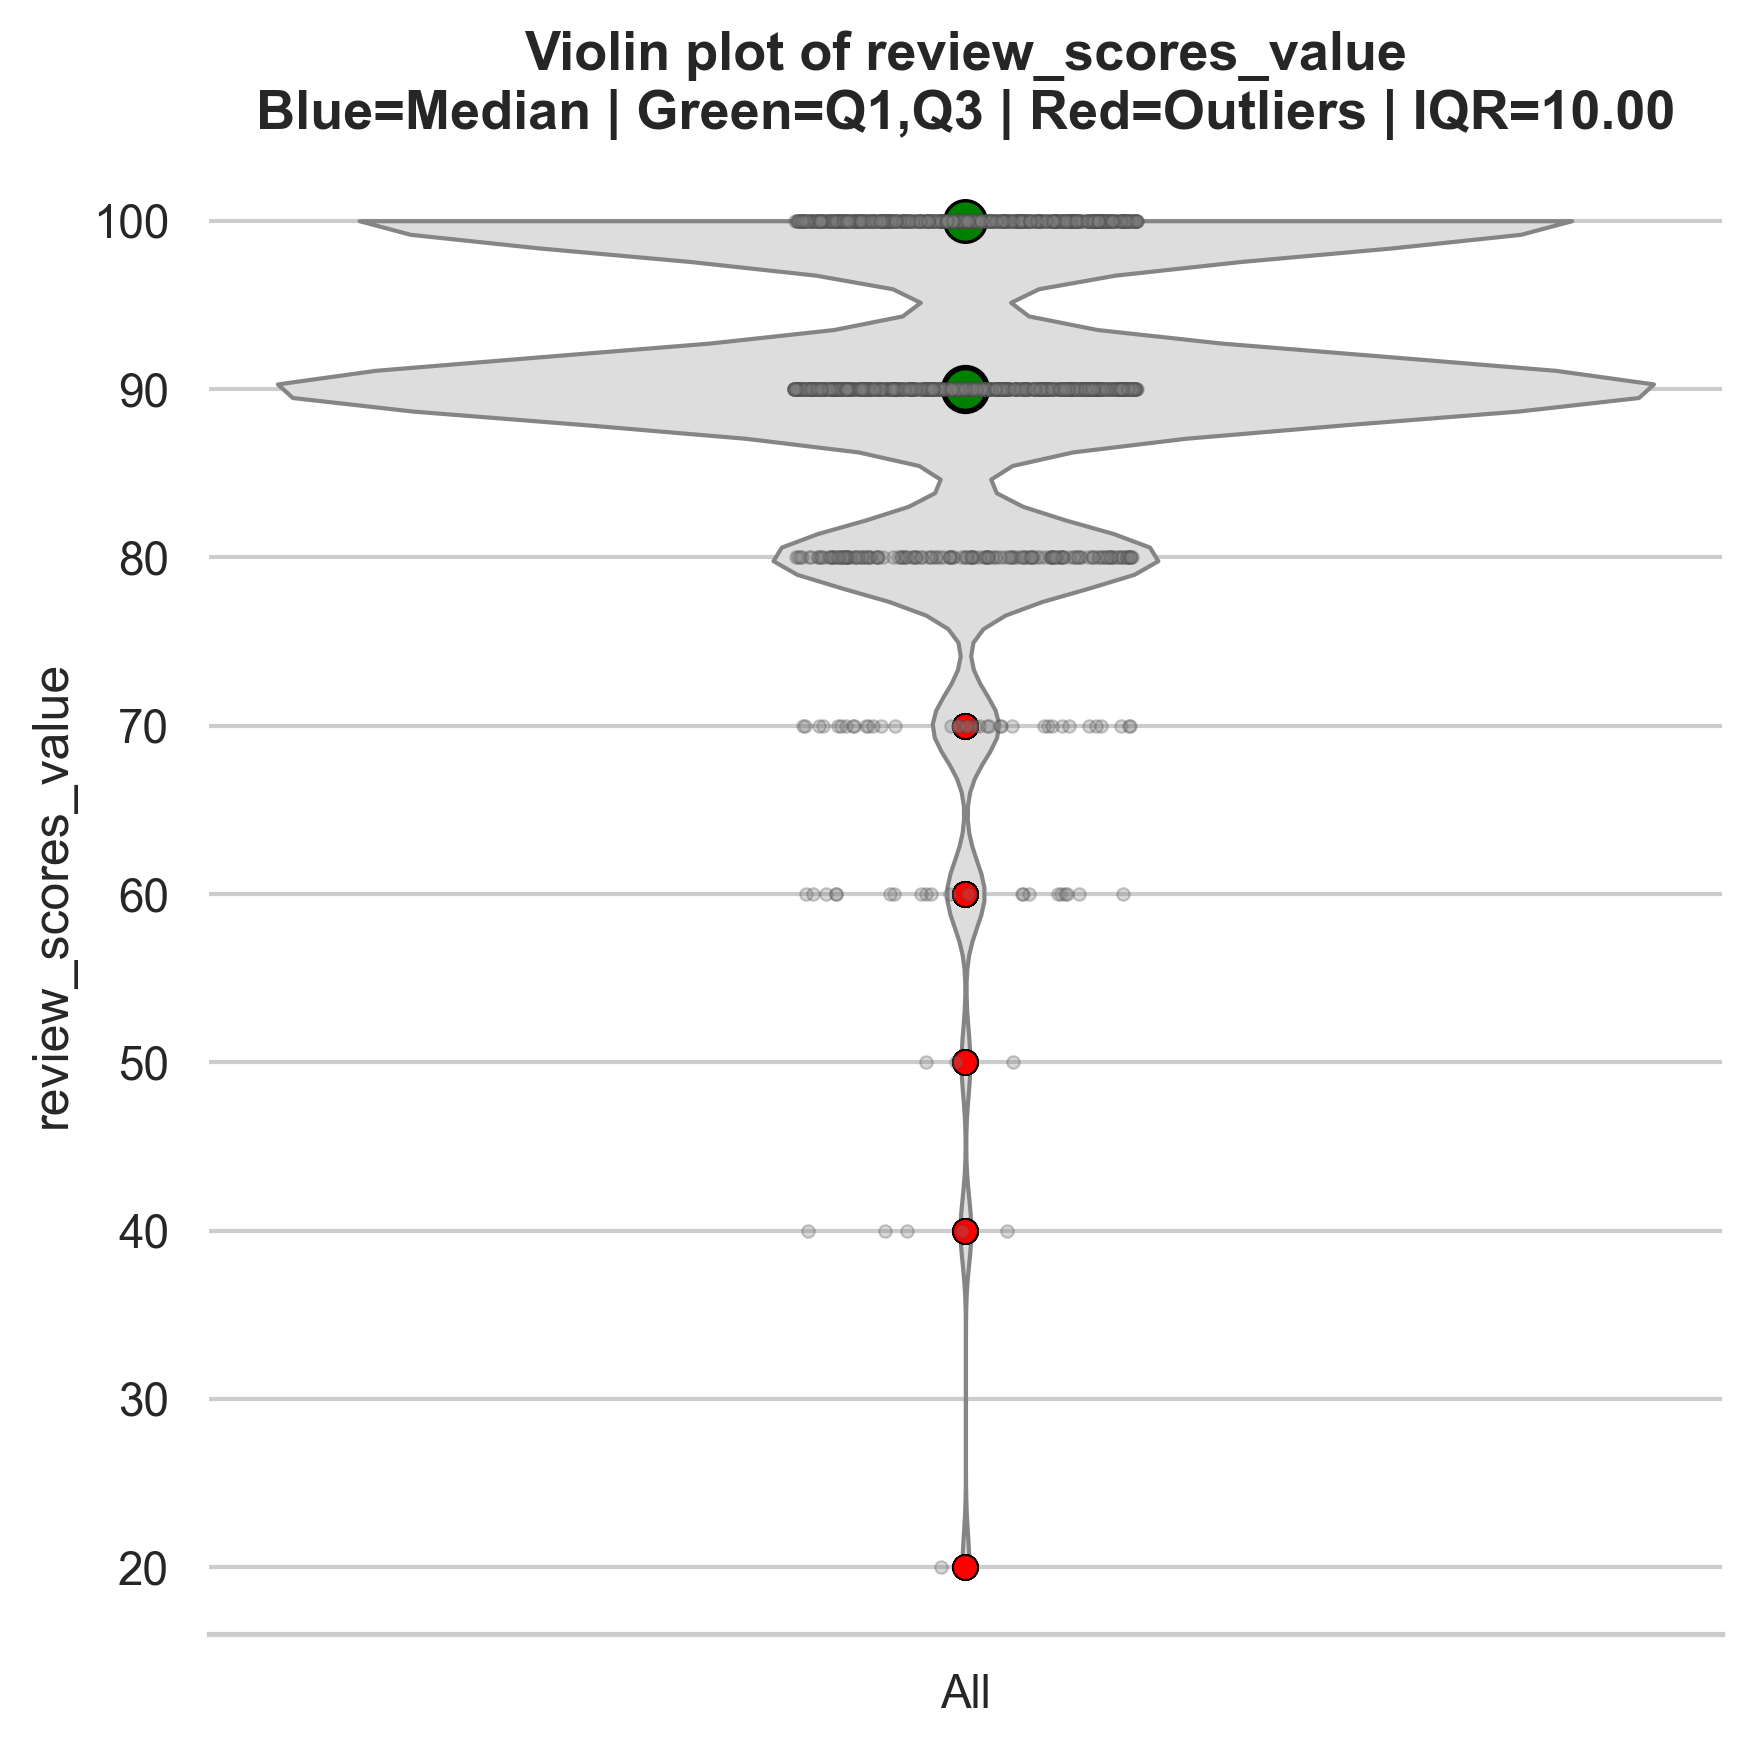

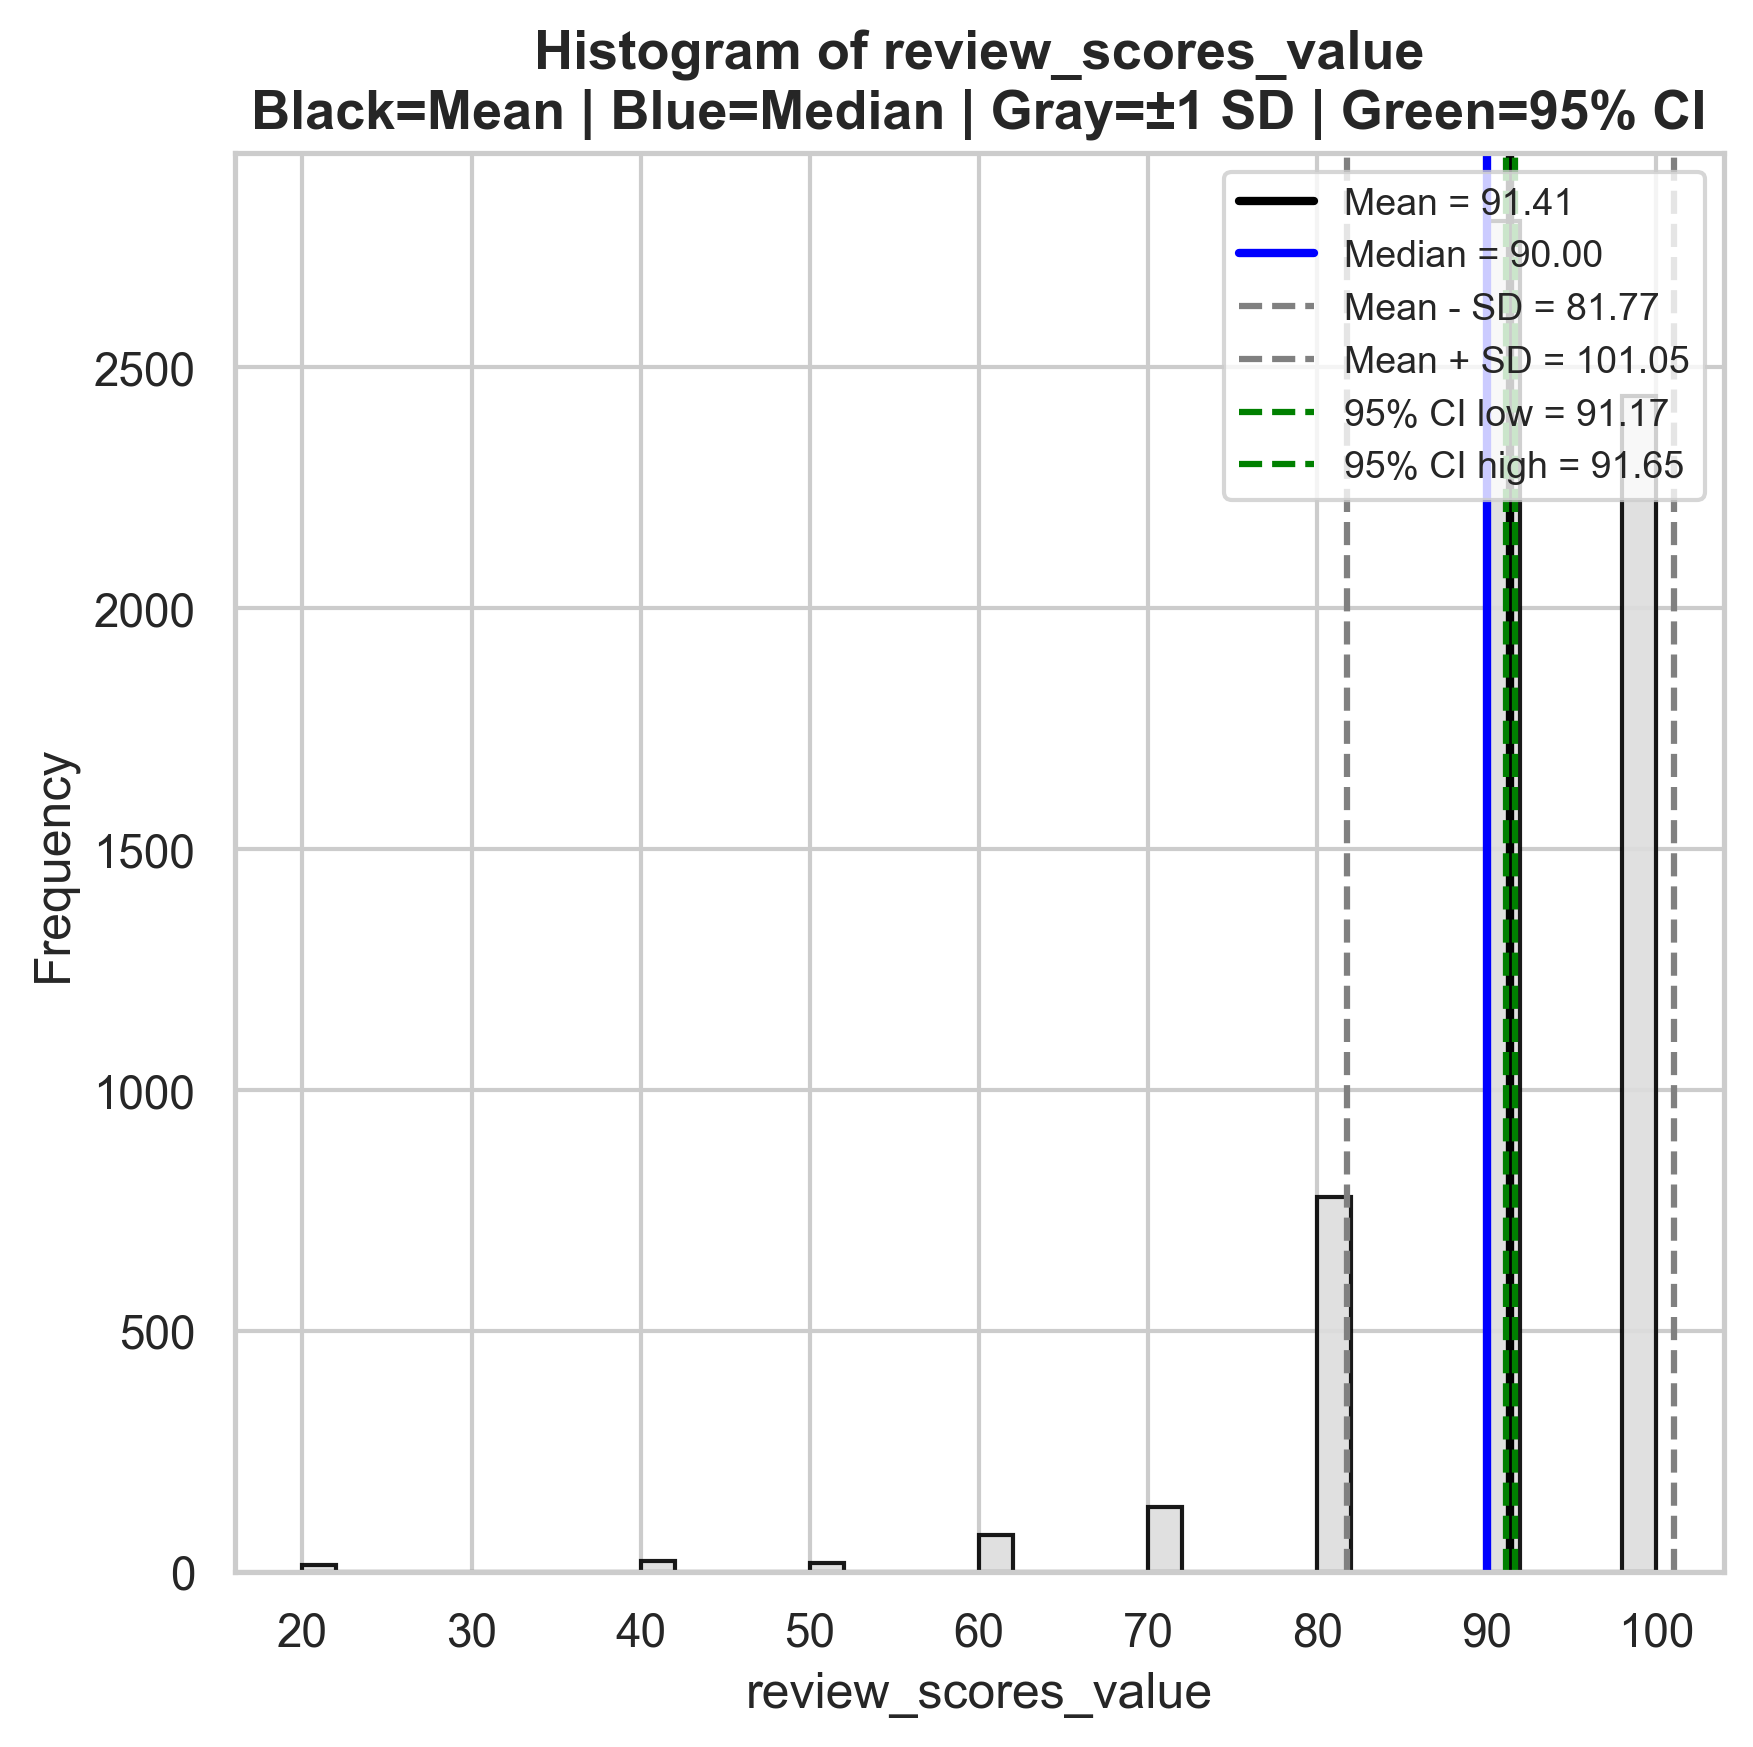

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,review_scores_value,6289,91.408809,90.0,9.636507,91.170599,91.647019,90.0,100.0,10.0,75.0,115.0,264,-2.249094,Highly skewed.



Unique values table
Number of non-nulls: 6289
Number of unique values: 8


,column,value,count,frequency_non_null
0,review_scores_value,20.0,14,0.002226
1,review_scores_value,40.0,22,0.003498
2,review_scores_value,50.0,18,0.002862
3,review_scores_value,60.0,76,0.012085
4,review_scores_value,70.0,134,0.021307
5,review_scores_value,80.0,779,0.123867
6,review_scores_value,90.0,2805,0.446017
7,review_scores_value,100.0,2441,0.388138



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,review_scores_value,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,review_scores_value,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,review_scores_value,numeric,city,categorical,Chi-square,71.643629,6.871885e-13,Significant,Statistically significant at p < 0.05.,
3,review_scores_value,numeric,room_type,categorical,Chi-square,23.450167,3.253363e-05,Significant,Statistically significant at p < 0.05.,
4,review_scores_value,numeric,accommodates,numeric,Pearson,-0.048302,1.271069e-04,Significant,Statistically significant at p < 0.05.,
5,review_scores_value,numeric,bathrooms,numeric,Pearson,0.032324,1.055647e-02,Significant,Statistically significant at p < 0.05.,
6,review_scores_value,numeric,bedrooms,numeric,Pearson,-0.009296,4.622166e-01,Not significant,Not statistically significant at p < 0.05.,
7,review_scores_value,numeric,beds,numeric,Pearson,-0.041158,1.095954e-03,Significant,Statistically significant at p < 0.05.,
8,review_scores_value,numeric,price,numeric,Pearson,-0.032701,1.006403e-02,Significant,Statistically significant at p < 0.05.,
9,review_scores_value,numeric,minimum_nights,numeric,Pearson,-0.021817,8.362508e-02,Not significant,Not statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,-2.249094,Highly skewed.,Baseline.
1,Log Transformation,-4.853298,Highly skewed.,Did not improve normality; skewness increased.
2,Square Root Transformation,-3.221896,Highly skewed.,Did not improve normality; skewness increased.
3,Box-Cox Transformation,-0.222761,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [34]:
analysis = analyze_single_field(
    df, target_col="review_scores_value", results_dir=RESULTS_DIR, show_in_notebook=True
)

*Recommendations for Review Scores - Value*:
- mediana: 90.0
- IQR=10.0 [90.0; 100.0]
- 264 outliers determined
- The dataset is very Skewed due to Max values accumulation:
    * Max=100 - 30,5 % of values
- no Transformation of the data should be applied, must be treated like categorical variable
- consider:
    * strongly and significantly associated with: city, room_type, is_instant_bookable
    * strongly and significantly correlated with: none found
    * medium and significantly correlated with: review_scores_rating (r=0.40), review_scores_accuracy (r=0.39), review_scores_communication (r=0.32), review_scores_value (r=0.41)
    * weakly and significantly correlated with: number_of_reviews (r=0.13), reviews_per_month (r=0.13), review_scores_cleanliness (r=0.29), review_scores_checkin (r=0.29)
- Non parametric tests must be used

##### Number of reviews per month

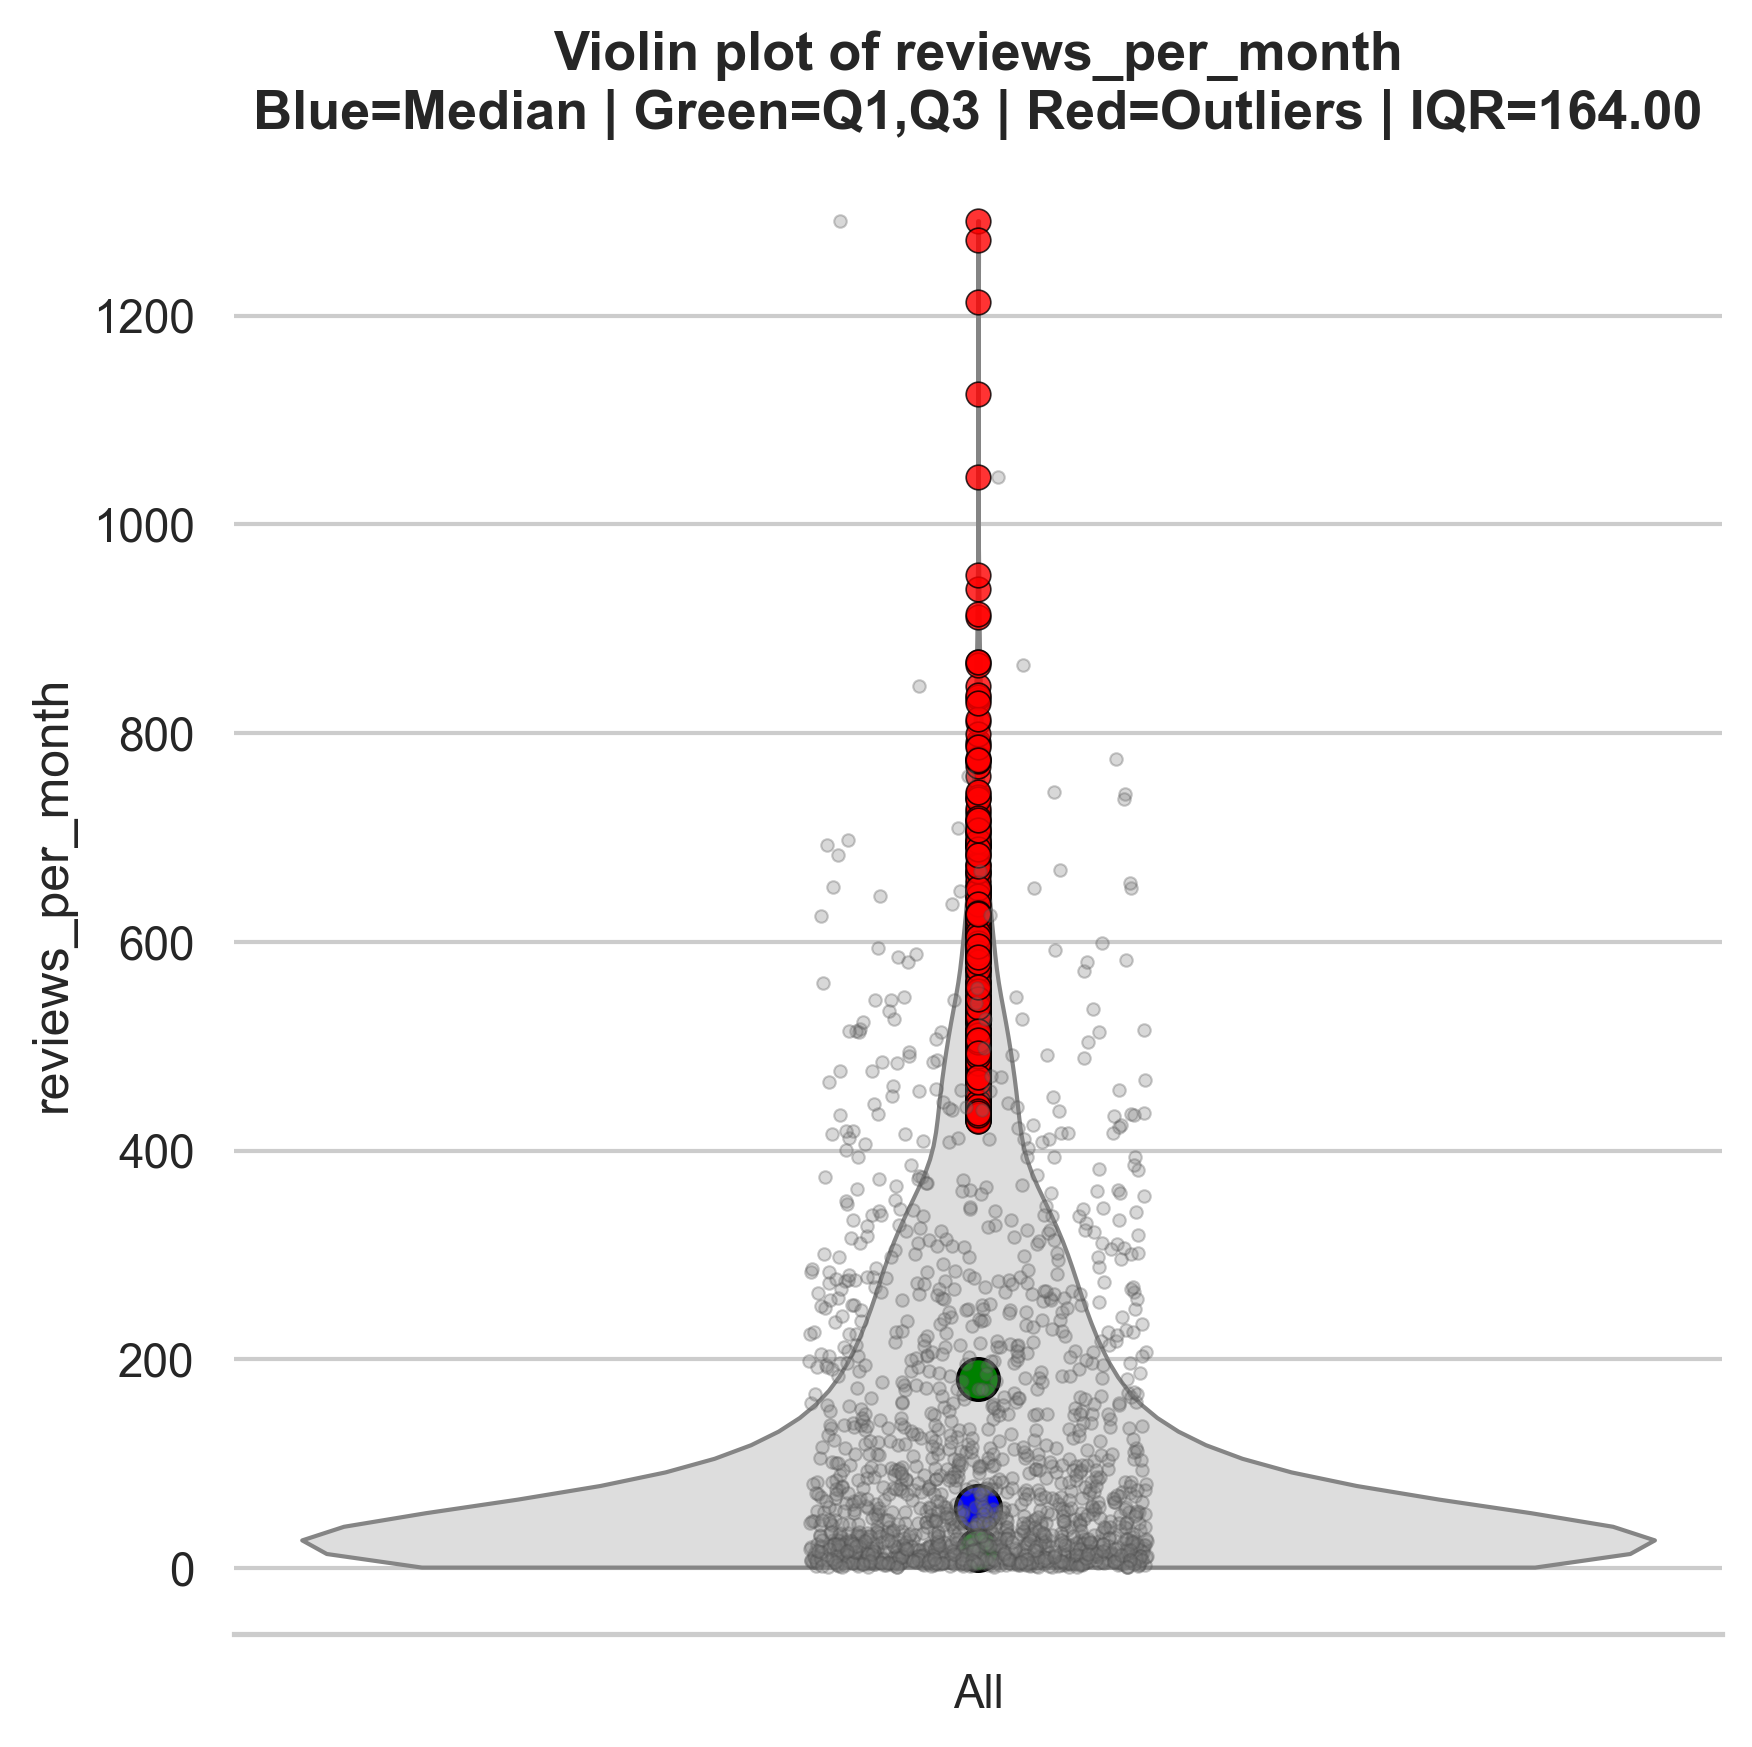

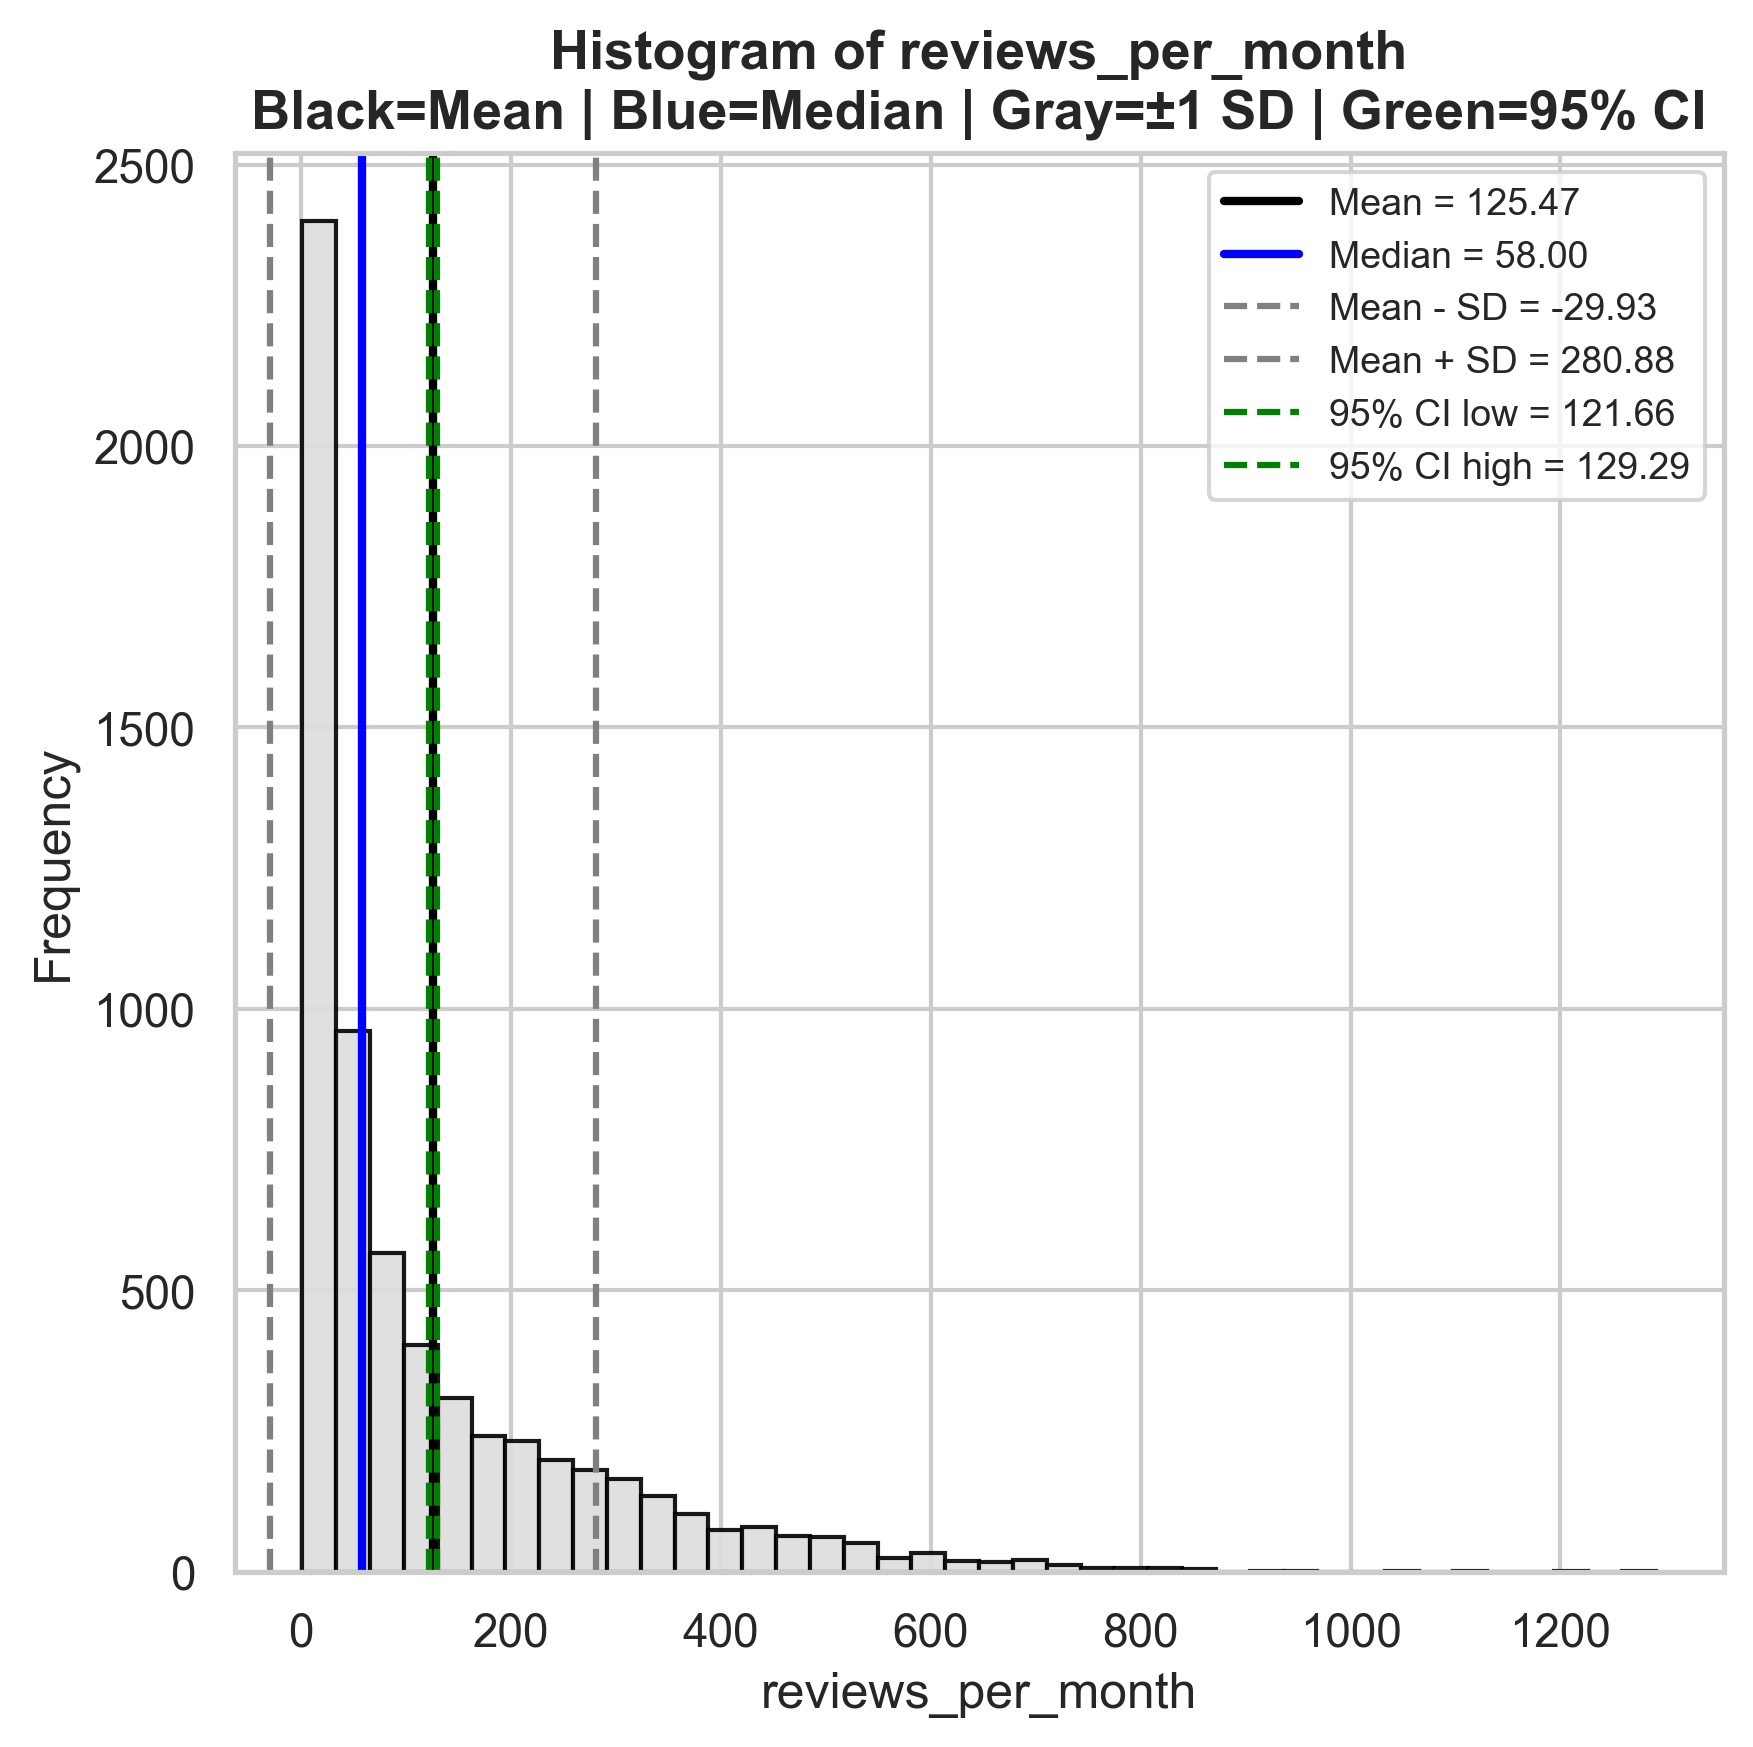

All files saved locally

Summary statistics


,column,n_non_null_numeric,mean,median,std,ci95_low,ci95_high,q1,q3,iqr,lower_fence,upper_fence,outlier_count,skewness,skewness_interpretation
0,reviews_per_month,6386,125.474945,58.0,155.403617,121.662733,129.287158,17.0,181.0,164.0,-229.0,427.0,397,1.955192,Highly skewed.



Unique values table
Number of non-nulls: 6386
Number of unique values: 600


,column,value,count,frequency_non_null
0,reviews_per_month,1.0,78,0.012214
1,reviews_per_month,2.0,83,0.012997
2,reviews_per_month,3.0,117,0.018321
3,reviews_per_month,4.0,110,0.017225
4,reviews_per_month,5.0,117,0.018321
...,...,...,...,...
595,reviews_per_month,1045.0,1,0.000157
596,reviews_per_month,1125.0,1,0.000157
597,reviews_per_month,1213.0,1,0.000157
598,reviews_per_month,1273.0,1,0.000157



Correlation table


,target_column,target_type,other_column,other_type,test,statistic,p_value,significance,significance_interpretation,note
0,reviews_per_month,numeric,neighbourhood_name,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
1,reviews_per_month,numeric,neighbourhood_district,categorical,None,NaN,NaN,Not available,P-value not available.,Too many categories or insufficient bins.
2,reviews_per_month,numeric,city,categorical,Chi-square,748.582001,1.318970e-139,Significant,Statistically significant at p < 0.05.,
3,reviews_per_month,numeric,room_type,categorical,Chi-square,81.190507,2.445528e-12,Significant,Statistically significant at p < 0.05.,
4,reviews_per_month,numeric,accommodates,numeric,Pearson,-0.152127,2.265764e-34,Significant,Statistically significant at p < 0.05.,
5,reviews_per_month,numeric,bathrooms,numeric,Pearson,-0.170913,7.475551e-43,Significant,Statistically significant at p < 0.05.,
6,reviews_per_month,numeric,bedrooms,numeric,Pearson,-0.196439,2.664428e-56,Significant,Statistically significant at p < 0.05.,
7,reviews_per_month,numeric,beds,numeric,Pearson,-0.184888,3.266146e-50,Significant,Statistically significant at p < 0.05.,
8,reviews_per_month,numeric,price,numeric,Pearson,-0.186146,3.797848e-50,Significant,Statistically significant at p < 0.05.,
9,reviews_per_month,numeric,minimum_nights,numeric,Pearson,-0.110955,5.978039e-19,Significant,Statistically significant at p < 0.05.,



Transformation skewness table


,method,skewness,interpretation,normality_improvement
0,Original,1.955192,Highly skewed.,Baseline.
1,Log Transformation,-0.355209,Approximately symmetric.,Improved strongly; distribution is closer to s...
2,Square Root Transformation,0.848889,Moderately skewed.,Improved; skewness decreased.
3,Box-Cox Transformation,-0.047270,Approximately symmetric.,Improved strongly; distribution is closer to s...


In [35]:
analysis = analyze_single_field(
    df, target_col="reviews_per_month", results_dir=RESULTS_DIR, show_in_notebook=True
)

#### **Categorical fields**

There is a hyerarchy determining Location of the accommodation:
- 'city' -> 'neighbourhood_district' -> 'neighbourhood_name'

##### Neighbourhood name

In [36]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["neighbourhood_name"].value_counts()
freqs = alojamentos_df["neighbourhood_name"].value_counts(normalize=True)
neighbourhood_table = pd.DataFrame({"count": counts, "frequency": freqs})
neighbourhood_table["percentage"] = (freqs * 100).round(2)
neighbourhood_table = neighbourhood_table.reset_index()
neighbourhood_table = neighbourhood_table.rename(
    columns={"index": "neighbourhood_name"}
)

print(neighbourhood_table.head())
print(neighbourhood_table.tail())

       neighbourhood_name  count  frequency  percentage
0  la Dreta de l'Eixample    278   0.034750        3.48
1                  Centro    262   0.032750        3.28
2             Embajadores    244   0.030500        3.05
3       Palma de Mallorca    169   0.021125        2.11
4             Universidad    164   0.020500        2.05
    neighbourhood_name  count  frequency  percentage
487           Queralbs      1   0.000125        0.01
488      LA VEGA BAIXA      1   0.000125        0.01
489   Huerta del Pilar      1   0.000125        0.01
490          Vilaju�ga      1   0.000125        0.01
491            MALILLA      1   0.000125        0.01


In [37]:
# Evaluation of associations with another parameters
chtest_neighb_name = chi_square_with_target(alojamentos_df, "neighbourhood_name")

In [38]:
print(chtest_neighb_name)

         target_column         compared_column  chi2_statistic        p_value  \
0   neighbourhood_name            apartment_id      3918676.28   0.000000e+00   
1   neighbourhood_name                    name      3911316.39   0.000000e+00   
2   neighbourhood_name             description      3889205.71  5.885241e-279   
3   neighbourhood_name                 host_id      3497564.70   0.000000e+00   
4   neighbourhood_name  neighbourhood_district       291383.27   0.000000e+00   
5   neighbourhood_name               room_type         3116.28  9.261575e-120   
6   neighbourhood_name            accommodates        17065.46   0.000000e+00   
7   neighbourhood_name          amenities_list      3893953.90  3.555280e-226   
8   neighbourhood_name          minimum_nights        25393.32  3.280194e-156   
9   neighbourhood_name          maximum_nights        61760.58   1.000000e+00   
10  neighbourhood_name        has_availability            0.00   1.000000e+00   
11  neighbourhood_name      

##### Neighbourhood district

In [39]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["neighbourhood_district"].value_counts()
freqs = alojamentos_df["neighbourhood_district"].value_counts(normalize=True)
neighbourhood_distr_table = pd.DataFrame({"count": counts, "frequency": freqs})
neighbourhood_distr_table["percentage"] = (freqs * 100).round(2)
neighbourhood_distr_table = neighbourhood_distr_table.reset_index()
neighbourhood_distr_table = neighbourhood_distr_table.rename(
    columns={"index": "neighbourhood_district"}
)

print(neighbourhood_distr_table.head())
print(neighbourhood_distr_table.tail())

  neighbourhood_district  count  frequency  percentage
0                 Centro    871   0.179181       17.92
1               Eixample    860   0.176918       17.69
2           Ciutat Vella    488   0.100391       10.04
3          Casco Antiguo    301   0.061921        6.19
4             Sant Mart�    256   0.052664        5.27
   neighbourhood_district  count  frequency  percentage
56          Cerro - Amate      3   0.000617        0.06
57       Macarena - Norte      2   0.000411        0.04
58      POBLATS DE L'OEST      1   0.000206        0.02
59              Vic�lvaro      1   0.000206        0.02
60       POBLATS DEL NORD      1   0.000206        0.02


In [40]:
# Evaluation of associations with another parameters
chtest_neighb_distr = chi_square_with_target(alojamentos_df, "neighbourhood_district")

print(chtest_neighb_distr)

             target_column      compared_column  chi2_statistic       p_value  \
0   neighbourhood_district         apartment_id       291229.86  2.986398e-49   
1   neighbourhood_district                 name       290814.71  1.108081e-35   
2   neighbourhood_district          description       288944.75  7.543559e-26   
3   neighbourhood_district              host_id       275096.58  0.000000e+00   
4   neighbourhood_district   neighbourhood_name       291383.27  0.000000e+00   
5   neighbourhood_district            room_type          724.09  2.511361e-66   
6   neighbourhood_district         accommodates         1187.44  3.217698e-10   
7   neighbourhood_district       amenities_list       289318.13  9.783617e-21   
8   neighbourhood_district       minimum_nights         3347.89  3.131112e-49   
9   neighbourhood_district       maximum_nights         7306.10  1.879659e-01   
10  neighbourhood_district     has_availability            0.00  1.000000e+00   
11  neighbourhood_district  

##### City

In [41]:
# Number of objects and their quota for each city

counts = alojamentos_df["city"].value_counts()
freqs = alojamentos_df["city"].value_counts(normalize=True)
city_table = pd.DataFrame({"count": counts, "frequency": freqs})
city_table["percentage"] = (freqs * 100).round(2)
city_table = city_table.reset_index()
city_table = city_table.rename(columns={"index": "neighbourhood_name"})

print(city_table)

        city  count  frequency  percentage
0  barcelona   2358   0.294750       29.48
1     madrid   1703   0.212875       21.29
2   mallorca   1318   0.164750       16.48
3     girona   1242   0.155250       15.52
4    sevilla    428   0.053500        5.35
5     malaga    408   0.051000        5.10
6   valencia    372   0.046500        4.65
7    menorca    171   0.021375        2.14


In [42]:
# Evaluation of associations with another parameters
chtest_city = chi_square_with_target(alojamentos_df, "city")

print(chtest_city)

   target_column         compared_column  chi2_statistic        p_value  \
0           city            apartment_id        56000.00   4.397835e-11   
1           city                    name        55906.73   4.098976e-09   
2           city             description        55622.00   4.289665e-06   
3           city                 host_id        54598.84   0.000000e+00   
4           city      neighbourhood_name        55979.53   0.000000e+00   
5           city  neighbourhood_district        14583.00   0.000000e+00   
6           city               room_type         1403.64  1.564260e-284   
7           city            accommodates         2323.92   0.000000e+00   
8           city          amenities_list        55585.77   2.609265e-05   
9           city          minimum_nights         2850.02   0.000000e+00   
10          city          maximum_nights         1947.68   6.349050e-73   
11          city        has_availability            0.00   1.000000e+00   
12          city         

##### Type of the accommodation

In [43]:
# Number of objects and their quota for each type of the rooms

counts = alojamentos_df["room_type"].value_counts()
freqs = alojamentos_df["room_type"].value_counts(normalize=True)
room_type_table = pd.DataFrame({"count": counts, "frequency": freqs})
room_type_table["percentage"] = (freqs * 100).round(2)
room_type_table = room_type_table.reset_index()
room_type_table = room_type_table.rename(columns={"index": "room_type"})

print(room_type_table)

         room_type  count  frequency  percentage
0  Entire home/apt   5680   0.710000       71.00
1     Private room   2215   0.276875       27.69
2       Hotel room     54   0.006750        0.68
3      Shared room     51   0.006375        0.64


In [44]:
# Evaluation of associations with another parameters
room_type_name = chi_square_with_target(alojamentos_df, "room_type")

print(room_type_name)

   target_column         compared_column  chi2_statistic        p_value  \
0      room_type            apartment_id        23920.20   5.099795e-05   
1      room_type                    name        23908.72   1.984048e-04   
2      room_type             description        23761.20   5.165135e-03   
3      room_type                 host_id        22111.70  4.848553e-107   
4      room_type      neighbourhood_name         3116.28  9.261575e-120   
5      room_type  neighbourhood_district          724.09   2.511361e-66   
6      room_type            accommodates         4736.78   0.000000e+00   
7      room_type          amenities_list        23943.14   6.874222e-04   
8      room_type          minimum_nights          666.96   9.433557e-77   
9      room_type          maximum_nights          964.15   3.939912e-48   
10     room_type        has_availability            0.00   1.000000e+00   
11     room_type         availability_30          200.51   2.134505e-10   
12     room_type         

##### Availability condition

In [45]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["has_availability"].value_counts()
freqs = alojamentos_df["has_availability"].value_counts(normalize=True)
availab_cond_table = pd.DataFrame({"count": counts, "frequency": freqs})
availab_cond_table["percentage"] = (freqs * 100).round(2)
availab_cond_table = availab_cond_table.reset_index()
availab_cond_table = availab_cond_table.rename(columns={"index": "has_availability"})

print(availab_cond_table.head())
print(availab_cond_table.tail())

  has_availability  count  frequency  percentage
0        VERDADERO   7450        1.0       100.0
  has_availability  count  frequency  percentage
0        VERDADERO   7450        1.0       100.0


##### Instant booking condition

In [46]:
# Number of objects and their quota for each neighbourhood

counts = alojamentos_df["is_instant_bookable"].value_counts()
freqs = alojamentos_df["is_instant_bookable"].value_counts(normalize=True)
instant_book_table = pd.DataFrame({"count": counts, "frequency": freqs})
instant_book_table["percentage"] = (freqs * 100).round(2)
instant_book_table = instant_book_table.reset_index()
instant_book_table = instant_book_table.rename(columns={"index": "is_instant_bookable"})

print(instant_book_table)

  is_instant_bookable  count  frequency  percentage
0           VERDADERO   4439   0.554875       55.49
1               FALSO   3561   0.445125       44.51


In [47]:
# Evaluation of associations with another parameters
chtest_instant_book = chi_square_with_target(alojamentos_df, "is_instant_bookable")

print(chtest_instant_book)

          target_column         compared_column  chi2_statistic       p_value  \
0   is_instant_bookable            apartment_id         7952.09  1.880261e-02   
1   is_instant_bookable                    name         7951.11  2.851382e-02   
2   is_instant_bookable             description         7919.68  6.963771e-02   
3   is_instant_bookable                 host_id         7553.22  1.570583e-45   
4   is_instant_bookable      neighbourhood_name          801.61  2.584496e-17   
5   is_instant_bookable  neighbourhood_district          193.55  5.801868e-16   
6   is_instant_bookable               room_type          207.91  8.237456e-45   
7   is_instant_bookable            accommodates          178.36  6.507548e-28   
8   is_instant_bookable          amenities_list         7957.82  4.766815e-02   
9   is_instant_bookable          minimum_nights          400.84  4.507950e-61   
10  is_instant_bookable          maximum_nights          282.58  1.198793e-12   
11  is_instant_bookable     

#### Date fields

##### First review date

In [48]:
frd_df = alojamentos_df[["apartment_id", "host_id", "first_review_date"]].copy()
frd_df["first_review_date"] = pd.to_datetime(frd_df["first_review_date"], dayfirst=True)
frd_df["year"] = frd_df["first_review_date"].dt.year.astype("Int64")
frd_df["month"] = frd_df["first_review_date"].dt.month.astype("Int64")
frd_df.head(3)

,apartment_id,host_id,first_review_date,year,month
0,11964,45553,2010-01-02,2010,1
1,21853,83531,2014-10-10,2014,10
2,32347,139939,2011-01-05,2011,1


In [49]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = frd_df["first_review_date"].value_counts()
freqs = frd_df["first_review_date"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "first_review_date"})

print(frd_table.head())
print(frd_table.tail())

  first_review_date  count  frequency  percentage
0        2018-04-01     27   0.004228        0.42
1        2017-06-25     21   0.003288        0.33
2        2017-04-16     20   0.003132        0.31
3        2018-07-08     18   0.002819        0.28
4        2017-08-19     18   0.002819        0.28
     first_review_date  count  frequency  percentage
1933        2019-01-23      1   0.000157        0.02
1934        2019-05-15      1   0.000157        0.02
1935        2019-02-18      1   0.000157        0.02
1936        2019-02-08      1   0.000157        0.02
1937        2019-04-05      1   0.000157        0.02


In [50]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = frd_df["month"].value_counts()
freqs = frd_df["month"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "month"})

print(frd_table.sort_values("month"))

    month  count  frequency  percentage
8       1    381   0.059662        5.97
9       2    352   0.055121        5.51
6       3    488   0.076417        7.64
4       4    609   0.095365        9.54
3       5    617   0.096618        9.66
2       6    665   0.104134       10.41
0       7    898    0.14062       14.06
1       8    857     0.1342       13.42
5       9    545   0.085343        8.53
7      10    411    0.06436        6.44
11     11    262   0.041027         4.1
10     12    301   0.047134        4.71


In [51]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = frd_df["year"].value_counts()
freqs = frd_df["year"].value_counts(normalize=True)
frd_table = pd.DataFrame({"count": counts, "frequency": freqs})
frd_table["percentage"] = (freqs * 100).round(2)
frd_table = frd_table.reset_index()
frd_table = frd_table.rename(columns={"index": "year"})

print(frd_table.sort_values("year"))

    year  count  frequency  percentage
10  2010      1   0.000157        0.02
9   2011     23   0.003602        0.36
7   2012     76   0.011901        1.19
6   2013    226    0.03539        3.54
5   2014    375   0.058722        5.87
3   2015    699   0.109458       10.95
2   2016   1232   0.192922       19.29
1   2017   1590   0.248982        24.9
0   2018   1649   0.258221       25.82
4   2019    489   0.076574        7.66
8   2020     26   0.004071        0.41


##### Last review date

In [52]:
lrd_df = alojamentos_df[["apartment_id", "host_id", "last_review_date"]].copy()
lrd_df["last_review_date"] = pd.to_datetime(lrd_df["last_review_date"], dayfirst=True)
lrd_df["year"] = lrd_df["last_review_date"].dt.year.astype("Int64")
lrd_df["month"] = lrd_df["last_review_date"].dt.month.astype("Int64")
lrd_df.head(3)

,apartment_id,host_id,last_review_date,year,month
0,11964,45553,2017-09-05,2017,9
1,21853,83531,2018-07-15,2018,7
2,32347,139939,2019-07-22,2019,7


In [53]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = lrd_df["last_review_date"].value_counts()
freqs = lrd_df["last_review_date"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "last_review_date"})

print(lrd_table.head())
print(lrd_table.tail())

  last_review_date  count  frequency  percentage
0       2020-03-08     40   0.006265        0.63
1       2020-03-01     30   0.004699        0.47
2       2018-11-04     28   0.004385        0.44
3       2020-03-15     26   0.004072        0.41
4       2019-08-24     26   0.004072        0.41
     last_review_date  count  frequency  percentage
1471       2020-11-14      1   0.000157        0.02
1472       2019-12-11      1   0.000157        0.02
1473       2020-08-17      1   0.000157        0.02
1474       2020-10-24      1   0.000157        0.02
1475       2020-10-05      1   0.000157        0.02


In [54]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = lrd_df["month"].value_counts()
freqs = lrd_df["month"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "month"})

print(lrd_table.sort_values("month"))

    month  count  frequency  percentage
5       1    470    0.07361        7.36
10      2    355   0.055599        5.56
4       3    603    0.09444        9.44
9       4    358   0.056069        5.61
8       5    407   0.063743        6.37
6       6    452   0.070791        7.08
3       7    613   0.096006         9.6
0       8    973   0.152388       15.24
1       9    756   0.118403       11.84
2      10    661   0.103524       10.35
7      11    412   0.064526        6.45
11     12    325   0.050901        5.09


In [55]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = lrd_df["year"].value_counts()
freqs = lrd_df["year"].value_counts(normalize=True)
lrd_table = pd.DataFrame({"count": counts, "frequency": freqs})
lrd_table["percentage"] = (freqs * 100).round(2)
lrd_table = lrd_table.reset_index()
lrd_table = lrd_table.rename(columns={"index": "year"})

print(lrd_table.sort_values("year"))

   year  count  frequency  percentage
9  2012      1   0.000157        0.02
8  2013      4   0.000626        0.06
7  2014     11   0.001723        0.17
5  2015     68    0.01065        1.06
4  2016    300   0.046985         4.7
3  2017    935   0.146437       14.64
1  2018   1905   0.298356       29.84
0  2019   2152    0.33704        33.7
2  2020    989   0.154894       15.49
6  2021     20   0.003132        0.31


##### Date of data exporting

In [56]:
insdate_df = alojamentos_df[["apartment_id", "host_id", "insert_date"]].copy()
insdate_df["insert_date"] = pd.to_datetime(insdate_df["insert_date"], dayfirst=True)
insdate_df["year"] = insdate_df["insert_date"].dt.year.astype("Int64")
insdate_df["month"] = insdate_df["insert_date"].dt.month.astype("Int64")
insdate_df.head(3)

,apartment_id,host_id,insert_date,year,month
0,11964,45553,2018-07-31,2018,7
1,21853,83531,2020-01-10,2020,1
2,32347,139939,2019-07-29,2019,7


In [57]:
### BY DATE
# Number of objects and their quota for each neighbourhood

counts = insdate_df["insert_date"].value_counts()
freqs = insdate_df["insert_date"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "insert_date"})

print(insdate_table.head())
print(insdate_table.tail())

  insert_date  count  frequency  percentage
0  2019-12-31    143   0.017875        1.79
1  2018-05-14    136   0.017000        1.70
2  2019-03-08    135   0.016875        1.69
3  2018-04-12    127   0.015875        1.59
4  2018-07-10    124   0.015500        1.55
    insert_date  count  frequency  percentage
159  2020-01-30     10    0.00125        0.12
160  2020-12-30     10    0.00125        0.12
161  2018-12-21     10    0.00125        0.12
162  2019-07-31     10    0.00125        0.12
163  2020-10-29      8    0.00100        0.10


In [58]:
### BY MONTH
# Number of objects and their quota for each neighbourhood

counts = insdate_df["month"].value_counts()
freqs = insdate_df["month"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "month"})

print(insdate_table.sort_values("month"))

    month  count  frequency  percentage
1       1    723   0.090375        9.04
4       2    696      0.087         8.7
9       3    611   0.076375        7.64
0       4    761   0.095125        9.51
2       5    721   0.090125        9.01
11      6    498    0.06225        6.22
7       7    668     0.0835        8.35
10      8    603   0.075375        7.54
6       9    669   0.083625        8.36
8      10    663   0.082875        8.29
3      11    708     0.0885        8.85
5      12    679   0.084875        8.49


In [59]:
### BY Year
# Number of objects and their quota for each neighbourhood

counts = insdate_df["year"].value_counts()
freqs = insdate_df["year"].value_counts(normalize=True)
insdate_table = pd.DataFrame({"count": counts, "frequency": freqs})
insdate_table["percentage"] = (freqs * 100).round(2)
insdate_table = insdate_table.reset_index()
insdate_table = insdate_table.rename(columns={"index": "year"})

print(insdate_table.sort_values("year"))

   year  count  frequency  percentage
3  2017    806    0.10075       10.08
1  2018   2109   0.263625       26.36
0  2019   2793   0.349125       34.91
2  2020   1970    0.24625       24.62
4  2021    322    0.04025        4.03
